In [1]:
import numpy as np
import xarray as xr
import xgcm
import matplotlib.pyplot as plt

#ds = xr.open_dataset("/pub/ranl24/2d_analytical_budgets_dx0035dt1.nc")
#ds = xr.open_dataset("/pub/ranl24/2d_analytical_budgets_dx0035dt025.nc")
#ds = xr.open_dataset("/pub/ranl24/2d_analytical_budgets_dx0035dt01.nc")
#ds = xr.open_dataset("/pub/ranl24/2d_analytical_budgets_dx0035dt02_notrend.nc")

#ds = xr.open_dataset("/pub/ranl24/2d_analytical_budgets_dx0025dt025_notrend.nc")
#ds = xr.open_dataset("/pub/ranl24/2d_analytical_budgets_dx0025dt01_notrend.nc")
#ds = xr.open_dataset("/pub/ranl24/2d_analytical_budgets_dx0025dt01.nc")
#ds = xr.open_dataset("/pub/ranl24/2d_analytical_budgets_dx0026dt01.nc")

#ds = xr.open_dataset("/pub/ranl24/2d_analytical_budgets_dx0026dt04.nc")

#ds = xr.open_dataset("/pub/ranl24/2d_analytical_budgets_dx0035dt1.nc")

#ds = xr.open_dataset("/pub/ranl24/2d_analytical_budgets_dx0035dt02_utx_r.nc")

#ds = ds.rename({"time": "t"})

In [2]:
import numpy as np
import xarray as xr
import xgcm
import warnings

def calculate_wmt_budget(file_path, dx=0.0035, dt=0.05, n_bins=100, mode='wave_prime'):
    """
    标准化水团收支计算流程，支持 'wave_prime' 和 'theta_prime' 两种模式。
    
    参数:
    - file_path: nc文件路径
    - dx: 水平网格间距
    - dt: 时间步长
    - n_bins: 温度分箱数量
    - mode: 'wave_prime' (诊断波动异常) 或 'theta_prime' (诊断全量异常)
    """
    # 1. 数据加载
    ds = xr.open_dataset(file_path)
    if 'time' in ds.dims:
        ds = ds.rename({"time": "t"})
    
    z = ds.z.values
    t = ds.t.values
    x = ds.x.values
    time_snap = ds.time_snap.values

    # 2. 根据模式映射变量名
    if mode == 'wave_prime':
        t_snap_name = 'Twave_anom'
        t_avg_name  = 'Twave_avg_anom'
        extra_adv_name = 'uTanb1_anom_x' # 对应 guatp
        rhs_extra_key = 'g_uatp'
    elif mode == 'theta_prime':
        t_snap_name = 'T_snap_anom'
        t_avg_name  = 'T_avg_anom'
        extra_adv_name = 'dTabadt'        # 对应 gtrend
        rhs_extra_key = 'g_trend'
    else:
        raise ValueError("mode 必须是 'wave_prime' 或 'theta_prime'")

    # 3. 物理场提取与转置
    u_daily = ds.u_avg.transpose('t','x','z')
    T_snap_da = ds[t_snap_name].transpose('time_snap','x','z')
    T_avg_da  = ds[t_avg_name].transpose('t','x','z')
    Tdot_da   = ds.Tdot_anom.transpose('t','x','z')
    upTxbar   = ds.upTxbar.transpose('t','x','z')
    upTxp_bar = ds.upTxp_bar.transpose('t','x','z')
    extra_da  = ds[extra_adv_name].transpose('t','x','z')
    
    # 4. 构建几何信息
    z_outer = np.empty(len(z)+1)
    z_outer[1:-1] = 0.5 * (z[:-1] + z[1:])
    z_outer[0] = z[0] - 0.5 * (z[1]-z[0])
    z_outer[-1] = z[-1] + 0.5 * (z[-1]-z[-2])
    
    dz_vals = np.diff(z_outer)
    dz_da = xr.DataArray(dz_vals, dims=['z'], coords={'z': z})
    # 为了广播安全，显式构建 area_da (x, z)
    area_da = (dz_da * dx).expand_dims({'x': x}).transpose('x','z')
    
    # 5. 确定温度仓 (Bins)
    T_flat = T_snap_da.values.flatten()
    T_flat = T_flat[~np.isnan(T_flat)]
    t_edges = np.quantile(T_flat, np.linspace(0, 1, n_bins + 1))
    tcenters = 0.5 * (t_edges[:-1] + t_edges[1:])
    dtcenters = np.diff(t_edges)
    tcen_outer_da = xr.DataArray(t_edges, dims=['tcenter'])

    # 6. 构建 xgcm Grid 对象
    ds_snap = xr.Dataset({
        'dz': (dz_da.expand_dims({'t': time_snap, 'x': x})).transpose('t','x','z'),
        'T': T_snap_da.rename({'time_snap':'t'})
    }).assign_coords({'z_outer': z_outer})

    # 边界项处理
    adv_lda = (u_daily.isel(x=0) * dz_da).expand_dims({'x': [x[0]]})
    adv_rda = (u_daily.isel(x=-1) * dz_da).expand_dims({'x': [x[-1]]})

    ds_daily = xr.Dataset({
        'T': T_avg_da,
        'extra': (extra_da * area_da).transpose('t','x','z'),
        'Tdot':  (Tdot_da  * area_da).transpose('t','x','z'),
        'upTb':  (upTxbar  * area_da).transpose('t','x','z'),
        'upTp':  (upTxp_bar * area_da).transpose('t','x','z'),
        'adv_left': adv_lda.transpose('t','x','z'),
        'adv_right': adv_rda.transpose('t','x','z')
    }).assign_coords({'z_outer': z_outer})

    grid_snap = xgcm.Grid(ds_snap, coords={'Z':{'center':'z', 'outer':'z_outer'}}, periodic=False, autoparse_metadata=False)
    grid_daily = xgcm.Grid(ds_daily, coords={'Z':{'center':'z', 'outer':'z_outer'}}, periodic=False, autoparse_metadata=False)

    # 界面插值
    ds_daily['T_outer'] = grid_daily.interp(ds_daily['T'], 'Z', boundary='extend')
    ds_snap['T_outer'] = grid_snap.interp(ds_snap['T'], 'Z', boundary='extend')

    # 7. 保守变换 (Transform)
    def transform_to_theta(da, grid, target_data):
        return grid.transform(da, 'Z', target=tcen_outer_da, method='conservative', target_data=target_data).fillna(0)

    thick_theta = transform_to_theta(ds_snap['dz'], grid_snap, ds_snap.T_outer)
    Tdot_theta  = transform_to_theta(ds_daily['Tdot'], grid_daily, ds_daily.T_outer)
    extra_theta = transform_to_theta(ds_daily['extra'], grid_daily, ds_daily.T_outer)
    upTb_theta  = transform_to_theta(ds_daily['upTb'], grid_daily, ds_daily.T_outer)
    upTp_theta  = transform_to_theta(ds_daily['upTp'], grid_daily, ds_daily.T_outer)
    ladv_theta  = transform_to_theta(ds_daily['adv_left'], grid_daily, ds_daily.T_outer)
    radv_theta  = transform_to_theta(ds_daily['adv_right'], grid_daily, ds_daily.T_outer)

    # 8. 计算 M_trend
    M = (thick_theta * dx).sum('x').isel(tcenter=slice(None, None, -1)).cumsum(dim='tcenter').isel(tcenter=slice(None, None, -1))
    M_trend = (M.diff('t') / dt).assign_coords({'t': t})

    # 9. 计算各项通量 (G components)
    def calc_flux_g_old(theta_da):
        vals = theta_da.sum('x').values
        g = np.zeros([len(t), len(tcenters)])
        # 沿用双 bin 滑动平均逻辑
        for i in range(len(tcenters)):
            if i > 0:
                g[:, i] = (vals[:, i] + vals[:, i-1]) / (dtcenters[i] + dtcenters[i-1])
        return xr.DataArray(g, dims=['t', 'tcenter'], coords={'t': t, 'tcenter': tcenters})
    def calc_flux_g(theta_da):
        vals = theta_da.sum('x').values
        g = np.zeros([len(t), len(tcenters)])
        for i in range(len(tcenters)):
            if i == 0:
                # 对于第一个 bin，没有左侧邻居，采用单边值
                g[:, i] = vals[:, i] / dtcenters[i]
            else:
                # 对于后续 bin，采用双 bin 平均逻辑（平滑中心差分）
                g[:, i] = (vals[:, i] + vals[:, i-1]) / (dtcenters[i] + dtcenters[i-1])    
        return xr.DataArray(g, dims=['t', 'tcenter'], coords={'t': t, 'tcenter': tcenters})
    gmat  = calc_flux_g(Tdot_theta)
    gextra = calc_flux_g(extra_theta)
    gupTb = calc_flux_g(upTb_theta)
    gupTp = calc_flux_g(upTp_theta)

    # 边界累积
    ladv_cum = ladv_theta.sum('x').isel(tcenter=slice(None, None, -1)).cumsum(dim='tcenter').isel(tcenter=slice(None, None, -1))
    radv_cum = radv_theta.sum('x').isel(tcenter=slice(None, None, -1)).cumsum(dim='tcenter').isel(tcenter=slice(None, None, -1))
    gadv_cum = (ladv_cum - radv_cum).assign_coords({'t': t})

    # 10. 汇总结果
    rhs = gmat + gadv_cum + gupTb + gupTp + gextra
    res = M_trend - rhs

    ds_result = xr.Dataset({
        "g_mix_total": gmat,
        rhs_extra_key: gextra, # 动态命名：G_uatp 或 G_trend
        "g_adv": gadv_cum,
        "g_UpTb_total": gupTb,
        "g_UpTp_total": gupTp,
        "g_tend": M_trend,
        "RHS": rhs,
        "Residual": res,
        "M": M.rename({"t": "time_snap"})
    }, coords={
        "t": t,
        "time_snap": time_snap,
        "tcenter": tcenters
    })

    return ds_result



In [3]:
# --- 使用示例 ---
# 诊断波动模式
ds_wave = calculate_wmt_budget("/pub/ranl24/2d_analytical_budgets_dx0035dt01_utx.nc", dx=0.0035, dt=0.01, n_bins=100, mode='wave_prime')

# 诊断全量模式
ds_prime = calculate_wmt_budget("/pub/ranl24/2d_analytical_budgets_dx0035dt01_utx.nc", dx=0.0035, dt=0.01, n_bins=100, mode='theta_prime')

In [3]:
# --- 使用示例 ---
# 诊断波动模式
ds_wave = calculate_wmt_budget("/pub/ranl24/2d_analytical_budgets_dx0035dt05_utx.nc", dx=0.0035, dt=0.05, n_bins=100, mode='wave_prime')

# 诊断全量模式
ds_prime = calculate_wmt_budget("/pub/ranl24/2d_analytical_budgets_dx0035dt05_utx.nc", dx=0.0035, dt=0.05, n_bins=100, mode='theta_prime')

In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import matplotlib as mpl

# ---- JPO 风格 ----
mpl.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.2,
})
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42



full_label_dict = {
    "g_tend": r"$\partial \mathcal{M}/\partial t$",
    "g_mix_total": r"$\mathcal{G}_{\dot{\Theta}'}$",
    "g_UpTb_total": r"$\mathcal{G}_{u'\bar{\Theta}}$",
    "g_UpTp_total": r"$\mathcal{G}_{\overline{u'\Theta'}}$",
    "g_adv":r"$\Psi$",
    "g_trend": r"$\mathcal{G}_{\langle \partial_{t} \Theta \rangle}$",
    "Residual": "Residual",
    "Mass":"Mass",
}
detrend_label_dict = {
    "g_tend": r"$\partial \mathcal{M}/\partial t$",
    "g_mix_total": r"$\mathcal{G}_{\dot{\Theta}'}$",
    "g_UpTb_total": r"$\mathcal{G}_{u'\bar{\Theta}}$",
    "g_UpTp_total": r"$\mathcal{G}_{\overline{u'\Theta'}}$",
    "g_adv":r"$\Psi$",
    "g_uatp": r"$\mathcal{G}_{u(\langle \partial_{t} \Theta \rangle t)'}$",
    "Residual": "Residual",
    "Mass":"Mass",
}


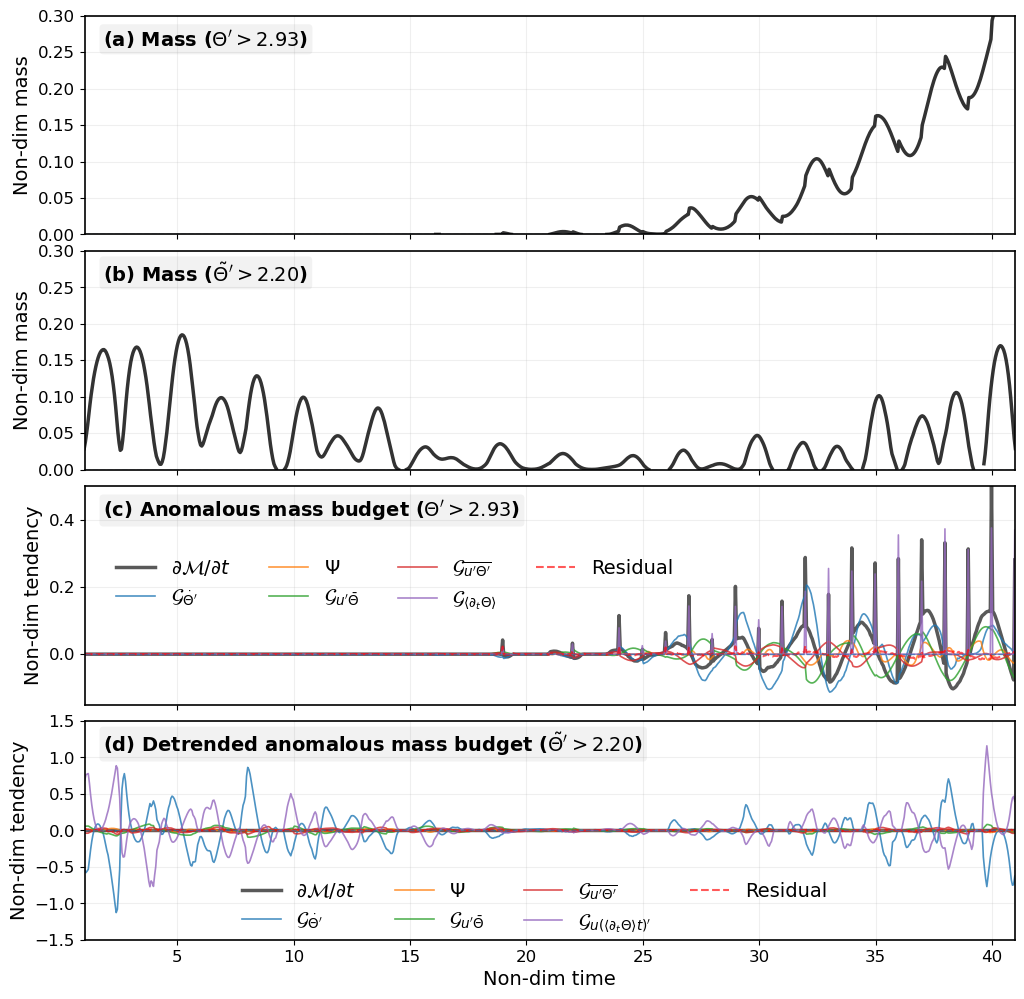

In [7]:
# ------------------------------
# 4行1列
# ------------------------------
fig, axes = plt.subplots(
    4, 1,
    figsize=(12, 12),
    sharex=True,
    gridspec_kw={'hspace': 0.075}
)

target_temp = 95

# ==============================
# (a) Full Mass
# ==============================
theta_value = ds_prime.tcenter.isel(tcenter=target_temp).values

axes[0].plot(
    ds_prime.time_snap,
    ds_prime.M.where(ds_prime.M>0).isel(tcenter=target_temp),
    color="k", lw=2.5, alpha=0.8
)
axes[0].axhline(0, ls='--', lw=1, alpha=0.6)
axes[0].text(0.02, 0.86, "(a) Mass ("+r"$\Theta^\prime > 2.93$"+")",fontsize=14,
             transform=axes[0].transAxes, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.1))
axes[0].grid(True, alpha=0.2)
axes[0].set_ylabel("Non-dim mass")
axes[0].set_ylim(0,0.3)

# ==============================
# (b) Detrended Mass
# ==============================
theta_value = ds_wave.tcenter.isel(tcenter=target_temp).values

axes[1].plot(
    ds_wave.time_snap,
    ds_wave.M.where(ds_wave.M>0).isel(tcenter=target_temp),
    color="k", lw=2.5, alpha=0.8
)
axes[1].axhline(0, ls='--', lw=1, alpha=0.6)
axes[1].text(0.02, 0.86, "(b) Mass ("+r"${\tilde{\Theta}}^{\prime} > 2.20$"+")",fontsize=14,
             transform=axes[1].transAxes, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.1))
axes[1].grid(True, alpha=0.2)
axes[1].set_ylabel("Non-dim mass")
axes[1].set_ylim(0,0.3)

# ==============================
# (c) Full Budget
# ==============================
ax = axes[2]

ax.plot(ds_prime.t,
        ds_prime.g_tend.isel(tcenter=target_temp),
        color="k", lw=2.5, alpha=0.65,
        label=full_label_dict["g_tend"])

for var in ["g_mix_total","g_adv","g_UpTb_total","g_UpTp_total","g_trend"]:
    ax.plot(ds_prime.t,
            ds_prime[var].isel(tcenter=target_temp),
            lw=1.2, alpha=0.8, 
            label=full_label_dict[var])

ax.plot(ds_prime.t,
        ds_prime.Residual.isel(tcenter=target_temp),
        color="red", ls="--", lw=1.5, alpha=0.65,
        label="Residual")

ax.axhline(0, ls='--', lw=1, alpha=0.6)
ax.set_ylim(-0.1, 2)
ax.text(0.02, 0.86, "(c) Anomalous mass budget ("+ r"${\Theta}^{\prime} > 2.93$"+")",fontsize=14,
        transform=ax.transAxes, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.1))
ax.legend(frameon=False, ncol=4,bbox_to_anchor=(0.015, 0.75), loc='upper left')
ax.grid(True, alpha=0.2)
ax.set_ylim(-0.15, 0.5)
ax.set_ylabel("Non-dim tendency")

# ==============================
# (d) Detrended Budget
# ==============================
ax = axes[3]

ax.plot(ds_wave.t,
        ds_wave.g_tend.isel(tcenter=target_temp)/1e11,
        color="k", lw=2.5, alpha=0.65,
        label=detrend_label_dict["g_tend"])

for var in ["g_mix_total","g_adv","g_UpTb_total","g_UpTp_total","g_uatp"]:
    ax.plot(ds_wave.t,
            ds_wave[var].isel(tcenter=target_temp),
            lw=1.2, alpha=0.8,
            label=detrend_label_dict[var])

ax.plot(ds_wave.t,
        ds_wave.Residual.isel(tcenter=target_temp),
        color="red", ls="--", lw=1.5, alpha=0.65,
        label="Residual")

ax.axhline(0, ls='--', lw=1, alpha=0.6)
ax.set_ylim(-1.5, 1.5)
ax.text(0.02, 0.86, "(d) Detrended anomalous mass budget ("+ r"${\tilde{\Theta}}^{\prime} > 2.20$"+")",fontsize=14,
        transform=ax.transAxes, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.1))
ax.legend(frameon=False, ncol=4,bbox_to_anchor=(0.15, 0.35), loc='upper left')
ax.grid(True, alpha=0.2)
ax.set_ylabel("Non-dim tendency")

# ==============================
# X轴格式
# ==============================
for ax in axes[:-1]:
    ax.tick_params(labelbottom=False)

axes[3].set_xlabel("Time")
axes[3].set_xlim(ds_wave.t[0],ds_wave.t[-1])
axes[3].set_xlabel('Non-dim time')

#for ax in axes:
#    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
#    ax.xaxis.set_major_locator(mdates.AutoDateLocator())

# ==============================
# 科学计数法
# ==============================
#for ax in axes:
#    formatter = mticker.ScalarFormatter(useMathText=True)
#    formatter.set_powerlimits((0,0))
#    ax.yaxis.set_major_formatter(formatter)

#fig.savefig("fig_timeseries_AWMB4x1_dx0035dt01.png",dpi=1000,bbox_inches="tight")
#fig.savefig("fig_timeseries_AWMB4x1_dx0035dt01.pdf",dpi=1000,bbox_inches="tight",transparent=True)


plt.show()

In [ ]:
#### figure 2 for JPO

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


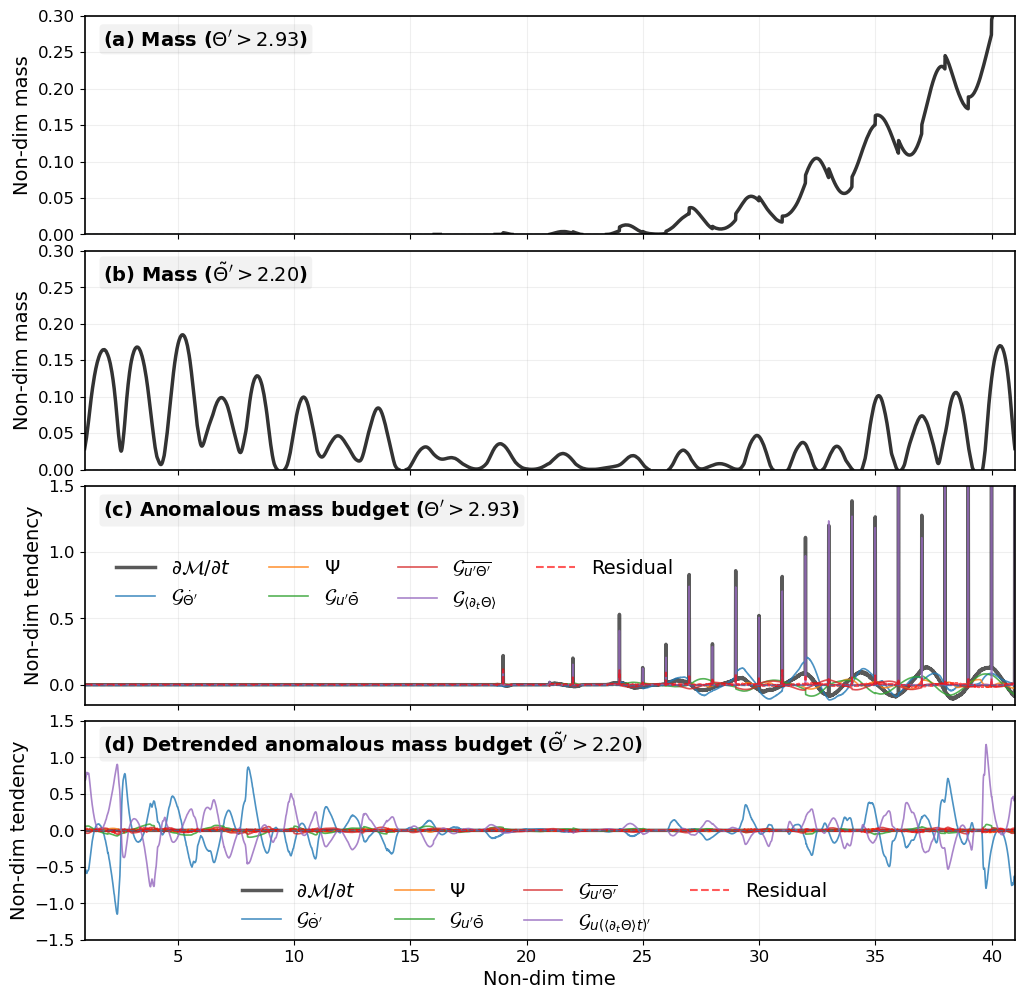

In [5]:
# ------------------------------
# 4行1列
# ------------------------------
fig, axes = plt.subplots(
    4, 1,
    figsize=(12, 12),
    sharex=True,
    gridspec_kw={'hspace': 0.075}
)

target_temp = 95

# ==============================
# (a) Full Mass
# ==============================
theta_value = ds_prime.tcenter.isel(tcenter=target_temp).values

axes[0].plot(
    ds_prime.time_snap,
    ds_prime.M.where(ds_prime.M>0).isel(tcenter=target_temp),
    color="k", lw=2.5, alpha=0.8
)
axes[0].axhline(0, ls='--', lw=1, alpha=0.6)
axes[0].text(0.02, 0.86, "(a) Mass ("+r"$\Theta^\prime > 2.93$"+")",fontsize=14,
             transform=axes[0].transAxes, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.1))
axes[0].grid(True, alpha=0.2)
axes[0].set_ylabel("Non-dim mass")
axes[0].set_ylim(0,0.3)

# ==============================
# (b) Detrended Mass
# ==============================
theta_value = ds_wave.tcenter.isel(tcenter=target_temp).values

axes[1].plot(
    ds_wave.time_snap,
    ds_wave.M.where(ds_wave.M>0).isel(tcenter=target_temp),
    color="k", lw=2.5, alpha=0.8
)
axes[1].axhline(0, ls='--', lw=1, alpha=0.6)
axes[1].text(0.02, 0.86, "(b) Mass ("+r"${\tilde{\Theta}}^{\prime} > 2.20$"+")",fontsize=14,
             transform=axes[1].transAxes, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.1))
axes[1].grid(True, alpha=0.2)
axes[1].set_ylabel("Non-dim mass")
axes[1].set_ylim(0,0.3)

# ==============================
# (c) Full Budget
# ==============================
ax = axes[2]

ax.plot(ds_prime.t,
        ds_prime.g_tend.isel(tcenter=target_temp),
        color="k", lw=2.5, alpha=0.65,
        label=full_label_dict["g_tend"])

for var in ["g_mix_total","g_adv","g_UpTb_total","g_UpTp_total","g_trend"]:
    ax.plot(ds_prime.t,
            ds_prime[var].isel(tcenter=target_temp),
            lw=1.2, alpha=0.8, 
            label=full_label_dict[var])

ax.plot(ds_prime.t,
        ds_prime.Residual.isel(tcenter=target_temp),
        color="red", ls="--", lw=1.5, alpha=0.65,
        label="Residual")
mas
ax.axhline(0, ls='--', lw=1, alpha=0.6)
ax.set_ylim(-0.1, 2)
ax.text(0.02, 0.86, "(c) Anomalous mass budget ("+ r"${\Theta}^{\prime} > 2.93$"+")",fontsize=14,
        transform=ax.transAxes, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.1))
ax.legend(frameon=False, ncol=4,bbox_to_anchor=(0.015, 0.75), loc='upper left')
ax.grid(True, alpha=0.2)
ax.set_ylim(-0.15, 1.5)
ax.set_ylabel("Non-dim tendency")

# ==============================
# (d) Detrended Budget
# ==============================
ax = axes[3]

ax.plot(ds_wave.t,
        ds_wave.g_tend.isel(tcenter=target_temp)/1e11,
        color="k", lw=2.5, alpha=0.65,
        label=detrend_label_dict["g_tend"])

for var in ["g_mix_total","g_adv","g_UpTb_total","g_UpTp_total","g_uatp"]:
    ax.plot(ds_wave.t,
            ds_wave[var].isel(tcenter=target_temp),
            lw=1.2, alpha=0.8,
            label=detrend_label_dict[var])

ax.plot(ds_wave.t,
        ds_wave.Residual.isel(tcenter=target_temp),
        color="red", ls="--", lw=1.5, alpha=0.65,
        label="Residual")

ax.axhline(0, ls='--', lw=1, alpha=0.6)
ax.set_ylim(-1.5, 1.5)
ax.text(0.02, 0.86, "(d) Detrended anomalous mass budget ("+ r"${\tilde{\Theta}}^{\prime} > 2.20$"+")",fontsize=14,
        transform=ax.transAxes, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.1))
ax.legend(frameon=False, ncol=4,bbox_to_anchor=(0.15, 0.35), loc='upper left')
ax.grid(True, alpha=0.2)
ax.set_ylabel("Non-dim tendency")

# ==============================
# X轴格式
# ==============================
for ax in axes[:-1]:
    ax.tick_params(labelbottom=False)

axes[3].set_xlabel("Time")
axes[3].set_xlim(ds_wave.t[0],ds_wave.t[-1])
axes[3].set_xlabel('Non-dim time')

#for ax in axes:
#    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
#    ax.xaxis.set_major_locator(mdates.AutoDateLocator())

# ==============================
# 科学计数法
# ==============================
#for ax in axes:
#    formatter = mticker.ScalarFormatter(useMathText=True)
#    formatter.set_powerlimits((0,0))
#    ax.yaxis.set_major_formatter(formatter)

fig.savefig("fig_timeseries_AWMB4x1_dx0035dt01.png",dpi=1000,bbox_inches="tight")
fig.savefig("fig_timeseries_AWMB4x1_dx0035dt01.pdf",dpi=1000,bbox_inches="tight",transparent=True)


plt.show()

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


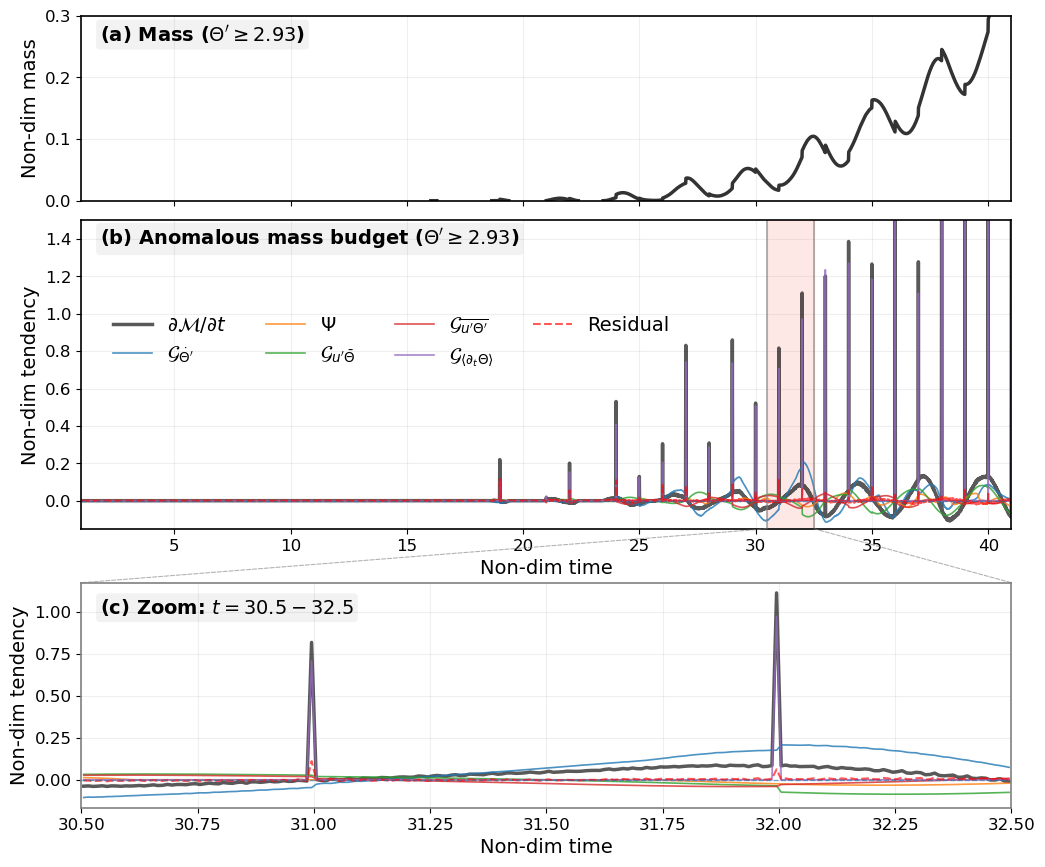

In [5]:
# ------------------------------
# Θ′ 版本：3 行
#   (a) Mass
#   (b) Anomalous mass budget（全时段）
#   (c) zoom：t = 30–35 的收支
# ------------------------------
from matplotlib.patches import ConnectionPatch

target_temp = 95

ZOOM       = (30.5, 32.5)     # 第三行放大的时间段
SPAN_COLOR = "salmon"
SPAN_ALPHA = 0.18
BOX_COLOR  = "grey"
BOX_LW     = 1.2

PRIME_VARS = ["g_mix_total", "g_adv", "g_UpTb_total", "g_UpTp_total", "g_trend"]

fig = plt.figure(figsize=(12, 9))

# (a)(b) 紧挨着放在上面一块，(c) 单独放在下面一块，
# 中间留出 0.10 的空隙给 (b) 的 xlabel，避免它压到 (c) 上
gs_top = fig.add_gridspec(2, 1, height_ratios=[1.5, 2.5],
                          top=0.95, bottom=0.38, hspace=0.08)
gs_bot = fig.add_gridspec(1, 1, top=0.32, bottom=0.07)

ax_a = fig.add_subplot(gs_top[0])
ax_b = fig.add_subplot(gs_top[1], sharex=ax_a)
ax_c = fig.add_subplot(gs_bot[0])


# ──────────────────────────────────────────────────────────────
# 通用函数：把收支各项画到指定 ax 上（(b) 和 (c) 共用）
# ──────────────────────────────────────────────────────────────
def plot_budget(ax, ds, var_list, label_dict, with_label=True):
    ax.plot(ds.t,
            ds.g_tend.isel(tcenter=target_temp),
            color="k", lw=2.5, alpha=0.65,
            label=label_dict["g_tend"] if with_label else None)

    for var in var_list:
        ax.plot(ds.t,
                ds[var].isel(tcenter=target_temp),
                lw=1.2, alpha=0.8,
                label=label_dict[var] if with_label else None)

    ax.plot(ds.t,
            ds.Residual.isel(tcenter=target_temp),
            color="red", ls="--", lw=1.5, alpha=0.65,
            label="Residual" if with_label else None)

    ax.axhline(0, ls='--', lw=1, alpha=0.6)
    ax.grid(True, alpha=0.2)


# ==============================
# (a) Mass
# ==============================
theta_value = ds_prime.tcenter.isel(tcenter=target_temp).values

ax_a.plot(
    ds_prime.time_snap,
    ds_prime.M.where(ds_prime.M > 0).isel(tcenter=target_temp),
    color="k", lw=2.5, alpha=0.8
)
ax_a.axhline(0, ls='--', lw=1, alpha=0.6)
ax_a.text(0.02, 0.86, "(a) Mass (" + r"$\Theta^\prime \geq 2.93$" + ")", fontsize=14,
          transform=ax_a.transAxes, fontweight='bold',
          bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.1))
ax_a.grid(True, alpha=0.2)
ax_a.set_ylabel("Non-dim mass")
ax_a.set_ylim(0, 0.3)

# ==============================
# (b) Anomalous mass budget（全时段）
# ==============================
plot_budget(ax_b, ds_prime, PRIME_VARS, full_label_dict, with_label=True)

# 标出 zoom 时段
ax_b.axvspan(*ZOOM, color=SPAN_COLOR, alpha=SPAN_ALPHA)
for x in ZOOM:
    ax_b.axvline(x, color=BOX_COLOR, lw=BOX_LW, alpha=0.7)

ax_b.text(0.02, 0.92, "(b) Anomalous mass budget (" + r"${\Theta}^{\prime} \geq 2.93$" + ")", fontsize=14,
          transform=ax_b.transAxes, fontweight='bold',
          bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.1))
ax_b.legend(frameon=False, ncol=4, bbox_to_anchor=(0.015, 0.75), loc='upper left')
ax_b.set_ylim(-0.15, 1.5)
ax_b.set_ylabel("Non-dim tendency")

# ==============================
# (c) zoom：t = 30–35
# ==============================
ds_zoom = ds_prime.sel(t=slice(*ZOOM))

plot_budget(ax_c, ds_zoom, PRIME_VARS, full_label_dict, with_label=False)

ax_c.set_xlim(*ZOOM)
# ax_c.set_ylim(-0.15, 0.5)      # 想和 (b) 用同一纵轴范围就打开这行，默认自动缩放
for spine in ax_c.spines.values():
    spine.set_edgecolor(BOX_COLOR)
    spine.set_linewidth(BOX_LW)
ax_c.text(0.02, 0.86, "(c) Zoom: " + r"$t = 30.5-32.5$", fontsize=14,
          transform=ax_c.transAxes, fontweight='bold',
          bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.1))
ax_c.set_ylabel("Non-dim tendency")

# ==============================
# (b) → (c) 的连线
# ==============================
for x in ZOOM:
    con = ConnectionPatch(
        xyA=(x, ax_b.get_ylim()[0]), coordsA=ax_b.transData,
        xyB=(x, ax_c.get_ylim()[1]), coordsB=ax_c.transData,
        axesA=ax_b, axesB=ax_c,
        color=BOX_COLOR, linewidth=0.8, linestyle="--", alpha=0.6,
        arrowstyle="-",
    )
    fig.add_artist(con)

# ==============================
# X轴
# ==============================
ax_a.tick_params(labelbottom=False)
ax_b.set_xlim(ds_prime.t[0], ds_prime.t[-1])
ax_b.set_xlabel('Non-dim time')
ax_c.set_xlabel('Non-dim time')

fig.savefig("fig_timeseries_AWMB3x1_totalprime_zoom_dx0035dt01.png", dpi=1000, bbox_inches="tight")
fig.savefig("fig_timeseries_AWMB3x1_totalprime_zoom_dx0035dt01.pdf", dpi=1000, bbox_inches="tight")

plt.show()


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


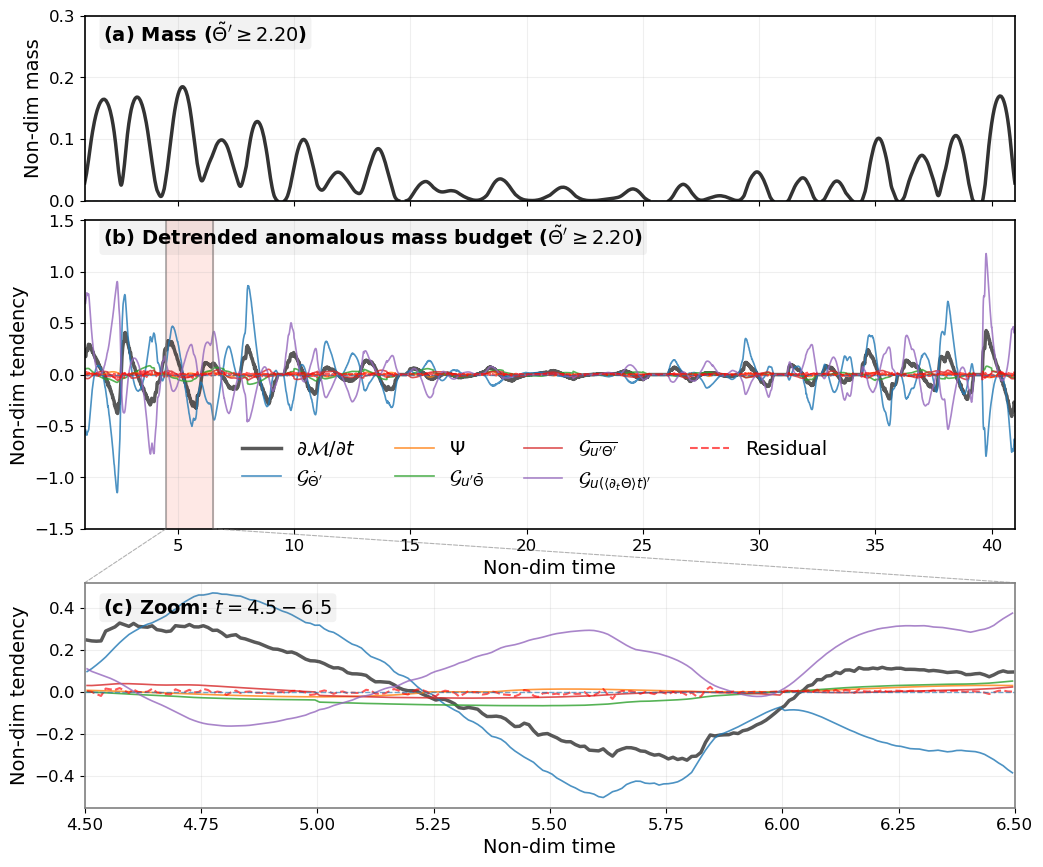

In [6]:
# ------------------------------
# Θ̃′ 版本：3 行
#   (a) Mass
#   (b) Detrended anomalous mass budget（全时段）
#   (c) zoom：t = 30–35 的收支
# ------------------------------
from matplotlib.patches import ConnectionPatch

target_temp = 95

ZOOM       = (4.5, 6.5)     # 第三行放大的时间段
SPAN_COLOR = "salmon"
SPAN_ALPHA = 0.18
BOX_COLOR  = "grey"
BOX_LW     = 1.2

WAVE_VARS = ["g_mix_total", "g_adv", "g_UpTb_total", "g_UpTp_total", "g_uatp"]

fig = plt.figure(figsize=(12, 9))

# (a)(b) 紧挨着放在上面一块，(c) 单独放在下面一块，
# 中间留出 0.10 的空隙给 (b) 的 xlabel，避免它压到 (c) 上
gs_top = fig.add_gridspec(2, 1, height_ratios=[1.5, 2.5],
                          top=0.95, bottom=0.38, hspace=0.08)
gs_bot = fig.add_gridspec(1, 1, top=0.32, bottom=0.07)

ax_a = fig.add_subplot(gs_top[0])
ax_b = fig.add_subplot(gs_top[1], sharex=ax_a)
ax_c = fig.add_subplot(gs_bot[0])


# ──────────────────────────────────────────────────────────────
# 通用函数：把收支各项画到指定 ax 上（(b) 和 (c) 共用）
# ──────────────────────────────────────────────────────────────
def plot_budget(ax, ds, var_list, label_dict, with_label=True):
    ax.plot(ds.t,
            ds.g_tend.isel(tcenter=target_temp),
            color="k", lw=2.5, alpha=0.65,
            label=label_dict["g_tend"] if with_label else None)

    for var in var_list:
        ax.plot(ds.t,
                ds[var].isel(tcenter=target_temp),
                lw=1.2, alpha=0.8,
                label=label_dict[var] if with_label else None)

    ax.plot(ds.t,
            ds.Residual.isel(tcenter=target_temp),
            color="red", ls="--", lw=1.5, alpha=0.65,
            label="Residual" if with_label else None)

    ax.axhline(0, ls='--', lw=1, alpha=0.6)
    ax.grid(True, alpha=0.2)


# ==============================
# (a) Mass
# ==============================
theta_value = ds_wave.tcenter.isel(tcenter=target_temp).values

ax_a.plot(
    ds_wave.time_snap,
    ds_wave.M.where(ds_wave.M > 0).isel(tcenter=target_temp),
    color="k", lw=2.5, alpha=0.8
)
ax_a.axhline(0, ls='--', lw=1, alpha=0.6)
ax_a.text(0.02, 0.86, "(a) Mass (" + r"${\tilde{\Theta}}^{\prime} \geq 2.20$" + ")", fontsize=14,
          transform=ax_a.transAxes, fontweight='bold',
          bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.1))
ax_a.grid(True, alpha=0.2)
ax_a.set_ylabel("Non-dim mass")
ax_a.set_ylim(0, 0.3)

# ==============================
# (b) Detrended anomalous mass budget（全时段）
# 注意：原 4×1 里 g_tend 那行多了个 /1e11（ECCO 版的残留），这里是无量纲量，已去掉
# ==============================
plot_budget(ax_b, ds_wave, WAVE_VARS, detrend_label_dict, with_label=True)

# 标出 zoom 时段
ax_b.axvspan(*ZOOM, color=SPAN_COLOR, alpha=SPAN_ALPHA)
for x in ZOOM:
    ax_b.axvline(x, color=BOX_COLOR, lw=BOX_LW, alpha=0.7)

ax_b.text(0.02, 0.92, "(b) Detrended anomalous mass budget (" + r"${\tilde{\Theta}}^{\prime} \geq 2.20$" + ")", fontsize=14,
          transform=ax_b.transAxes, fontweight='bold',
          bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.1))
ax_b.legend(frameon=False, ncol=4, bbox_to_anchor=(0.15, 0.35), loc='upper left')
ax_b.set_ylim(-1.5, 1.5)
ax_b.set_ylabel("Non-dim tendency")

# ==============================
# (c) zoom：t = 30–35
# ==============================
ds_zoom = ds_wave.sel(t=slice(*ZOOM))

plot_budget(ax_c, ds_zoom, WAVE_VARS, detrend_label_dict, with_label=False)

ax_c.set_xlim(*ZOOM)
# ax_c.set_ylim(-1.5, 1.5)       # 想和 (b) 用同一纵轴范围就打开这行，默认自动缩放
for spine in ax_c.spines.values():
    spine.set_edgecolor(BOX_COLOR)
    spine.set_linewidth(BOX_LW)
ax_c.text(0.02, 0.86, "(c) Zoom: " + r"$t = 4.5-6.5$", fontsize=14,
          transform=ax_c.transAxes, fontweight='bold',
          bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.1))
ax_c.set_ylabel("Non-dim tendency")

# ==============================
# (b) → (c) 的连线
# ==============================
for x in ZOOM:
    con = ConnectionPatch(
        xyA=(x, ax_b.get_ylim()[0]), coordsA=ax_b.transData,
        xyB=(x, ax_c.get_ylim()[1]), coordsB=ax_c.transData,
        axesA=ax_b, axesB=ax_c,
        color=BOX_COLOR, linewidth=0.8, linestyle="--", alpha=0.6,
        arrowstyle="-",
    )
    fig.add_artist(con)

# ==============================
# X轴
# ==============================
ax_a.tick_params(labelbottom=False)
ax_b.set_xlim(ds_wave.t[0], ds_wave.t[-1])
ax_b.set_xlabel('Non-dim time')
ax_c.set_xlabel('Non-dim time')

fig.savefig("fig_timeseries_AWMB3x1_waveprime_zoom_dx0035dt01.png", dpi=1000, bbox_inches="tight")
fig.savefig("fig_timeseries_AWMB3x1_waveprime_zoom_dx0035dt01.pdf", dpi=1000, bbox_inches="tight")

plt.show()


In [7]:
import numpy as np

target_temp = 95

def rms_closure_error(ds, rhs_vars, target_temp, scale_tend=1.0):
    tend = ds["g_tend"].isel(tcenter=target_temp) / scale_tend
    res  = ds["Residual"].isel(tcenter=target_temp)

    rhs = sum(ds[v].isel(tcenter=target_temp) for v in rhs_vars)

    err_vs_tend = float(
        np.sqrt((res**2).mean()) / np.sqrt((tend**2).mean()) * 100
    )

    err_vs_rhs = float(
        np.sqrt((res**2).mean()) / np.sqrt((rhs**2).mean()) * 100
    )

    threshold = float(ds["tcenter"].isel(tcenter=target_temp))

    return threshold, err_vs_tend, err_vs_rhs


# Full anomaly budget
full_rhs_vars = [
    "g_mix_total",
    "g_adv",
    "g_UpTb_total",
    "g_UpTp_total",
    "g_trend",
]

theta_thr, full_err_tend, full_err_rhs = rms_closure_error(
    ds_prime, full_rhs_vars, target_temp
)


# Detrended anomaly budget
detrend_rhs_vars = [
    "g_mix_total",
    "g_adv",
    "g_UpTb_total",
    "g_UpTp_total",
    "g_uatp",
]

tilde_thr, det_err_tend, det_err_rhs = rms_closure_error(
    ds_wave, detrend_rhs_vars, target_temp
)


print(f"Full anomaly threshold: Θ' > {theta_thr:.2f}")
print(f"  RMS residual / RMS tendency = {full_err_tend:.3f}%")
print(f"  RMS residual / RMS RHS      = {full_err_rhs:.3f}%")

print(f"Detrended anomaly threshold: Θ~' > {tilde_thr:.2f}")
print(f"  RMS residual / RMS tendency = {det_err_tend:.3f}%")
print(f"  RMS residual / RMS RHS      = {det_err_rhs:.3f}%")

Full anomaly threshold: Θ' > 2.93
  RMS residual / RMS tendency = 6.769%
  RMS residual / RMS RHS      = 6.925%
Detrended anomaly threshold: Θ~' > 2.20
  RMS residual / RMS tendency = 6.300%
  RMS residual / RMS RHS      = 6.360%


In [ ]:
#### figure 3 for JPO

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


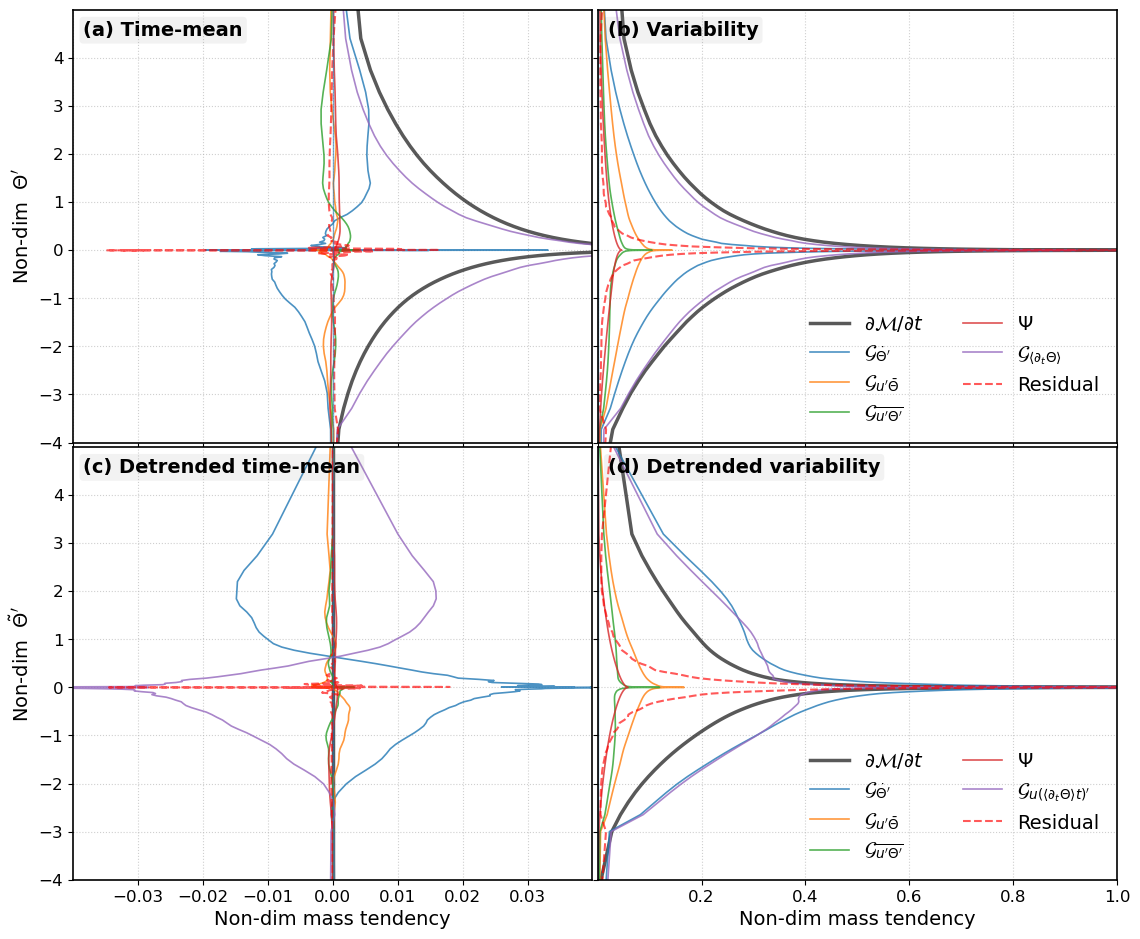

In [6]:

full_rhs_base_vars=["g_mix_total","g_UpTb_total","g_UpTp_total","g_adv","g_trend"]
detrend_rhs_base_vars=["g_mix_total","g_UpTb_total","g_UpTp_total","g_adv","g_uatp"]



fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharey=True)

# 数据对应顺序
data_list = [
    (ds_prime.mean(dim="t"), axes[0,0], full_rhs_base_vars, full_label_dict, "(a) Time-mean"),
    (ds_prime.std(dim="t"), axes[0,1], full_rhs_base_vars, full_label_dict, "(b) Variability"),
    (ds_wave.mean(dim="t"), axes[1,0], detrend_rhs_base_vars, detrend_label_dict, "(c) Detrended time-mean"),
    (ds_wave.std(dim="t"), axes[1,1], detrend_rhs_base_vars, detrend_label_dict, "(d) Detrended variability")
]

main_terms = ["g_tend", "Residual"]

for data, ax, rhs_vars, label_dict, label_text in data_list:
    # g_tend (黑色粗线)
    ax.plot(data["g_tend"],
            data["tcenter"],
            linewidth=2.5,
            color="k",
            alpha=0.65,
            label=label_dict["g_tend"])
    
    # 其他项（细线 + alpha=0.8）
    other_terms = [v for v in rhs_vars if v not in main_terms]
    for var in other_terms:
        ax.plot(data[var],
                data["tcenter"],
                linewidth=1.2,
                alpha=0.8,
                label=label_dict.get(var, var))
    
    # residual（红色虚线）
    ax.plot(data["Residual"],
            data["tcenter"],
            linewidth=1.5,
            linestyle="--",
            color="red",
            alpha=0.65,
            label=label_dict["Residual"])
    
    # 美化
    ax.axvline(0, linewidth=1, alpha=0.6)
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.set_ylim(-5., 5.5)
    
    # 左上角添加 (a)/(b)/(c)/(d) 标注
    ax.text(0.02, 0.94, label_text, transform=ax.transAxes,
            fontsize=14, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.1))

# x/y label
axes[0,0].set_xlim(-0.04, 0.04)
axes[1,0].set_xlim(-0.04, 0.04)
axes[0,1].set_xlim(-0.0, 1.)
axes[1,1].set_xlim(-0.0, 1.)
axes[0,0].set_ylim(-4, 5)
axes[0,1].set_ylim(-4, 5)
axes[1,0].set_ylim(-4, 5)
axes[1,1].set_ylim(-4, 5)

axes[1,0].set_xlabel("Non-dim mass tendency")
axes[1,1].set_xlabel("Non-dim mass tendency")
axes[0,0].set_ylabel("Non-dim  "+r"$\Theta'$")
axes[1,0].set_ylabel("Non-dim  "+r"$\tilde{\Theta}'$")
#labels = ['' if t == 0.0 else f'{t:g}' for t in ticks]
axes[1,1].set_xticks([0.2,0.4,0.6,0.8,1])
axes[1,0].set_xticks([-0.03,-0.02,-0.01,0,0.01,0.02,0.03])
axes[1,0].set_yticks(np.arange(-4,5,1))

#axes[1,1].set_xticklabels(labels)

# legend 统一
handles, labels = axes[0,0].get_legend_handles_labels()
axes[0,1].legend(handles, labels, loc='lower right', ncol=2, frameon=False)

handles, labels = axes[1,0].get_legend_handles_labels()
axes[1,1].legend(handles, labels, loc='lower right', ncol=2, frameon=False)

# 第一行子图不显示横轴ticklabel
for ax in axes[0,:]:
    ax.set_xticklabels([])


#fig.tight_layout(rect=[0, 0, 0.95, 1])
fig.subplots_adjust(left=0.08, right=0.95, top=0.95, bottom=0.08,
                    wspace=0.01, hspace=0.01)

# 保存
fig.savefig("fig_meanstd_AWMB_dx0035dt01.png", dpi=1000, bbox_inches="tight")
fig.savefig("fig_meanstd_AWMB_dx0035dt01.pdf", dpi=1000, bbox_inches="tight", transparent=True)

plt.show()


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


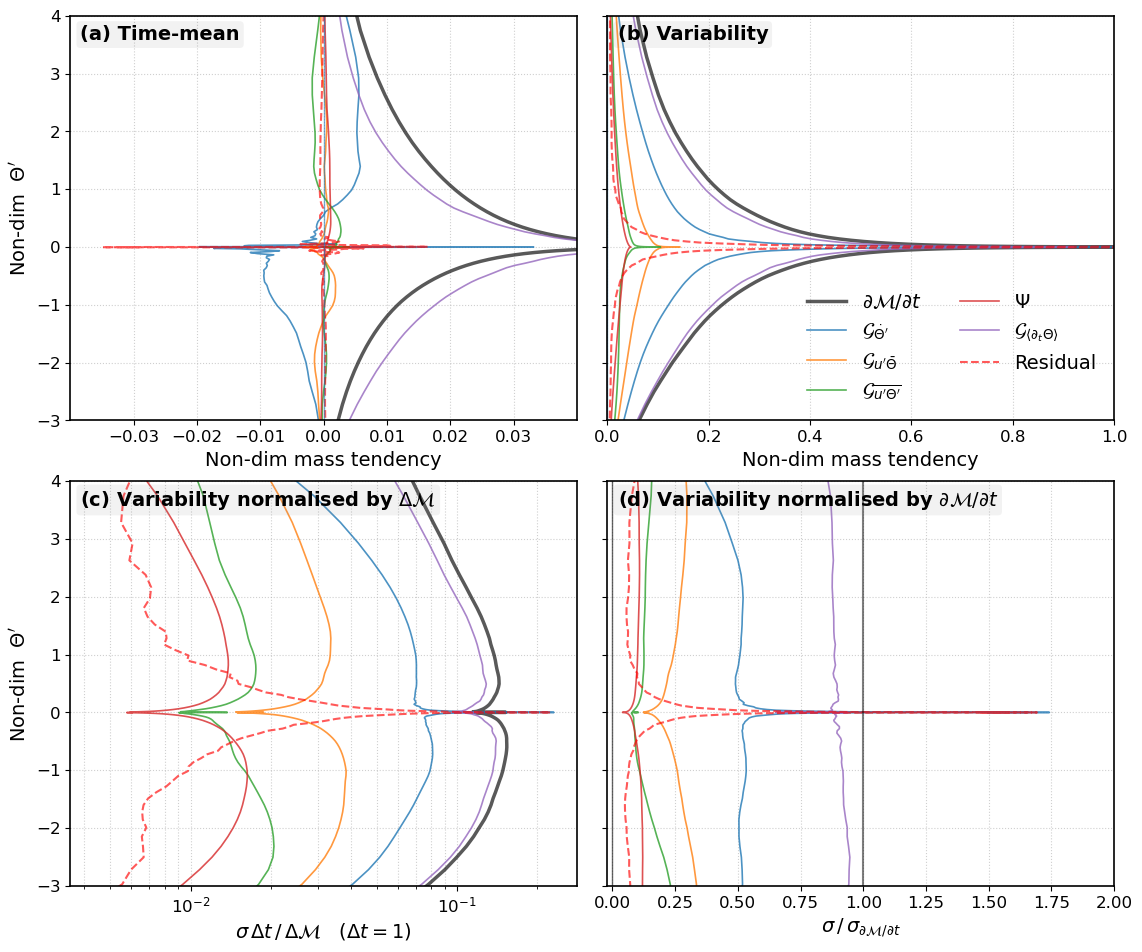

In [14]:
# ------------------------------
# Θ′ 版本 2×2：
#   (a) Time-mean                        (b) Variability
#   (c) Variability normalised by ΔM     (d) Variability normalised by ∂M/∂t
# ------------------------------
full_rhs_base_vars = ["g_mix_total","g_UpTb_total","g_UpTp_total","g_adv","g_trend"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharey=True)

mean_ds = ds_prime.mean(dim="t")
std_ds  = ds_prime.std(dim="t")

data_list = [
    (mean_ds, axes[0,0], full_rhs_base_vars, full_label_dict, "(a) Time-mean"),
    (std_ds,  axes[0,1], full_rhs_base_vars, full_label_dict, "(b) Variability"),
]

main_terms = ["g_tend", "Residual"]

for data, ax, rhs_vars, label_dict, label_text in data_list:
    # g_tend (黑色粗线)
    ax.plot(data["g_tend"],
            data["tcenter"],
            linewidth=2.5,
            color="k",
            alpha=0.65,
            label=label_dict["g_tend"])

    # 其他项（细线 + alpha=0.8）
    other_terms = [v for v in rhs_vars if v not in main_terms]
    for var in other_terms:
        ax.plot(data[var],
                data["tcenter"],
                linewidth=1.2,
                alpha=0.8,
                label=label_dict.get(var, var))

    # residual（红色虚线）
    ax.plot(data["Residual"],
            data["tcenter"],
            linewidth=1.5,
            linestyle="--",
            color="red",
            alpha=0.65,
            label=label_dict["Residual"])

    # 美化
    ax.axvline(0, linewidth=1, alpha=0.6)
    ax.grid(True, linestyle=":", alpha=0.6)

    # 左上角标注
    ax.text(0.02, 0.94, label_text, transform=ax.transAxes,
            fontsize=14, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.1))

# -----------------------------
# (c) 把 (b) 的所有项都对 layer mass 归一化（无量纲）
#     M 是累积量 M(Θ′ > tcenter)，先用中心差分 [M(i-1) - M(i+1)]/2 转成每层质量 ΔM。
#     这里 t 本身就是无量纲时间，取参考时间尺度 Δt = 1 即可无量纲化。
# -----------------------------
ax = axes[1,0]

DT_REF = 0.01   # Δt = 1（无量纲时间单位）

mass_cum   = ds_prime.M.mean(dim="time_snap")
mass_layer = (mass_cum.shift(tcenter=1) - mass_cum.shift(tcenter=-1)) / 2   # 中心差分
mass_layer = mass_layer.where(mass_layer > 0)                               # 避免除以 0 / 负值

per_mass = std_ds / mass_layer * DT_REF                                     # 无量纲

# 线型/颜色/粗细与 (b) 完全一致，顺序相同 → 配色自动对应
ax.plot(per_mass["g_tend"], per_mass["tcenter"],
        linewidth=2.5, color="k", alpha=0.65,
        label=full_label_dict["g_tend"])

for var in [v for v in full_rhs_base_vars if v not in main_terms]:
    ax.plot(per_mass[var], per_mass["tcenter"],
            linewidth=1.2, alpha=0.8,
            label=full_label_dict.get(var, var))

ax.plot(per_mass["Residual"], per_mass["tcenter"],
        linewidth=1.5, linestyle="--", color="red", alpha=0.65,
        label=full_label_dict["Residual"])

ax.set_xscale("log")
ax.grid(True, linestyle=":", alpha=0.6, which="both")
ax.text(0.02, 0.94, r"(c) Variability normalised by $\Delta \mathcal{M}$",
        transform=ax.transAxes,
        fontsize=14, fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.1))

# -----------------------------
# (d) 把 (b) 的各项除以 ∂M/∂t 这一项做归一化（无量纲）
# -----------------------------
ax = axes[1,1]

denom = std_ds["g_tend"].where(std_ds["g_tend"] > 0)   # 避免除以 0
ratio = std_ds / denom                                  # 量纲/系数都被约掉

for var in [v for v in full_rhs_base_vars if v not in main_terms]:
    ax.plot(ratio[var], ratio["tcenter"],
            linewidth=1.2, alpha=0.8, label=full_label_dict.get(var, var))

ax.plot(ratio["Residual"], ratio["tcenter"],
        linewidth=1.5, linestyle="--", color="red", alpha=0.65,
        label=full_label_dict["Residual"])

ax.axvline(1, linewidth=1.5, color="k", alpha=0.5, linestyle="-")  # 自身 = 1
ax.axvline(0, linewidth=1, color="k", alpha=0.6)
ax.grid(True, linestyle=":", alpha=0.6)
ax.text(0.02, 0.94, r"(d) Variability normalised by $\partial \mathcal{M}/\partial t$",
        transform=ax.transAxes,
        fontsize=14, fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.1))

# -----------------------------
# x/y label 与坐标范围
# -----------------------------
axes[0,0].set_xlim(-0.04, 0.04)
axes[0,1].set_xlim(-0.0, 1.)
# 下面两行是 (c)(d) 的范围，先让它自动缩放；跑一遍看清量级后再固定
# axes[1,0].set_xlim(1e-4, 1e0)
# axes[1,1].set_xlim(0., 1.2)

for ax in axes.flat:
    ax.set_ylim(-3., 4)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(1))
axes[1,1].set_xlim(-0.02,2)

axes[0,0].set_xticks([-0.03,-0.02,-0.01,0,0.01,0.02,0.03])

axes[0,0].set_xlabel("Non-dim mass tendency")
axes[0,1].set_xlabel("Non-dim mass tendency")
axes[1,0].set_xlabel(r"$\sigma\,\Delta t\,/\,\Delta \mathcal{M}$   ($\Delta t = 1$)")
axes[1,1].set_xlabel(r"$\sigma\,/\,\sigma_{\partial \mathcal{M}/\partial t}$")
axes[0,0].set_ylabel("Non-dim  " + r"$\Theta'$")
axes[1,0].set_ylabel("Non-dim  " + r"$\Theta'$")

# legend 统一：(b) 那一个同时管 (c)(d)
handles, labels = axes[0,0].get_legend_handles_labels()
axes[0,1].legend(handles, labels, loc='lower right', ncol=2, frameon=False)

fig.subplots_adjust(left=0.08, right=0.95, top=0.95, bottom=0.08,
                    wspace=0.06, hspace=0.15)

# 保存
fig.savefig("fig_meanstd_AWMB_totalprime_norm_dx0035dt01.png", dpi=1000, bbox_inches="tight")
fig.savefig("fig_meanstd_AWMB_totalprime_norm_dx0035dt01.pdf", dpi=1000, bbox_inches="tight", transparent=True)

plt.show()


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


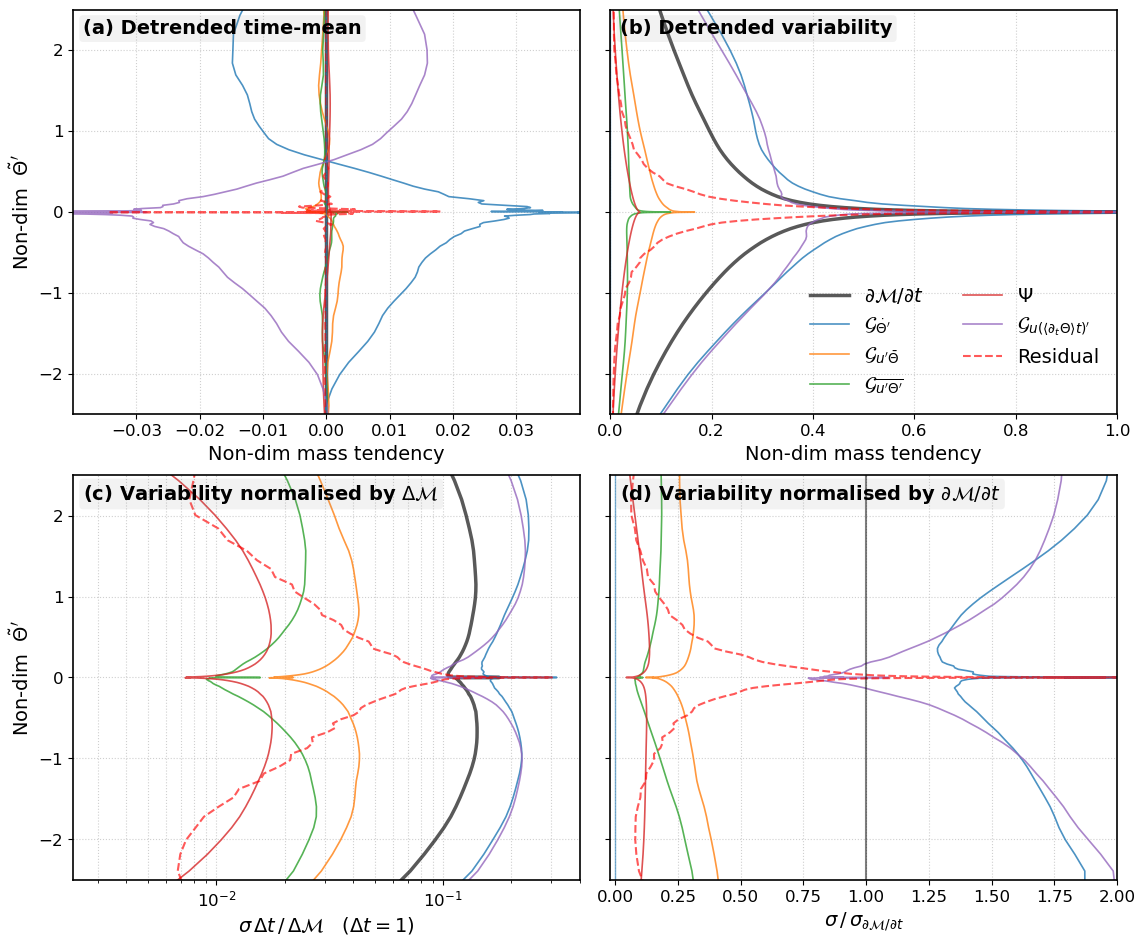

In [16]:
# ------------------------------
# Θ̃′ 版本 2×2：
#   (a) Time-mean                        (b) Variability
#   (c) Variability normalised by ΔM     (d) Variability normalised by ∂M/∂t
# ------------------------------
detrend_rhs_base_vars = ["g_mix_total","g_UpTb_total","g_UpTp_total","g_adv","g_uatp"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharey=True)

mean_ds = ds_wave.mean(dim="t")
std_ds  = ds_wave.std(dim="t")

data_list = [
    (mean_ds, axes[0,0], detrend_rhs_base_vars, detrend_label_dict, "(a) Detrended time-mean"),
    (std_ds,  axes[0,1], detrend_rhs_base_vars, detrend_label_dict, "(b) Detrended variability"),
]

main_terms = ["g_tend", "Residual"]

for data, ax, rhs_vars, label_dict, label_text in data_list:
    # g_tend (黑色粗线)
    ax.plot(data["g_tend"],
            data["tcenter"],
            linewidth=2.5,
            color="k",
            alpha=0.65,
            label=label_dict["g_tend"])

    # 其他项（细线 + alpha=0.8）
    other_terms = [v for v in rhs_vars if v not in main_terms]
    for var in other_terms:
        ax.plot(data[var],
                data["tcenter"],
                linewidth=1.2,
                alpha=0.8,
                label=label_dict.get(var, var))

    # residual（红色虚线）
    ax.plot(data["Residual"],
            data["tcenter"],
            linewidth=1.5,
            linestyle="--",
            color="red",
            alpha=0.65,
            label=label_dict["Residual"])

    # 美化
    ax.axvline(0, linewidth=1, alpha=0.6)
    ax.grid(True, linestyle=":", alpha=0.6)

    # 左上角标注
    ax.text(0.02, 0.94, label_text, transform=ax.transAxes,
            fontsize=14, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.1))

# -----------------------------
# (c) 把 (b) 的所有项都对 layer mass 归一化（无量纲）
#     M 是累积量 M(Θ̃′ > tcenter)，先用中心差分 [M(i-1) - M(i+1)]/2 转成每层质量 ΔM。
#     这里 t 本身就是无量纲时间，取参考时间尺度 Δt = 1 即可无量纲化。
# -----------------------------
ax = axes[1,0]

DT_REF = 0.01   # Δt = 1（无量纲时间单位）

mass_cum   = ds_wave.M.mean(dim="time_snap")
mass_layer = (mass_cum.shift(tcenter=1) - mass_cum.shift(tcenter=-1)) / 2   # 中心差分
mass_layer = mass_layer.where(mass_layer > 0)                               # 避免除以 0 / 负值

per_mass = std_ds / mass_layer * DT_REF                                     # 无量纲

# 线型/颜色/粗细与 (b) 完全一致，顺序相同 → 配色自动对应
ax.plot(per_mass["g_tend"], per_mass["tcenter"],
        linewidth=2.5, color="k", alpha=0.65,
        label=detrend_label_dict["g_tend"])

for var in [v for v in detrend_rhs_base_vars if v not in main_terms]:
    ax.plot(per_mass[var], per_mass["tcenter"],
            linewidth=1.2, alpha=0.8,
            label=detrend_label_dict.get(var, var))

ax.plot(per_mass["Residual"], per_mass["tcenter"],
        linewidth=1.5, linestyle="--", color="red", alpha=0.65,
        label=detrend_label_dict["Residual"])

ax.set_xscale("log")
ax.grid(True, linestyle=":", alpha=0.6, which="both")
ax.text(0.02, 0.94, r"(c) Variability normalised by $\Delta \mathcal{M}$",
        transform=ax.transAxes,
        fontsize=14, fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.1))

# -----------------------------
# (d) 把 (b) 的各项除以 ∂M/∂t 这一项做归一化（无量纲）
# -----------------------------
ax = axes[1,1]

denom = std_ds["g_tend"].where(std_ds["g_tend"] > 0)   # 避免除以 0
ratio = std_ds / denom                                  # 量纲/系数都被约掉

for var in [v for v in detrend_rhs_base_vars if v not in main_terms]:
    ax.plot(ratio[var], ratio["tcenter"],
            linewidth=1.2, alpha=0.8, label=detrend_label_dict.get(var, var))

ax.plot(ratio["Residual"], ratio["tcenter"],
        linewidth=1.5, linestyle="--", color="red", alpha=0.65,
        label=detrend_label_dict["Residual"])

ax.axvline(1, linewidth=1.5, color="k", alpha=0.5, linestyle="-")  # 自身 = 1
ax.axvline(0, linewidth=1, alpha=0.6)
ax.grid(True, linestyle=":", alpha=0.6)
ax.text(0.02, 0.94, r"(d) Variability normalised by $\partial \mathcal{M}/\partial t$",
        transform=ax.transAxes,
        fontsize=14, fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.1))

# -----------------------------
# x/y label 与坐标范围
# -----------------------------
axes[0,0].set_xlim(-0.04, 0.04)
axes[0,1].set_xlim(-0.0, 1.)
# 下面两行是 (c)(d) 的范围，先让它自动缩放；跑一遍看清量级后再固定
# axes[1,0].set_xlim(1e-4, 1e0)
# axes[1,1].set_xlim(0., 1.2)

for ax in axes.flat:
    ax.set_ylim(-2.5, 2.5)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(1))
axes[1,1].set_xlim(-0.02,2)

axes[0,0].set_xticks([-0.03,-0.02,-0.01,0,0.01,0.02,0.03])

axes[0,0].set_xlabel("Non-dim mass tendency")
axes[0,1].set_xlabel("Non-dim mass tendency")
axes[1,0].set_xlabel(r"$\sigma\,\Delta t\,/\,\Delta \mathcal{M}$   ($\Delta t = 1$)")
axes[1,1].set_xlabel(r"$\sigma\,/\,\sigma_{\partial \mathcal{M}/\partial t}$")
axes[0,0].set_ylabel("Non-dim  " + r"$\tilde{\Theta}'$")
axes[1,0].set_ylabel("Non-dim  " + r"$\tilde{\Theta}'$")

# legend 统一：(b) 那一个同时管 (c)(d)
handles, labels = axes[0,0].get_legend_handles_labels()
axes[0,1].legend(handles, labels, loc='lower right', ncol=2, frameon=False)

fig.subplots_adjust(left=0.08, right=0.95, top=0.95, bottom=0.08,
                    wspace=0.06, hspace=0.15)

# 保存
fig.savefig("fig_meanstd_AWMB_waveprime_norm_dx0035dt01.png", dpi=1000, bbox_inches="tight")
fig.savefig("fig_meanstd_AWMB_waveprime_norm_dx0035dt01.pdf", dpi=1000, bbox_inches="tight", transparent=True)

plt.show()


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


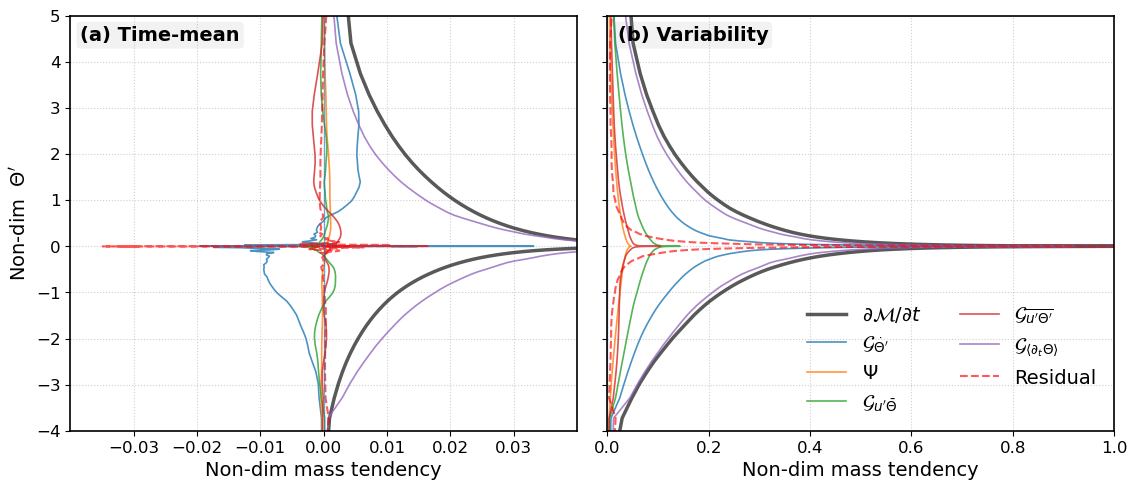

In [7]:
# ------------------------------
# Θ′ 版本 1×2（不要 (c)(d)）：
#   (a) Time-mean    (b) Variability
# ------------------------------
# 顺序必须和 cell 9 的 PRIME_VARS 一致，否则 matplotlib 的循环色会错位
full_rhs_base_vars = ["g_mix_total","g_adv","g_UpTb_total","g_UpTp_total","g_trend"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

data_list = [
    (ds_prime.mean(dim="t"), axes[0], full_rhs_base_vars, full_label_dict, "(a) Time-mean"),
    (ds_prime.std(dim="t"),  axes[1], full_rhs_base_vars, full_label_dict, "(b) Variability"),
]

main_terms = ["g_tend", "Residual"]

for data, ax, rhs_vars, label_dict, label_text in data_list:
    # g_tend (黑色粗线)
    ax.plot(data["g_tend"],
            data["tcenter"],
            linewidth=2.5,
            color="k",
            alpha=0.65,
            label=label_dict["g_tend"])

    # 其他项（细线 + alpha=0.8）
    other_terms = [v for v in rhs_vars if v not in main_terms]
    for var in other_terms:
        ax.plot(data[var],
                data["tcenter"],
                linewidth=1.2,
                alpha=0.8,
                label=label_dict.get(var, var))

    # residual（红色虚线）
    ax.plot(data["Residual"],
            data["tcenter"],
            linewidth=1.5,
            linestyle="--",
            color="red",
            alpha=0.65,
            label=label_dict["Residual"])

    # 美化
    ax.axvline(0, linewidth=1, alpha=0.6)
    ax.grid(True, linestyle=":", alpha=0.6)

    # 左上角标注
    ax.text(0.02, 0.94, label_text, transform=ax.transAxes,
            fontsize=14, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.1))

# -----------------------------
# x/y label 与坐标范围
# -----------------------------
axes[0].set_xlim(-0.04, 0.04)
axes[1].set_xlim(-0.0, 1.)

for ax in axes.flat:
    ax.set_ylim(-4, 5)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(1))

axes[0].set_xticks([-0.03,-0.02,-0.01,0,0.01,0.02,0.03])

axes[0].set_xlabel("Non-dim mass tendency")
axes[1].set_xlabel("Non-dim mass tendency")
axes[0].set_ylabel("Non-dim  " + r"$\Theta'$")

# legend 统一
handles, labels = axes[0].get_legend_handles_labels()
axes[1].legend(handles, labels, loc='lower right', ncol=2, frameon=False)

fig.subplots_adjust(left=0.08, right=0.95, top=0.95, bottom=0.12, wspace=0.06)

# 保存
fig.savefig("fig_meanstd_AWMB_totalprime_dx0035dt01.png", dpi=1000, bbox_inches="tight")
fig.savefig("fig_meanstd_AWMB_totalprime_dx0035dt01.pdf", dpi=1000, bbox_inches="tight", transparent=True)

plt.show()


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


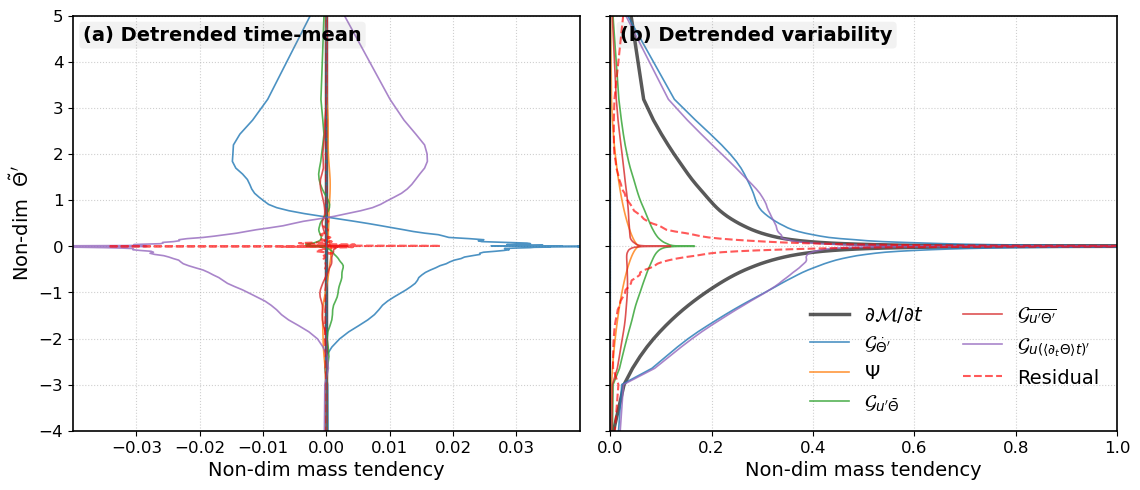

In [9]:
# ------------------------------
# Θ̃′ 版本 1×2（不要 (c)(d)）：
#   (a) Time-mean    (b) Variability
# ------------------------------
detrend_rhs_base_vars = ["g_mix_total","g_adv","g_UpTb_total","g_UpTp_total","g_uatp"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

data_list = [
    (ds_wave.mean(dim="t"), axes[0], detrend_rhs_base_vars, detrend_label_dict, "(a) Detrended time-mean"),
    (ds_wave.std(dim="t"),  axes[1], detrend_rhs_base_vars, detrend_label_dict, "(b) Detrended variability"),
]

main_terms = ["g_tend", "Residual"]

for data, ax, rhs_vars, label_dict, label_text in data_list:
    # g_tend (黑色粗线)
    ax.plot(data["g_tend"],
            data["tcenter"],
            linewidth=2.5,
            color="k",
            alpha=0.65,
            label=label_dict["g_tend"])

    # 其他项（细线 + alpha=0.8）
    other_terms = [v for v in rhs_vars if v not in main_terms]
    for var in other_terms:
        ax.plot(data[var],
                data["tcenter"],
                linewidth=1.2,
                alpha=0.8,
                label=label_dict.get(var, var))

    # residual（红色虚线）
    ax.plot(data["Residual"],
            data["tcenter"],
            linewidth=1.5,
            linestyle="--",
            color="red",
            alpha=0.65,
            label=label_dict["Residual"])

    # 美化
    ax.axvline(0, linewidth=1, alpha=0.6)
    ax.grid(True, linestyle=":", alpha=0.6)

    # 左上角标注
    ax.text(0.02, 0.94, label_text, transform=ax.transAxes,
            fontsize=14, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.2", facecolor="grey", edgecolor="none", alpha=0.1))

# -----------------------------
# x/y label 与坐标范围
# -----------------------------
axes[0].set_xlim(-0.04, 0.04)
axes[1].set_xlim(-0.0, 1.)

for ax in axes.flat:
    ax.set_ylim(-4, 5)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(1))

axes[0].set_xticks([-0.03,-0.02,-0.01,0,0.01,0.02,0.03])

axes[0].set_xlabel("Non-dim mass tendency")
axes[1].set_xlabel("Non-dim mass tendency")
axes[0].set_ylabel("Non-dim  " + r"$\tilde{\Theta}'$")

# legend 统一
handles, labels = axes[0].get_legend_handles_labels()
axes[1].legend(handles, labels, loc='lower right', ncol=2, frameon=False)

fig.subplots_adjust(left=0.08, right=0.95, top=0.95, bottom=0.12, wspace=0.06)

# 保存
fig.savefig("fig_meanstd_AWMB_waveprime_dx0035dt01.png", dpi=1000, bbox_inches="tight")
fig.savefig("fig_meanstd_AWMB_waveprime_dx0035dt01.pdf", dpi=1000, bbox_inches="tight", transparent=True)

plt.show()


In [13]:
!pwd

/data/homezvol0/ranl24/Hackthon


In [47]:
theta_value = ds_prime.tcenter.isel(tcenter=target_temp).values
theta_value

array(2.92602922)

In [50]:
theta_value = ds_wave.tcenter.isel(tcenter=target_temp).values
theta_value

array(2.19827375)

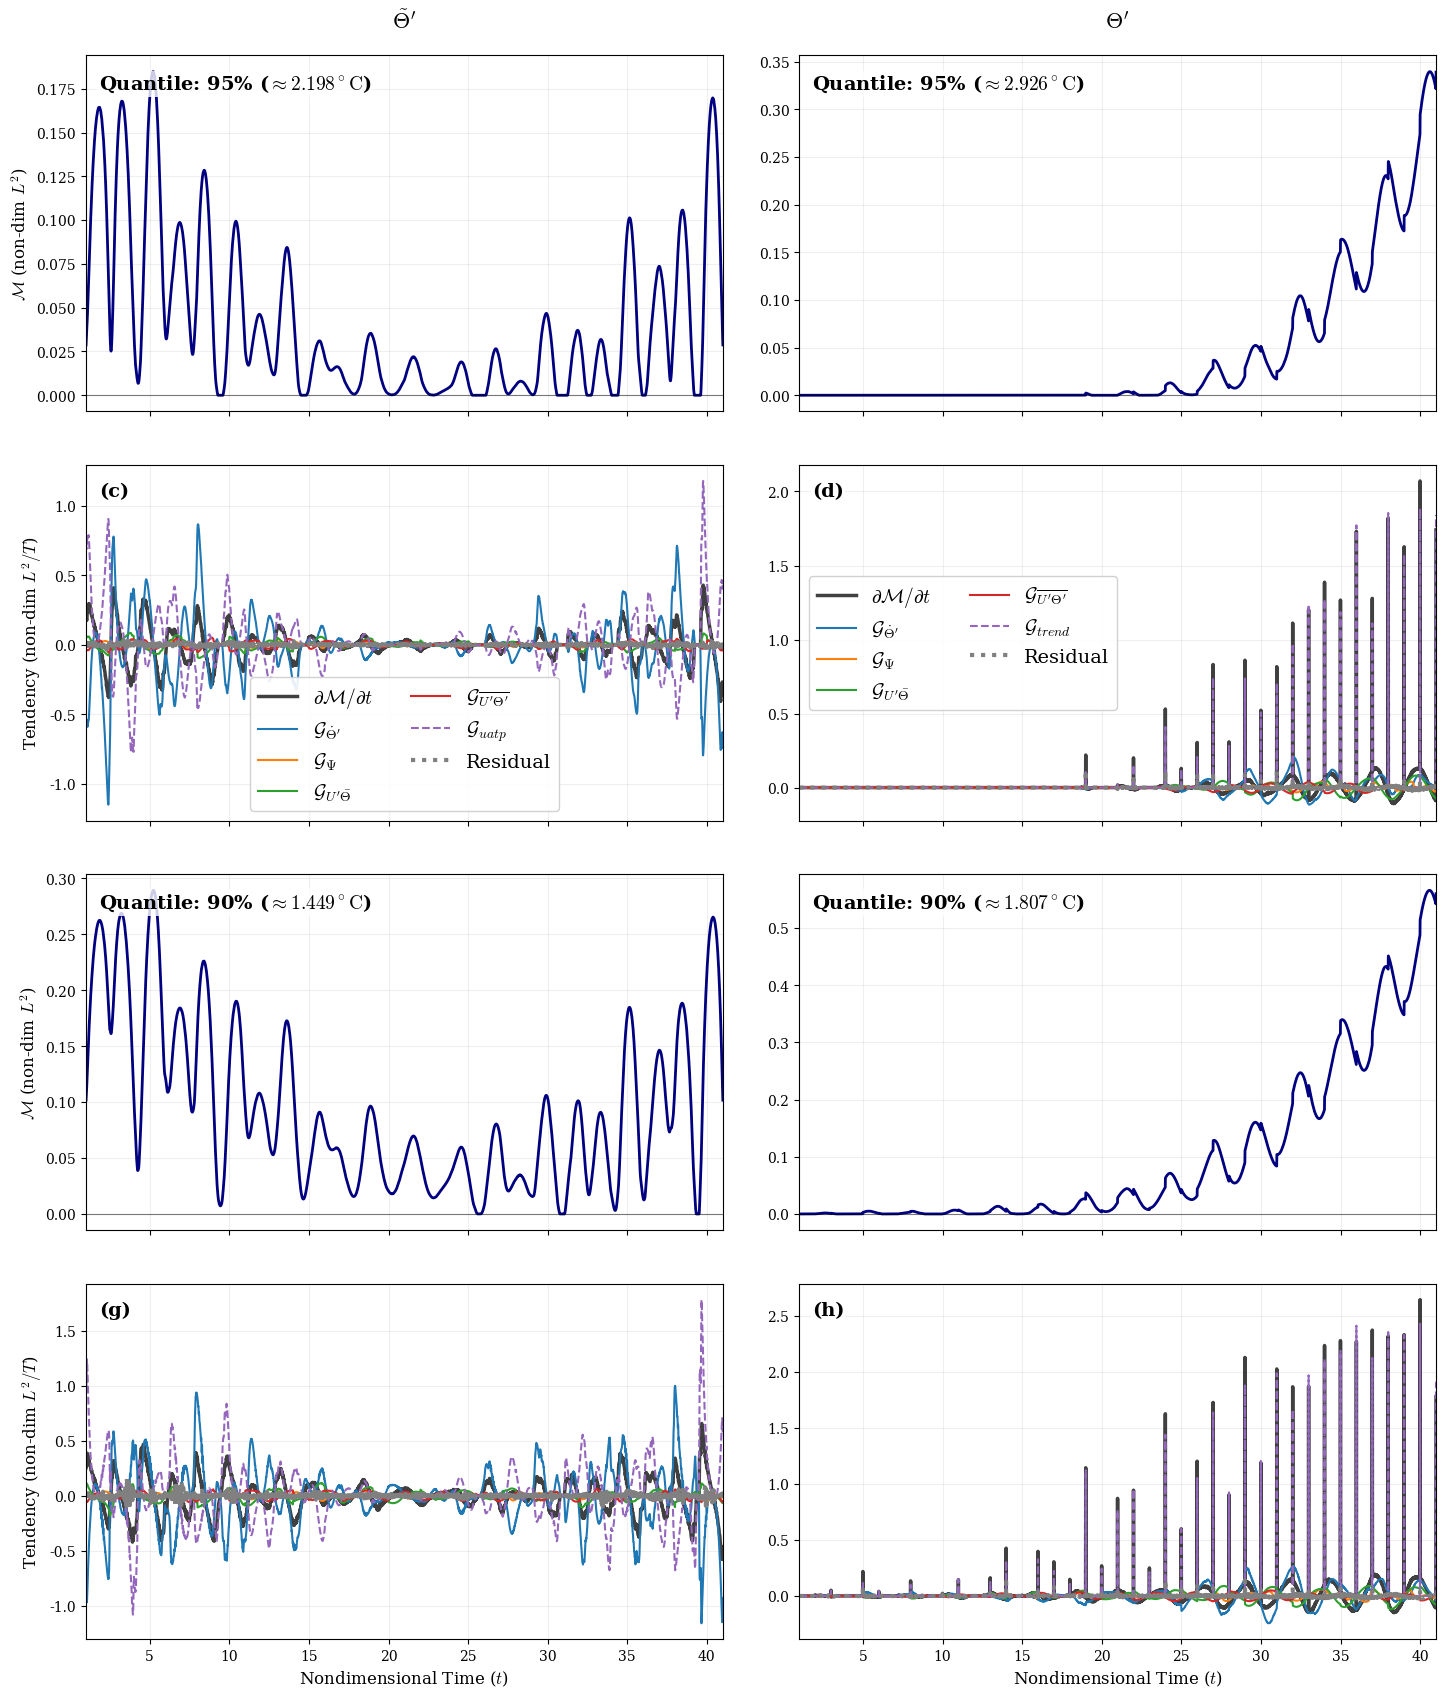

In [9]:
import matplotlib.pyplot as plt
import string

# --- 绘图配置 ---
plt.rcParams.update({
    "mathtext.fontset": "cm", 
    "font.family": "serif",
    "axes.unicode_minus": False
})

# 创建 4行2列 布局
fig, axs = plt.subplots(4, 2, figsize=(15, 18), sharex=True)

indices = [95, 90] 
modes_plot = [
    {'ds': ds_wave, 'title': r'$\tilde{\Theta}^{\prime}$', 'extra_key': 'G_uatp', 'extra_label': r"$\mathcal{G}_{uatp}$"},
    {'ds': ds_prime, 'title': r'$\Theta^{\prime}$', 'extra_key': 'G_trend', 'extra_label': r"$\mathcal{G}_{trend}$"}
]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
letters = string.ascii_lowercase

# --- 开始循环绘图 ---
for c, m_info in enumerate(modes_plot):
    ds_b = m_info['ds']
    
    for row_pair, idx in enumerate(indices):
        r_m = row_pair * 2      
        r_g = row_pair * 2 + 1  
        t_val = ds_b.tcenter[idx].values
        
        # --- 1. 绘制 M (无量纲累积量) ---
        ax_m = axs[r_m, c]
        ax_m.plot(ds_b.time_snap, ds_b.M.isel(tcenter=idx), color='navy', lw=2)
        ax_m.axhline(0, color='k', lw=0.8, alpha=0.5)
        
        if r_m == 0: 
            ax_m.set_title(m_info['title'], fontsize=16, fontweight='bold', pad=20)
        
        # 【修改点】标识 (a) (b)... 放在子图内部左上角，后面紧跟信息
        # 计算当前是第几个子图 (0-7)
        flat_idx_m = r_m * 2 + c if False else (r_m + (0 if c==0 else 0)) # 逻辑修正
        # 直接使用行列索引计算字母顺序：第一行 a,b; 第二行 c,d...
        letter_m = letters[r_m * 2 + c]

        if c == 0:
            ax_m.text(0.02, 0.95, r"$\tilde{\Theta}_{\prime}$" +" " + rf"Quantile: {idx}% ($\approx {t_val:.3f}^\circ\mathrm{{C}}$)", 
                  transform=ax_m.transAxes, fontsize=14, fontweight='bold', 
                  va='top', ha='left',
                  bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2))
        
        if c == 0:
            ax_m.set_ylabel(r'$\mathcal{M}$ (non-dim $L^2$)', fontsize=12)
        ax_m.grid(True, alpha=0.2)

        # --- 2. 绘制 Tendency Budget ---
        ax_g = axs[r_g, c]
        ax_g.plot(ds_b.t, ds_b.M_trend.isel(tcenter=idx), 'k', lw=2.5, label=r'$\partial\mathcal{M}/\partial t$', alpha=0.75)
        ax_g.plot(ds_b.t, ds_b.G_theta_dot.isel(tcenter=idx), label=r"$\mathcal{G}_{\dot{\Theta}^{\prime}}$", color=colors[0])
        ax_g.plot(ds_b.t, ds_b.G_adv.isel(tcenter=idx), label=r"$\mathcal{G}_{\Psi}$", color=colors[1])
        ax_g.plot(ds_b.t, ds_b.G_upTb.isel(tcenter=idx), label=r"$\mathcal{G}_{U^{\prime}\bar{\Theta}}$", color=colors[2])
        ax_g.plot(ds_b.t, ds_b.G_upTp.isel(tcenter=idx), label=r"$\mathcal{G}_{\overline{U^{\prime}\Theta^{\prime}}}$", color=colors[3])
        ax_g.plot(ds_b.t, ds_b[m_info['extra_key']].isel(tcenter=idx), 
                  label=m_info['extra_label'], color=colors[4], ls='--', lw=1.5)
        ax_g.plot(ds_b.t, ds_b.Residual.isel(tcenter=idx), ':', color='grey', label='Residual', alpha=1, linewidth=3)
        
        # 【修改点】Tendency图内部左上角标识
        letter_g = letters[r_g * 2 + c]
        ax_g.text(0.02, 0.95, rf"({letter_g})", 
                  transform=ax_g.transAxes, fontsize=14, fontweight='bold', 
                  va='top', ha='left',
                  bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1))

        if c == 0:
            ax_g.set_ylabel(r'Tendency (non-dim $L^2/T$)', fontsize=12)
        
        ax_g.set_xlim(1, 41)
        ax_g.grid(True, alpha=0.2)
        
        if r_g == 3: 
            ax_g.set_xlabel('Nondimensional Time ($t$)', fontsize=12)

# --- 3. 图例与间距优化 ---
# 图例放在中间行的位置，避免遮挡字母标识
axs[1, 0].legend(loc='lower center', fontsize=14, ncol=2, framealpha=0.9)
axs[1, 1].legend(loc='center left', fontsize=14, ncol=2, framealpha=0.9)

plt.subplots_adjust(hspace=0.15, wspace=0.12, top=0.94, bottom=0.06, left=0.08, right=0.98)

# 保存

plt.savefig('fig_timeseries_AWMB_dx0035dt01.png', dpi=1000)
plt.savefig('fig_timeseries_AWMB_dx0035dt01.pdf', dpi=1000)

plt.show()

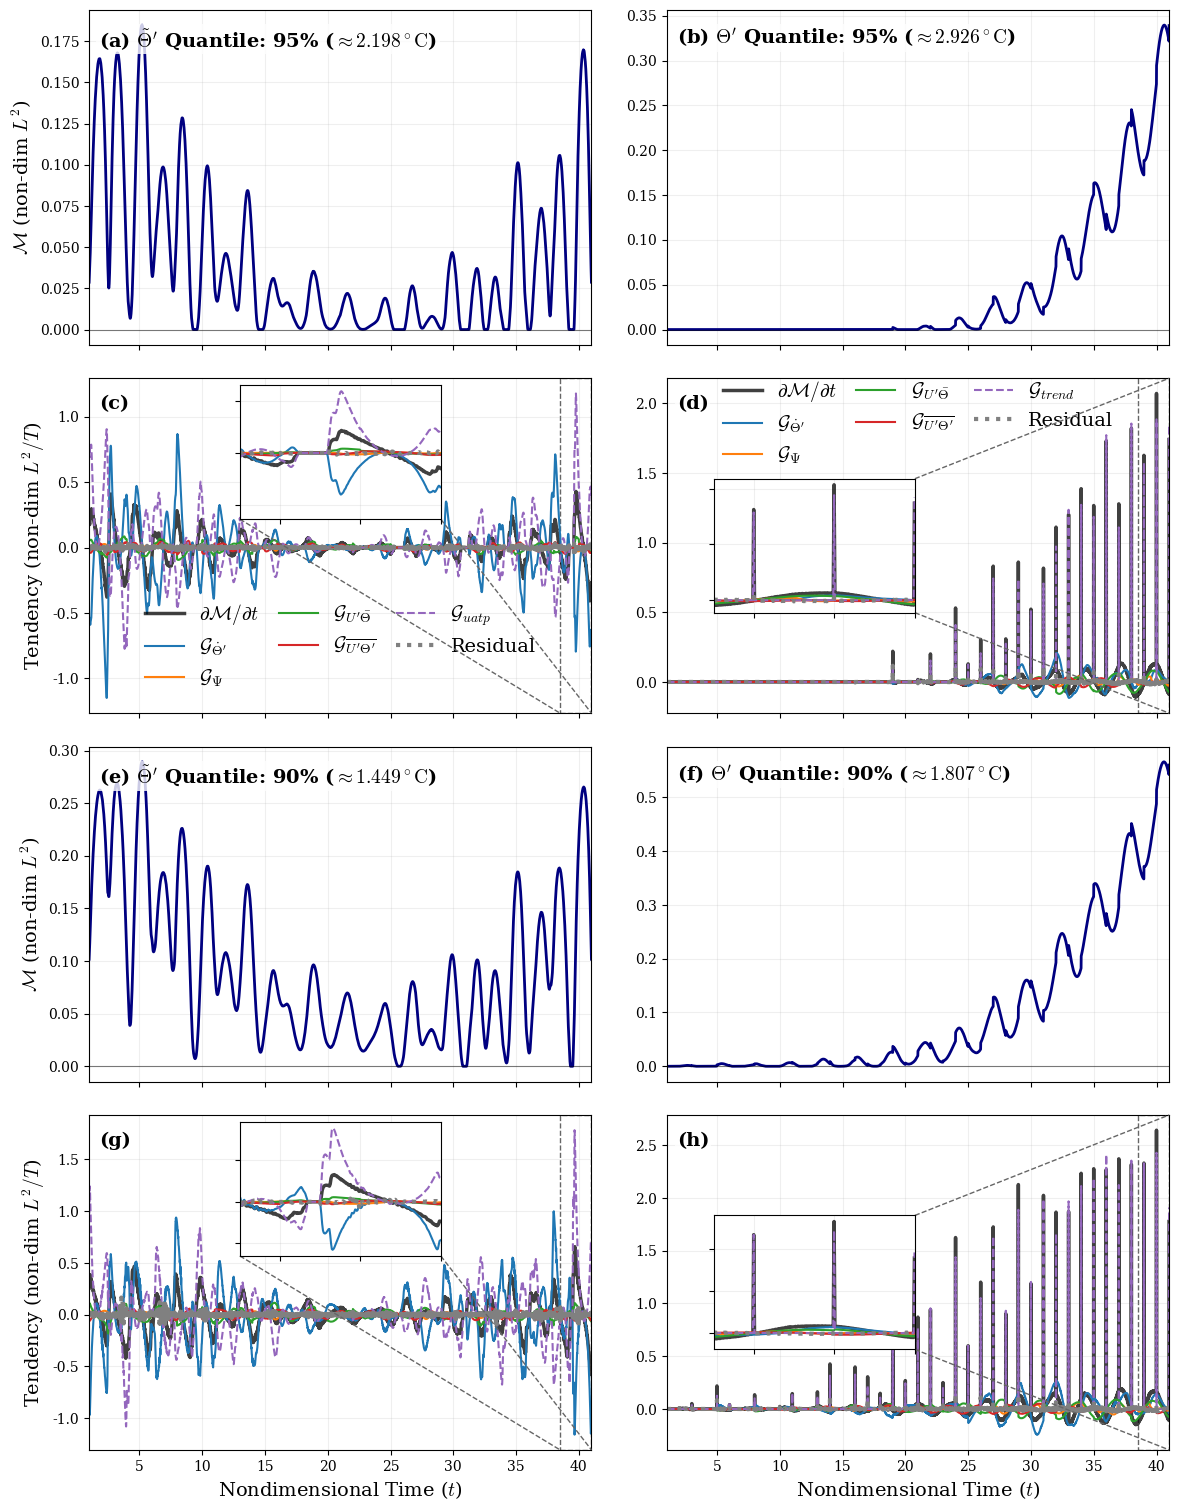

In [12]:
import matplotlib.pyplot as plt
import string
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# --- 绘图配置 ---
plt.rcParams.update({
    "mathtext.fontset": "cm", 
    "font.family": "serif",
    "axes.unicode_minus": False
})

# 创建 4行2列 布局 (缩小高度到 20 以增强紧凑感)
fig, axs = plt.subplots(4, 2, figsize=(12, 16), sharex=True)

indices = [95, 90] 
modes_plot = [
    {'ds': ds_wave, 'title': r'$\tilde{\Theta}^{\prime}$', 'extra_key': 'G_uatp', 'extra_label': r"$\mathcal{G}_{uatp}$"},
    {'ds': ds_prime, 'title': r'$\Theta^{\prime}$', 'extra_key': 'G_trend', 'extra_label': r"$\mathcal{G}_{trend}$"}
]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
letters = string.ascii_lowercase

# --- 定义绘制 Tendency Budget 的辅助函数 ---
def plot_budget(ax, ds_obj, idx, m_info):
    ax.plot(ds_obj.t, ds_obj.M_trend.isel(tcenter=idx), 'k', lw=2.5, label=r'$\partial\mathcal{M}/\partial t$', alpha=0.75)
    ax.plot(ds_obj.t, ds_obj.G_theta_dot.isel(tcenter=idx), label=r"$\mathcal{G}_{\dot{\Theta}^{\prime}}$", color=colors[0])
    ax.plot(ds_obj.t, ds_obj.G_adv.isel(tcenter=idx), label=r"$\mathcal{G}_{\Psi}$", color=colors[1])
    ax.plot(ds_obj.t, ds_obj.G_upTb.isel(tcenter=idx), label=r"$\mathcal{G}_{U^{\prime}\bar{\Theta}}$", color=colors[2])
    ax.plot(ds_obj.t, ds_obj.G_upTp.isel(tcenter=idx), label=r"$\mathcal{G}_{\overline{U^{\prime}\Theta^{\prime}}}$", color=colors[3])
    ax.plot(ds_obj.t, ds_obj[m_info['extra_key']].isel(tcenter=idx), 
             label=m_info['extra_label'], color=colors[4], ls='--', lw=1.5)
    ax.plot(ds_obj.t, ds_obj.Residual.isel(tcenter=idx), ':', color='grey', label='Residual', alpha=1, linewidth=3)

# --- 开始循环绘图 ---
for c, m_info in enumerate(modes_plot):
    ds_b = m_info['ds']
    
    for row_pair, idx in enumerate(indices):
        r_m = row_pair * 2      
        r_g = row_pair * 2 + 1  
        t_val = ds_b.tcenter[idx].values
        
        # --- 1. 绘制 M (无量纲累积量) ---
        ax_m = axs[r_m, c]
        ax_m.plot(ds_b.time_snap, ds_b.M.isel(tcenter=idx), color='navy', lw=2)
        ax_m.axhline(0, color='k', lw=0.8, alpha=0.5)
        
        #if r_m == 0: 
        #    ax_m.set_title(m_info['title'], fontsize=16, fontweight='bold', pad=15)
        
        letter_m = letters[r_m * 2 + c]
        if c == 0:
            # 注意：大括号只包裹 t_val:.3f，后面的 LaTeX 字符放在大括号外面
            ax_m.text(0.02, 0.95, rf"({letter_m}) $\tilde{{\Theta}}'$ Quantile: {idx}% ($\approx {t_val:.3f}^\circ\mathrm{{C}}$)", 
              transform=ax_m.transAxes, fontsize=14, fontweight='bold', 
              va='top', ha='left',
              bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2))
        elif c == 1:
            ax_m.text(0.02, 0.95, rf"({letter_m}) $\Theta'$ Quantile: {idx}% ($\approx {t_val:.3f}^\circ\mathrm{{C}}$)", 
              transform=ax_m.transAxes, fontsize=14, fontweight='bold', 
              va='top', ha='left',
              bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2))
        
        if c == 0:
            ax_m.set_ylabel(r'$\mathcal{M}$ (non-dim $L^2$)', fontsize=14)
        ax_m.grid(True, alpha=0.2)

        # --- 2. 绘制 Tendency Budget ---
        ax_g = axs[r_g, c]
        plot_budget(ax_g, ds_b, idx, m_info)
        
        # --- 2.1 创建放大图 (Zoom-in Inset) ---
        if c == 0:
            ins_loc = 'upper center'
            ins_bbox = (0.0, 0.0, 1, 1)
            m_loc1, m_loc2 = 3, 4 
            leg_loc = 'lower center'
            leg_bbox = (0.5, 0.02)
        else:
            ins_loc = 'center left'
            ins_bbox = (0.08, 0, 1, 1)
            m_loc1, m_loc2 = 1, 4 
            leg_loc = 'upper center'
            leg_bbox = (0.5, 1.05)

        ax_ins = inset_axes(ax_g, width="40%", height="40%", loc=ins_loc, 
                            bbox_to_anchor=ins_bbox, bbox_transform=ax_g.transAxes)
        
        plot_budget(ax_ins, ds_b, idx, m_info)
        ax_ins.set_xlim(38.5, 41)
        ax_ins.set_xticklabels([])
        ax_ins.set_yticklabels([])
        ax_ins.grid(True, alpha=0.2)
        mark_inset(ax_g, ax_ins, loc1=m_loc1, loc2=m_loc2, fc="none", ec="0.4", ls='--', lw=1)

        # --- 2.2 子图内部图例 ---
        if row_pair == 0:
            ax_g.legend(loc=leg_loc, bbox_to_anchor=leg_bbox, 
                        ncol=3, fontsize=14, frameon=False, columnspacing=1.0)

        # --- 2.3 文本标识 ---
        letter_g = letters[r_g * 2 + c]
        ax_g.text(0.02, 0.95, rf"({letter_g})", 
                  transform=ax_g.transAxes, fontsize=14, fontweight='bold', 
                  va='top', ha='left',
                  bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1))

        if c == 0:
            ax_g.set_ylabel(r'Tendency (non-dim $L^2/T$)', fontsize=14)
        
        ax_g.set_xlim(1, 41)
        ax_g.grid(True, alpha=0.2)
        
        if r_g == 3: 
            ax_g.set_xlabel('Nondimensional Time ($t$)', fontsize=14)

# --- 3. 布局关键调整：显著缩小 hspace ---
plt.subplots_adjust(hspace=0.1, wspace=0.15, top=0.96, bottom=0.06, left=0.08, right=0.98)

plt.savefig('fig_timeseries_AWMB_dx0035dt01.png', dpi=1000)
plt.savefig('fig_timeseries_AWMB_dx0035dt01.pdf', dpi=1000)

plt.show()

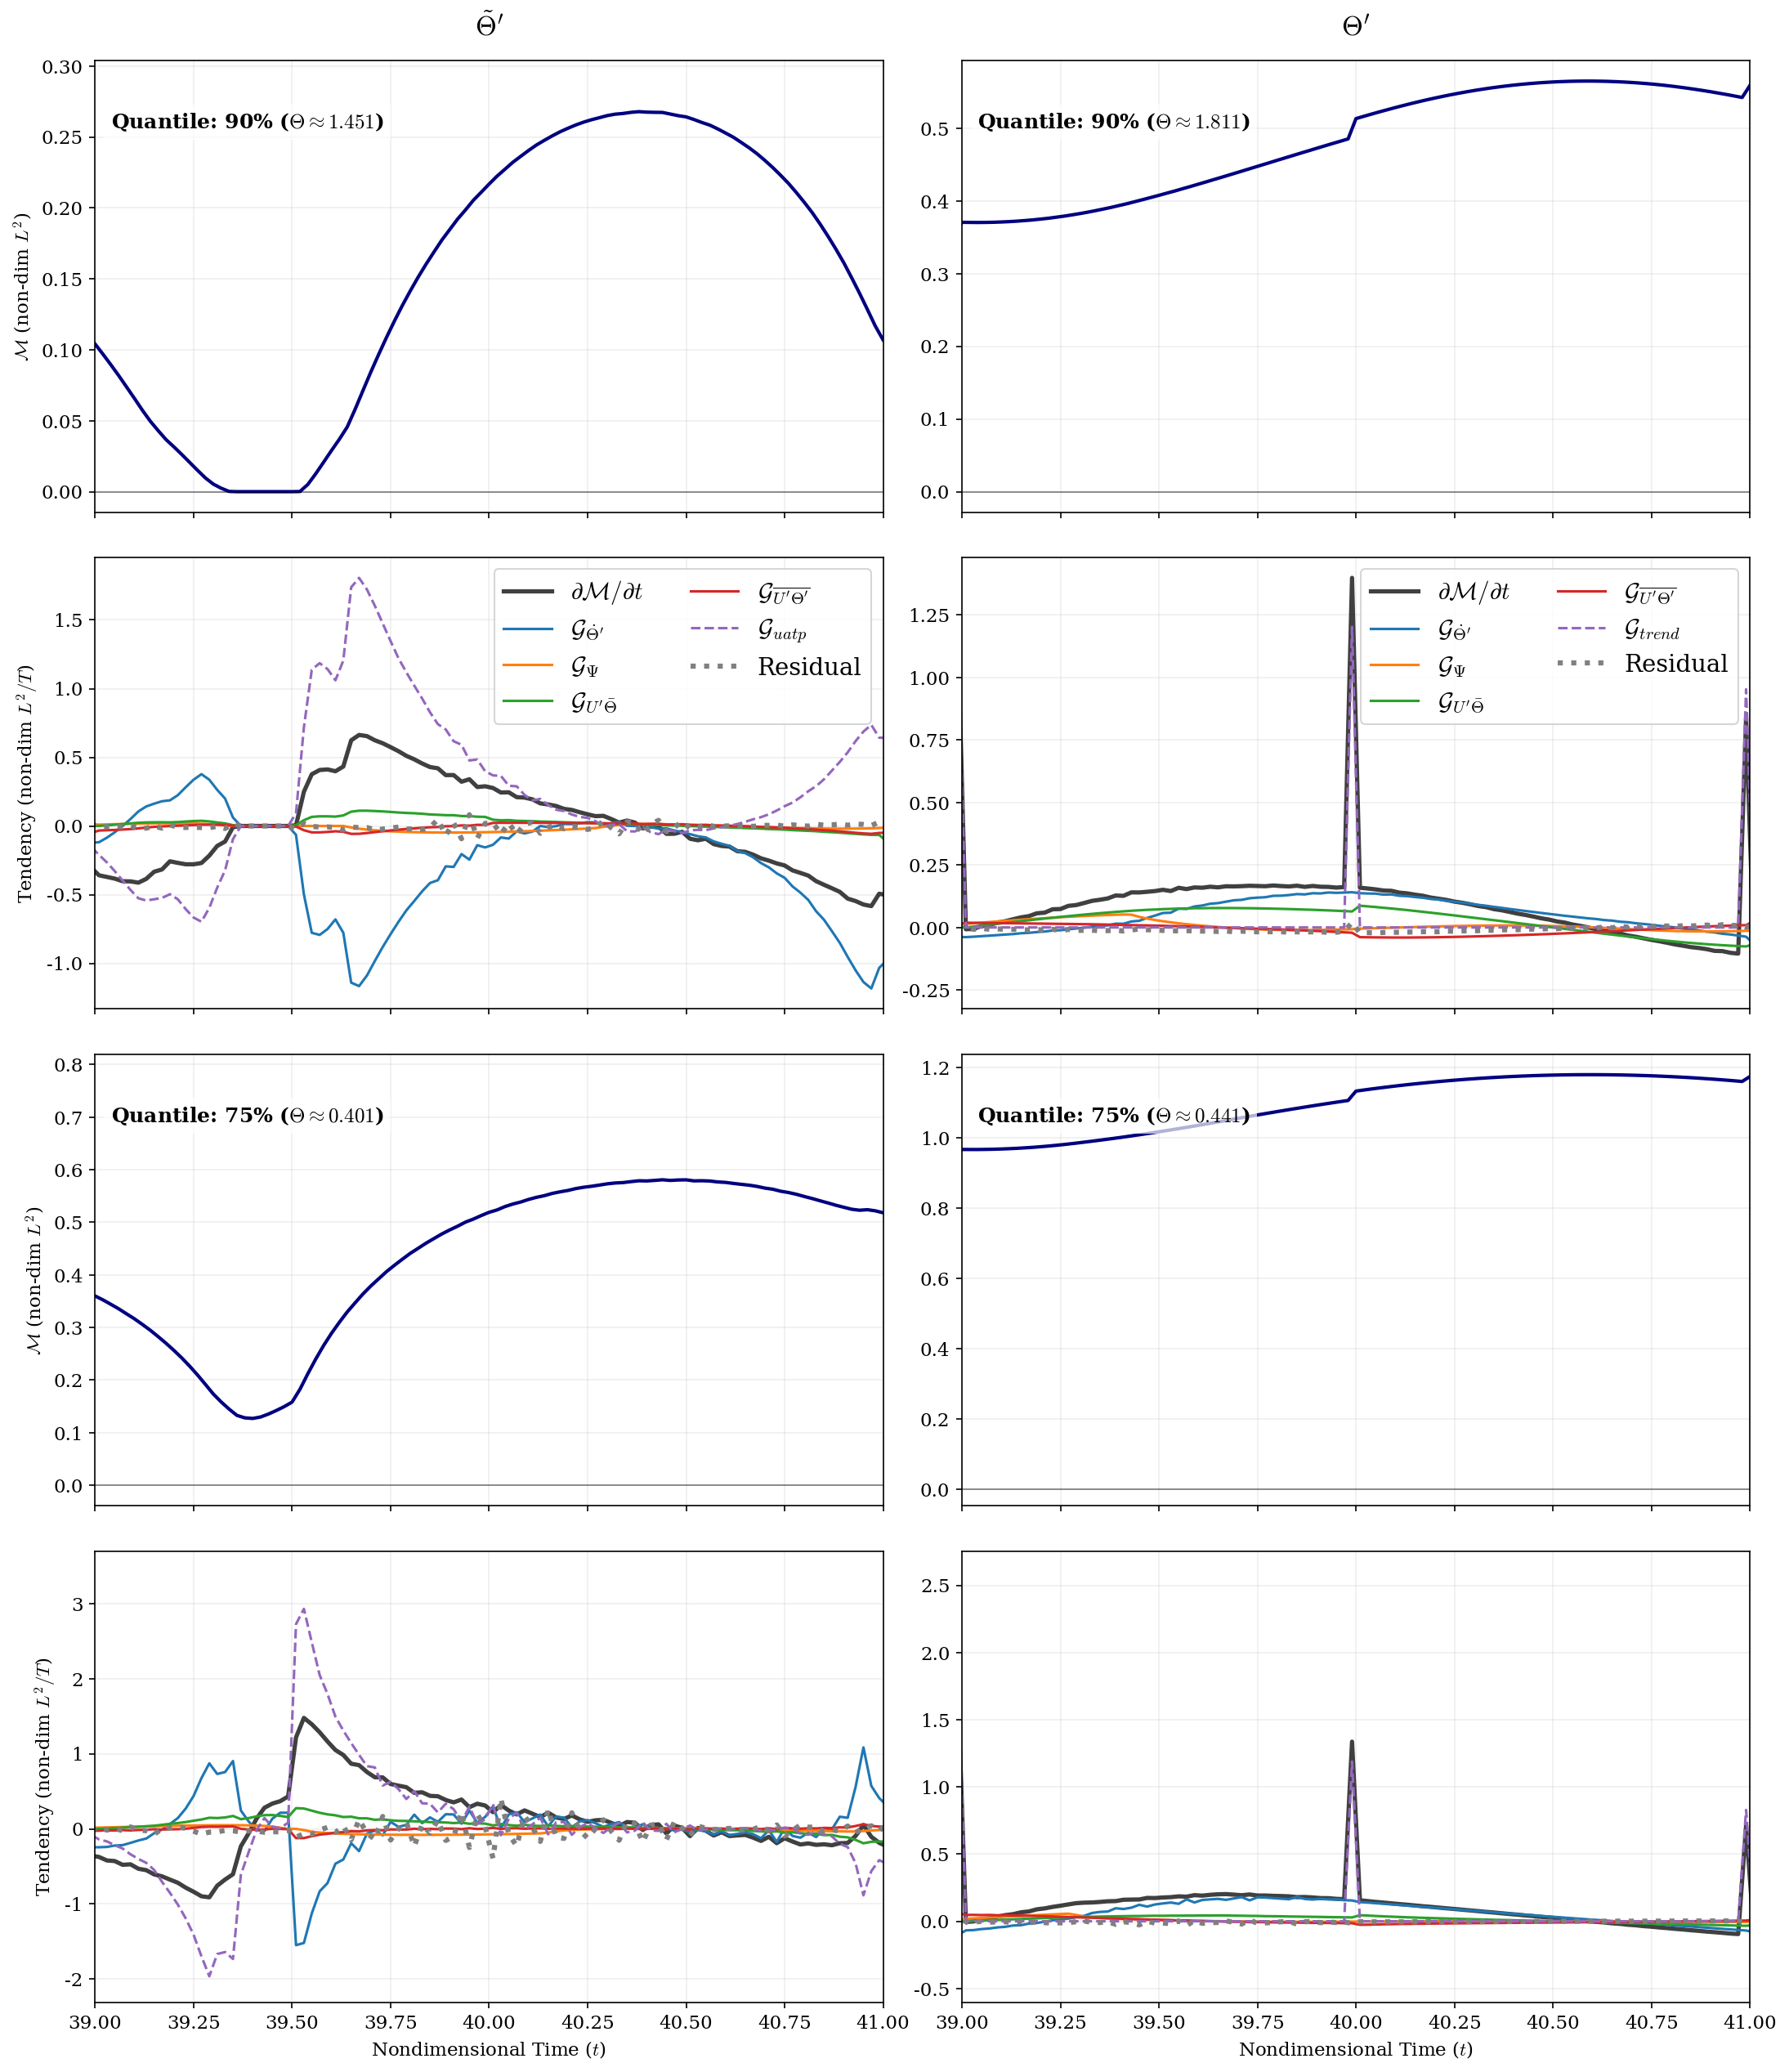

In [6]:
import matplotlib.pyplot as plt

# --- 绘图配置 ---
plt.rcParams.update({
    "mathtext.fontset": "cm", 
    "font.family": "serif",
    "axes.unicode_minus": False
})

# 创建 4行2列 布局，sharey=True 确保左右两列量级一致以便对比
fig, axs = plt.subplots(4, 2, figsize=(15, 18), sharex=True)

indices = [90, 75] 
modes_plot = [
    {
        'ds': ds_wave,  
        'title': r'$\tilde{\Theta}^{\prime}$',  
        'extra_key': 'G_uatp',  
        'extra_label': r"$\mathcal{G}_{uatp}$"
    },
    {
        'ds': ds_prime, 
        'title': r'$\Theta^{\prime}$', 
        'extra_key': 'G_trend', 
        'extra_label': r"$\mathcal{G}_{trend}$"
    }
]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# --- 开始循环绘图 ---
for c, m_info in enumerate(modes_plot):
    ds_b = m_info['ds']
    
    for row_pair, idx in enumerate(indices):
        r_m = row_pair * 2      
        r_g = row_pair * 2 + 1  
        
        t_val = ds_b.tcenter[idx].values
        
        # --- 1. 绘制 M (无量纲累积量) ---
        ax_m = axs[r_m, c]
        ax_m.plot(ds_b.time_snap, ds_b.M.isel(tcenter=idx), color='navy', lw=2)
        ax_m.axhline(0, color='k', lw=0.8, alpha=0.5)
        
        if r_m == 0: 
            ax_m.set_title(m_info['title'], fontsize=16, fontweight='bold', pad=15)
        
        ax_m.text(0.02, 0.85, rf"Quantile: {idx}% ($\Theta \approx {t_val:.3f}$)", 
                  transform=ax_m.transAxes, fontsize=12, fontweight='bold', 
                  bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
        
        # 【修改点】只为第一列设置 ylabel
        if c == 0:
            ax_m.set_ylabel(r'$\mathcal{M}$ (non-dim $L^2$)')
        
        ax_m.grid(True, alpha=0.2)

        # --- 2. 绘制 Tendency Budget ---
        ax_g = axs[r_g, c]
        ax_g.plot(ds_b.t, ds_b.M_trend.isel(tcenter=idx), 'k', lw=2.5, label=r'$\partial\mathcal{M}/\partial t$', alpha=0.75)
        ax_g.plot(ds_b.t, ds_b.G_theta_dot.isel(tcenter=idx), label=r"$\mathcal{G}_{\dot{\Theta}^{\prime}}$", color=colors[0])
        ax_g.plot(ds_b.t, ds_b.G_adv.isel(tcenter=idx), label=r"$\mathcal{G}_{\Psi}$", color=colors[1])
        ax_g.plot(ds_b.t, ds_b.G_upTb.isel(tcenter=idx), label=r"$\mathcal{G}_{U^{\prime}\bar{\Theta}}$", color=colors[2])
        ax_g.plot(ds_b.t, ds_b.G_upTp.isel(tcenter=idx), label=r"$\mathcal{G}_{\overline{U^{\prime}\Theta^{\prime}}}$", color=colors[3])
        
        ax_g.plot(ds_b.t, ds_b[m_info['extra_key']].isel(tcenter=idx), 
                  label=m_info['extra_label'], color=colors[4], ls='--', lw=1.5)
        
        ax_g.plot(ds_b.t, ds_b.Residual.isel(tcenter=idx), ':', color='grey', label='Residual', alpha=1, linewidth=3)
        
        # 【修改点】只为第一列设置 ylabel
        if c == 0:
            ax_g.set_ylabel(r'Tendency (non-dim $L^2/T$)')
        
        ax_g.set_xlim(39, 41)
        ax_g.grid(True, alpha=0.2)
        
        if r_g == 3: 
            ax_g.set_xlabel('Nondimensional Time ($t$)')

# --- 3. 统一图例处理 ---
axs[1, 0].legend(loc='upper right', fontsize=14, ncol=2, framealpha=0.8)
axs[1, 1].legend(loc='upper right', fontsize=14, ncol=2, framealpha=0.8)

# 【修改点】适当减小 wspace，使左右子图靠得更近
plt.subplots_adjust(hspace=0.1, wspace=0.1, top=0.94, bottom=0.06, left=0.08, right=0.98)

plt.show()

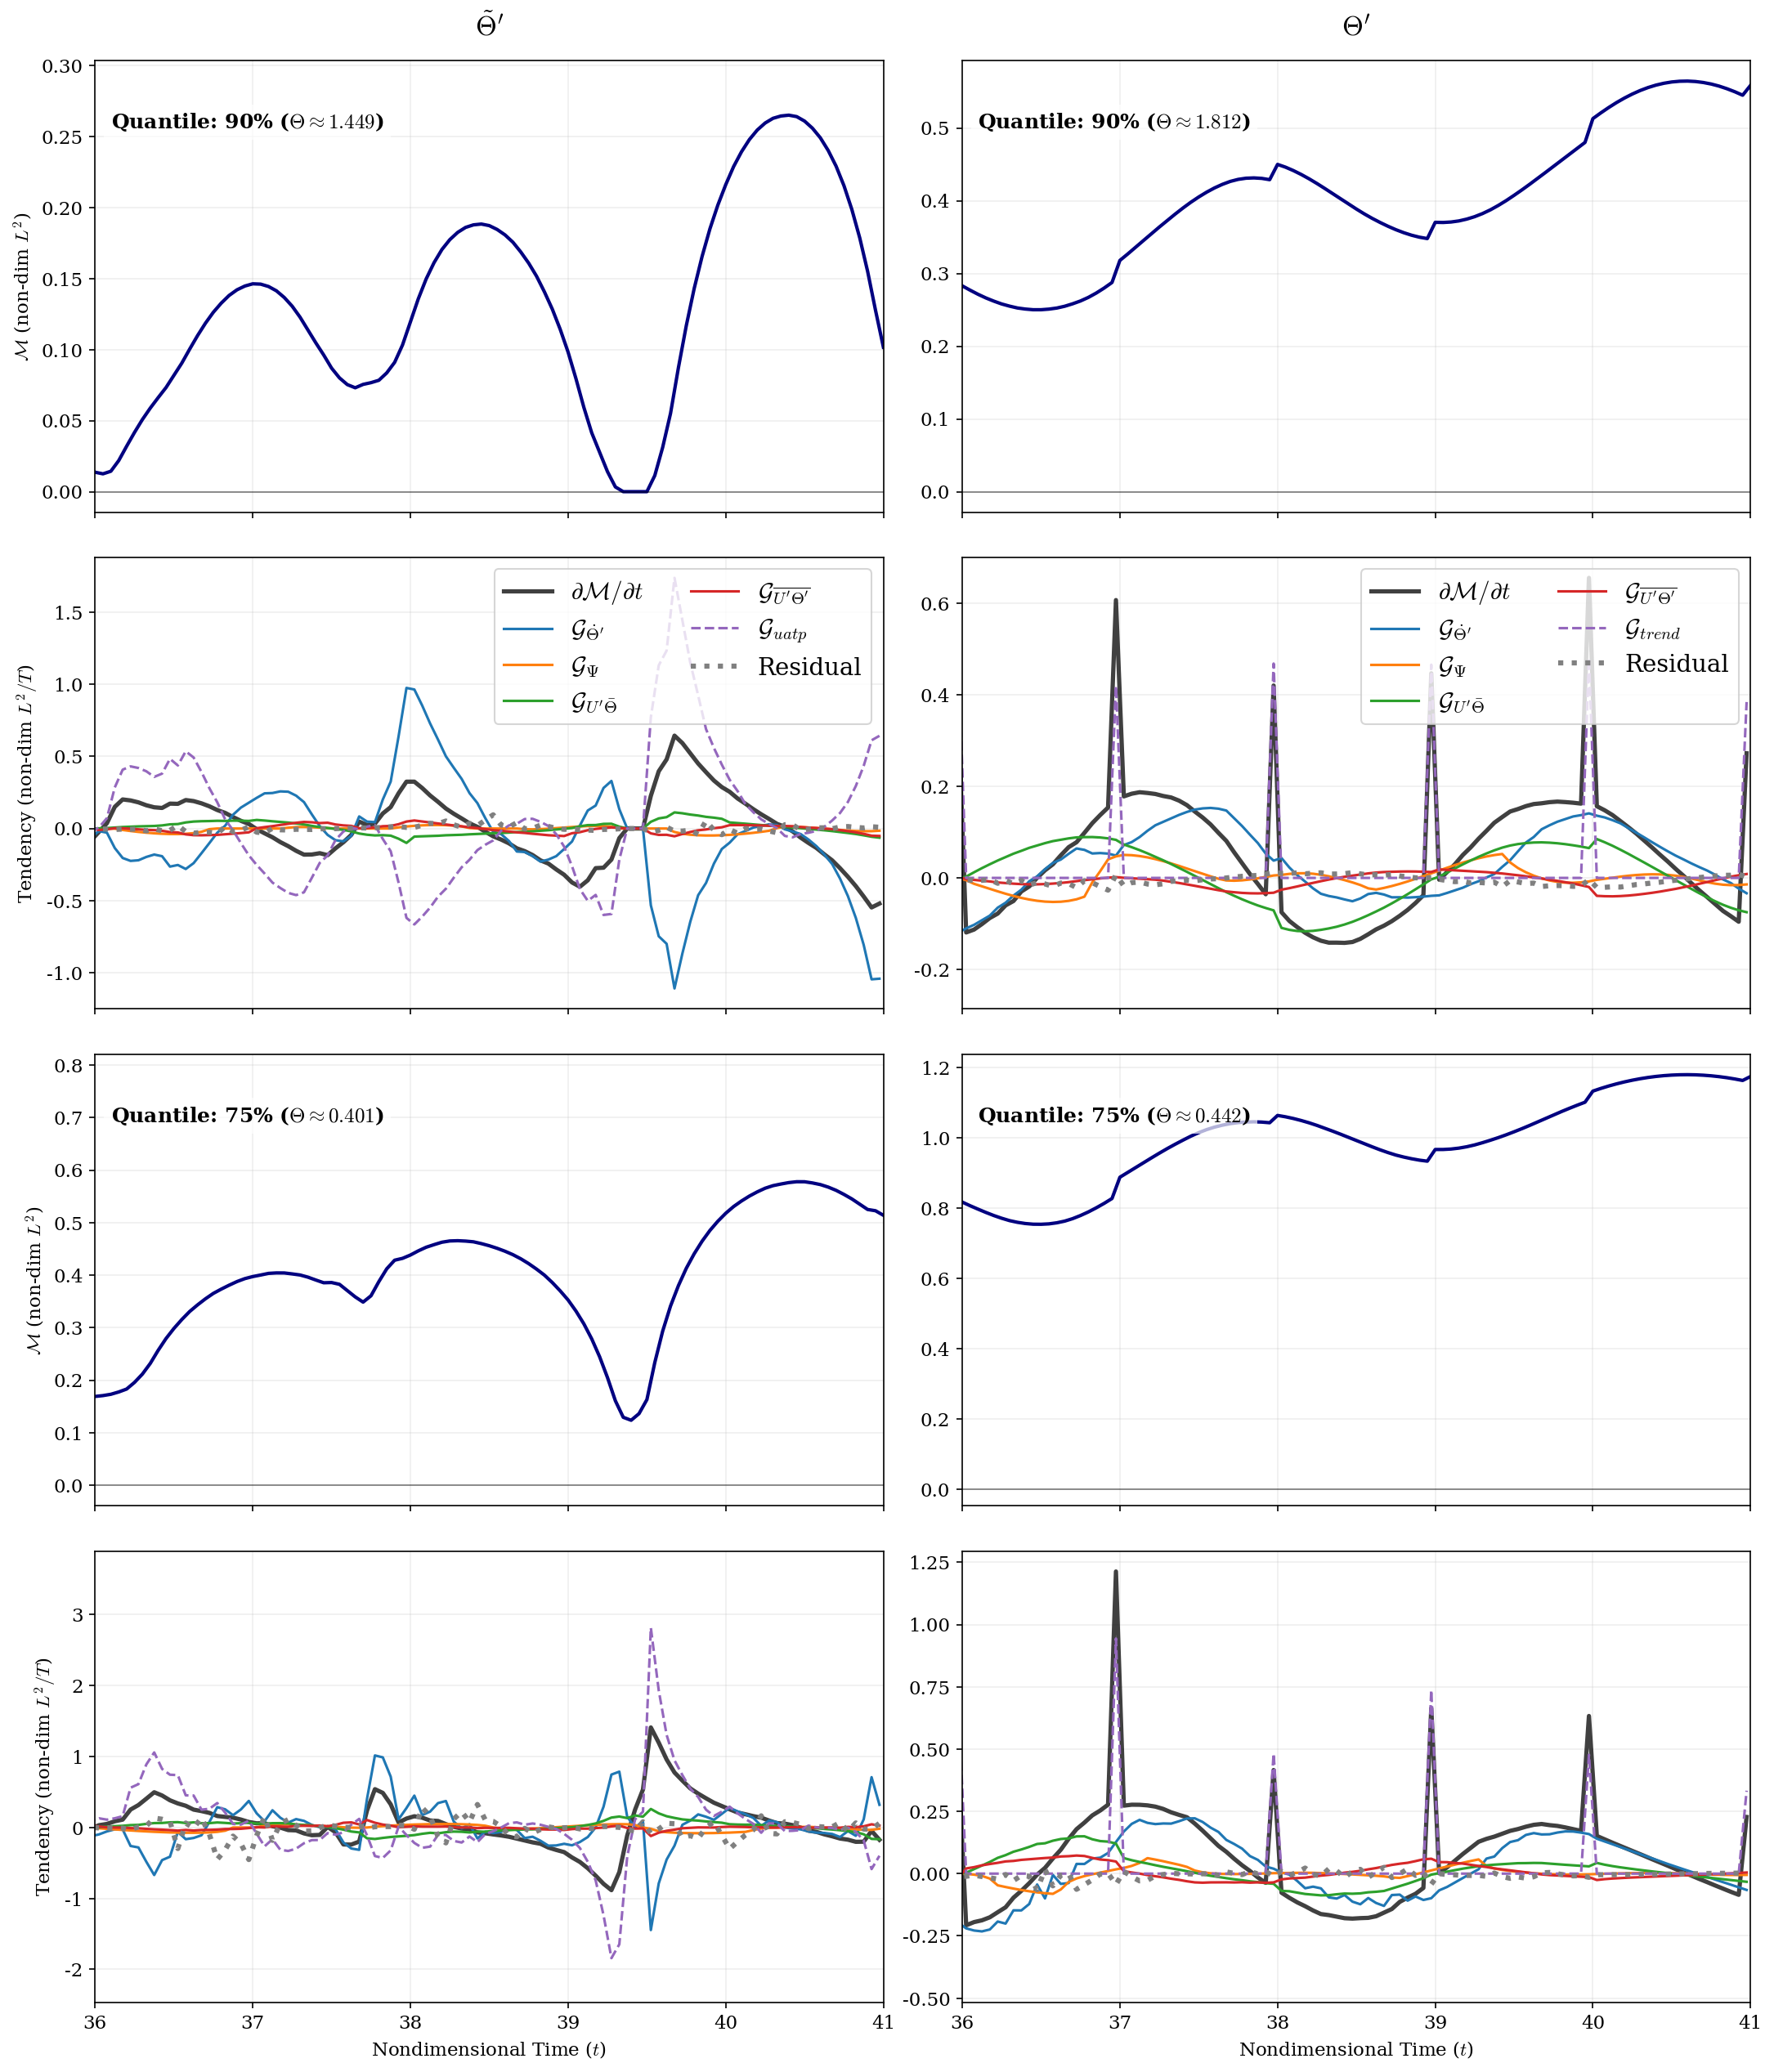

In [50]:
import matplotlib.pyplot as plt

# --- 绘图配置 ---
plt.rcParams.update({
    "mathtext.fontset": "cm", 
    "font.family": "serif",
    "axes.unicode_minus": False
})

# 创建 4行2列 布局，sharey=True 确保左右两列量级一致以便对比
fig, axs = plt.subplots(4, 2, figsize=(15, 18), sharex=True)

indices = [90, 75] 
modes_plot = [
    {
        'ds': ds_wave,  
        'title': r'$\tilde{\Theta}^{\prime}$',  
        'extra_key': 'G_uatp',  
        'extra_label': r"$\mathcal{G}_{uatp}$"
    },
    {
        'ds': ds_prime, 
        'title': r'$\Theta^{\prime}$', 
        'extra_key': 'G_trend', 
        'extra_label': r"$\mathcal{G}_{trend}$"
    }
]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# --- 开始循环绘图 ---
for c, m_info in enumerate(modes_plot):
    ds_b = m_info['ds']
    
    for row_pair, idx in enumerate(indices):
        r_m = row_pair * 2      
        r_g = row_pair * 2 + 1  
        
        t_val = ds_b.tcenter[idx].values
        
        # --- 1. 绘制 M (无量纲累积量) ---
        ax_m = axs[r_m, c]
        ax_m.plot(ds_b.time_snap, ds_b.M.isel(tcenter=idx), color='navy', lw=2)
        ax_m.axhline(0, color='k', lw=0.8, alpha=0.5)
        
        if r_m == 0: 
            ax_m.set_title(m_info['title'], fontsize=16, fontweight='bold', pad=15)
        
        ax_m.text(0.02, 0.85, rf"Quantile: {idx}% ($\Theta \approx {t_val:.3f}$)", 
                  transform=ax_m.transAxes, fontsize=12, fontweight='bold', 
                  bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
        
        # 【修改点】只为第一列设置 ylabel
        if c == 0:
            ax_m.set_ylabel(r'$\mathcal{M}$ (non-dim $L^2$)')
        
        ax_m.grid(True, alpha=0.2)

        # --- 2. 绘制 Tendency Budget ---
        ax_g = axs[r_g, c]
        ax_g.plot(ds_b.t, ds_b.M_trend.isel(tcenter=idx), 'k', lw=2.5, label=r'$\partial\mathcal{M}/\partial t$', alpha=0.75)
        ax_g.plot(ds_b.t, ds_b.G_theta_dot.isel(tcenter=idx), label=r"$\mathcal{G}_{\dot{\Theta}^{\prime}}$", color=colors[0])
        ax_g.plot(ds_b.t, ds_b.G_adv.isel(tcenter=idx), label=r"$\mathcal{G}_{\Psi}$", color=colors[1])
        ax_g.plot(ds_b.t, ds_b.G_upTb.isel(tcenter=idx), label=r"$\mathcal{G}_{U^{\prime}\bar{\Theta}}$", color=colors[2])
        ax_g.plot(ds_b.t, ds_b.G_upTp.isel(tcenter=idx), label=r"$\mathcal{G}_{\overline{U^{\prime}\Theta^{\prime}}}$", color=colors[3])
        
        ax_g.plot(ds_b.t, ds_b[m_info['extra_key']].isel(tcenter=idx), 
                  label=m_info['extra_label'], color=colors[4], ls='--', lw=1.5)
        
        ax_g.plot(ds_b.t, ds_b.Residual.isel(tcenter=idx), ':', color='grey', label='Residual', alpha=1, linewidth=3)
        
        # 【修改点】只为第一列设置 ylabel
        if c == 0:
            ax_g.set_ylabel(r'Tendency (non-dim $L^2/T$)')
        
        ax_g.set_xlim(36, 41)
        ax_g.grid(True, alpha=0.2)
        
        if r_g == 3: 
            ax_g.set_xlabel('Nondimensional Time ($t$)')

# --- 3. 统一图例处理 ---
axs[1, 0].legend(loc='upper right', fontsize=14, ncol=2, framealpha=0.8)
axs[1, 1].legend(loc='upper right', fontsize=14, ncol=2, framealpha=0.8)

# 【修改点】适当减小 wspace，使左右子图靠得更近
plt.subplots_adjust(hspace=0.1, wspace=0.1, top=0.94, bottom=0.06, left=0.08, right=0.98)

plt.show()


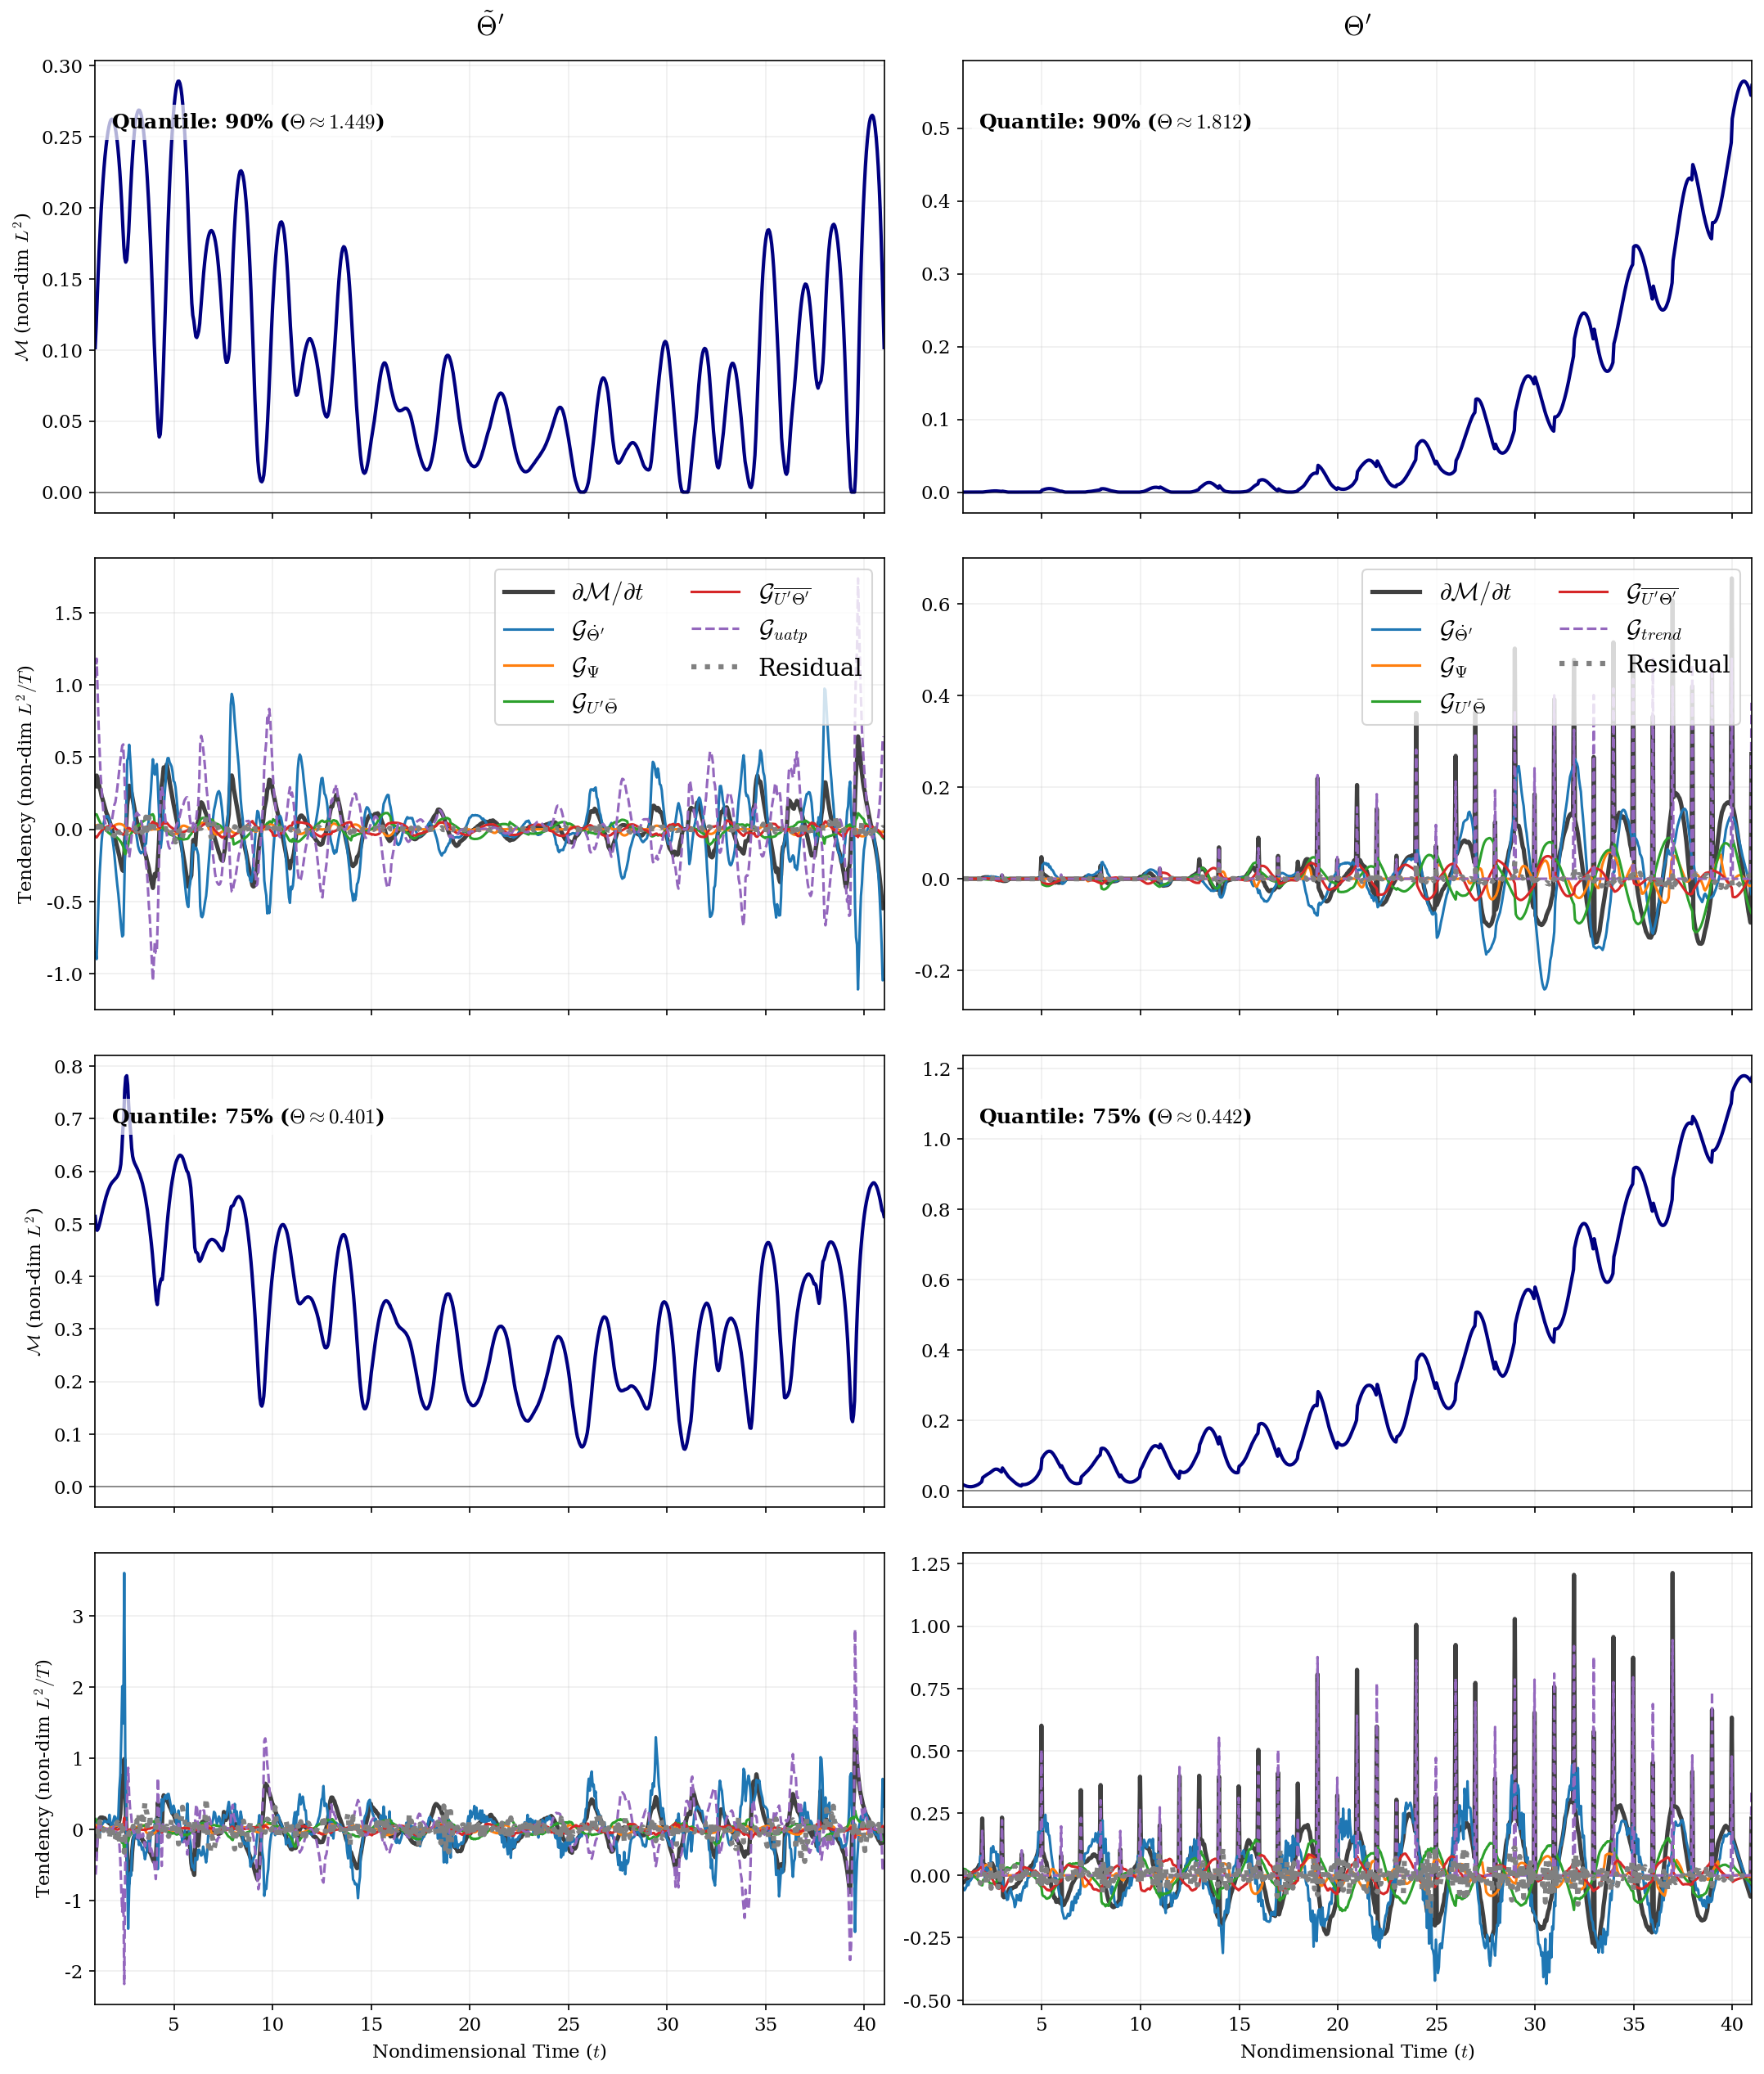

In [48]:
import matplotlib.pyplot as plt

# --- 绘图配置 ---
plt.rcParams.update({
    "mathtext.fontset": "cm", 
    "font.family": "serif",
    "axes.unicode_minus": False
})

# 创建 4行2列 布局，sharey=True 确保左右两列量级一致以便对比
fig, axs = plt.subplots(4, 2, figsize=(15, 18), sharex=True)

indices = [90, 75] 
modes_plot = [
    {
        'ds': ds_wave,  
        'title': r'$\tilde{\Theta}^{\prime}$',  
        'extra_key': 'G_uatp',  
        'extra_label': r"$\mathcal{G}_{uatp}$"
    },
    {
        'ds': ds_prime, 
        'title': r'$\Theta^{\prime}$', 
        'extra_key': 'G_trend', 
        'extra_label': r"$\mathcal{G}_{trend}$"
    }
]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# --- 开始循环绘图 ---
for c, m_info in enumerate(modes_plot):
    ds_b = m_info['ds']
    
    for row_pair, idx in enumerate(indices):
        r_m = row_pair * 2      
        r_g = row_pair * 2 + 1  
        
        t_val = ds_b.tcenter[idx].values
        
        # --- 1. 绘制 M (无量纲累积量) ---
        ax_m = axs[r_m, c]
        ax_m.plot(ds_b.time_snap, ds_b.M.isel(tcenter=idx), color='navy', lw=2)
        ax_m.axhline(0, color='k', lw=0.8, alpha=0.5)
        
        if r_m == 0: 
            ax_m.set_title(m_info['title'], fontsize=16, fontweight='bold', pad=15)
        
        ax_m.text(0.02, 0.85, rf"Quantile: {idx}% ($\Theta \approx {t_val:.3f}$)", 
                  transform=ax_m.transAxes, fontsize=12, fontweight='bold', 
                  bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
        
        # 【修改点】只为第一列设置 ylabel
        if c == 0:
            ax_m.set_ylabel(r'$\mathcal{M}$ (non-dim $L^2$)')
        
        ax_m.grid(True, alpha=0.2)

        # --- 2. 绘制 Tendency Budget ---
        ax_g = axs[r_g, c]
        ax_g.plot(ds_b.t, ds_b.M_trend.isel(tcenter=idx), 'k', lw=2.5, label=r'$\partial\mathcal{M}/\partial t$', alpha=0.75)
        ax_g.plot(ds_b.t, ds_b.G_theta_dot.isel(tcenter=idx), label=r"$\mathcal{G}_{\dot{\Theta}^{\prime}}$", color=colors[0])
        ax_g.plot(ds_b.t, ds_b.G_adv.isel(tcenter=idx), label=r"$\mathcal{G}_{\Psi}$", color=colors[1])
        ax_g.plot(ds_b.t, ds_b.G_upTb.isel(tcenter=idx), label=r"$\mathcal{G}_{U^{\prime}\bar{\Theta}}$", color=colors[2])
        ax_g.plot(ds_b.t, ds_b.G_upTp.isel(tcenter=idx), label=r"$\mathcal{G}_{\overline{U^{\prime}\Theta^{\prime}}}$", color=colors[3])
        
        ax_g.plot(ds_b.t, ds_b[m_info['extra_key']].isel(tcenter=idx), 
                  label=m_info['extra_label'], color=colors[4], ls='--', lw=1.5)
        
        ax_g.plot(ds_b.t, ds_b.Residual.isel(tcenter=idx), ':', color='grey', label='Residual', alpha=1, linewidth=3)
        
        # 【修改点】只为第一列设置 ylabel
        if c == 0:
            ax_g.set_ylabel(r'Tendency (non-dim $L^2/T$)')
        
        ax_g.set_xlim(1, 41)
        ax_g.grid(True, alpha=0.2)
        
        if r_g == 3: 
            ax_g.set_xlabel('Nondimensional Time ($t$)')

# --- 3. 统一图例处理 ---
axs[1, 0].legend(loc='upper right', fontsize=14, ncol=2, framealpha=0.8)
axs[1, 1].legend(loc='upper right', fontsize=14, ncol=2, framealpha=0.8)

# 【修改点】适当减小 wspace，使左右子图靠得更近
plt.subplots_adjust(hspace=0.1, wspace=0.1, top=0.94, bottom=0.06, left=0.08, right=0.98)

plt.show()


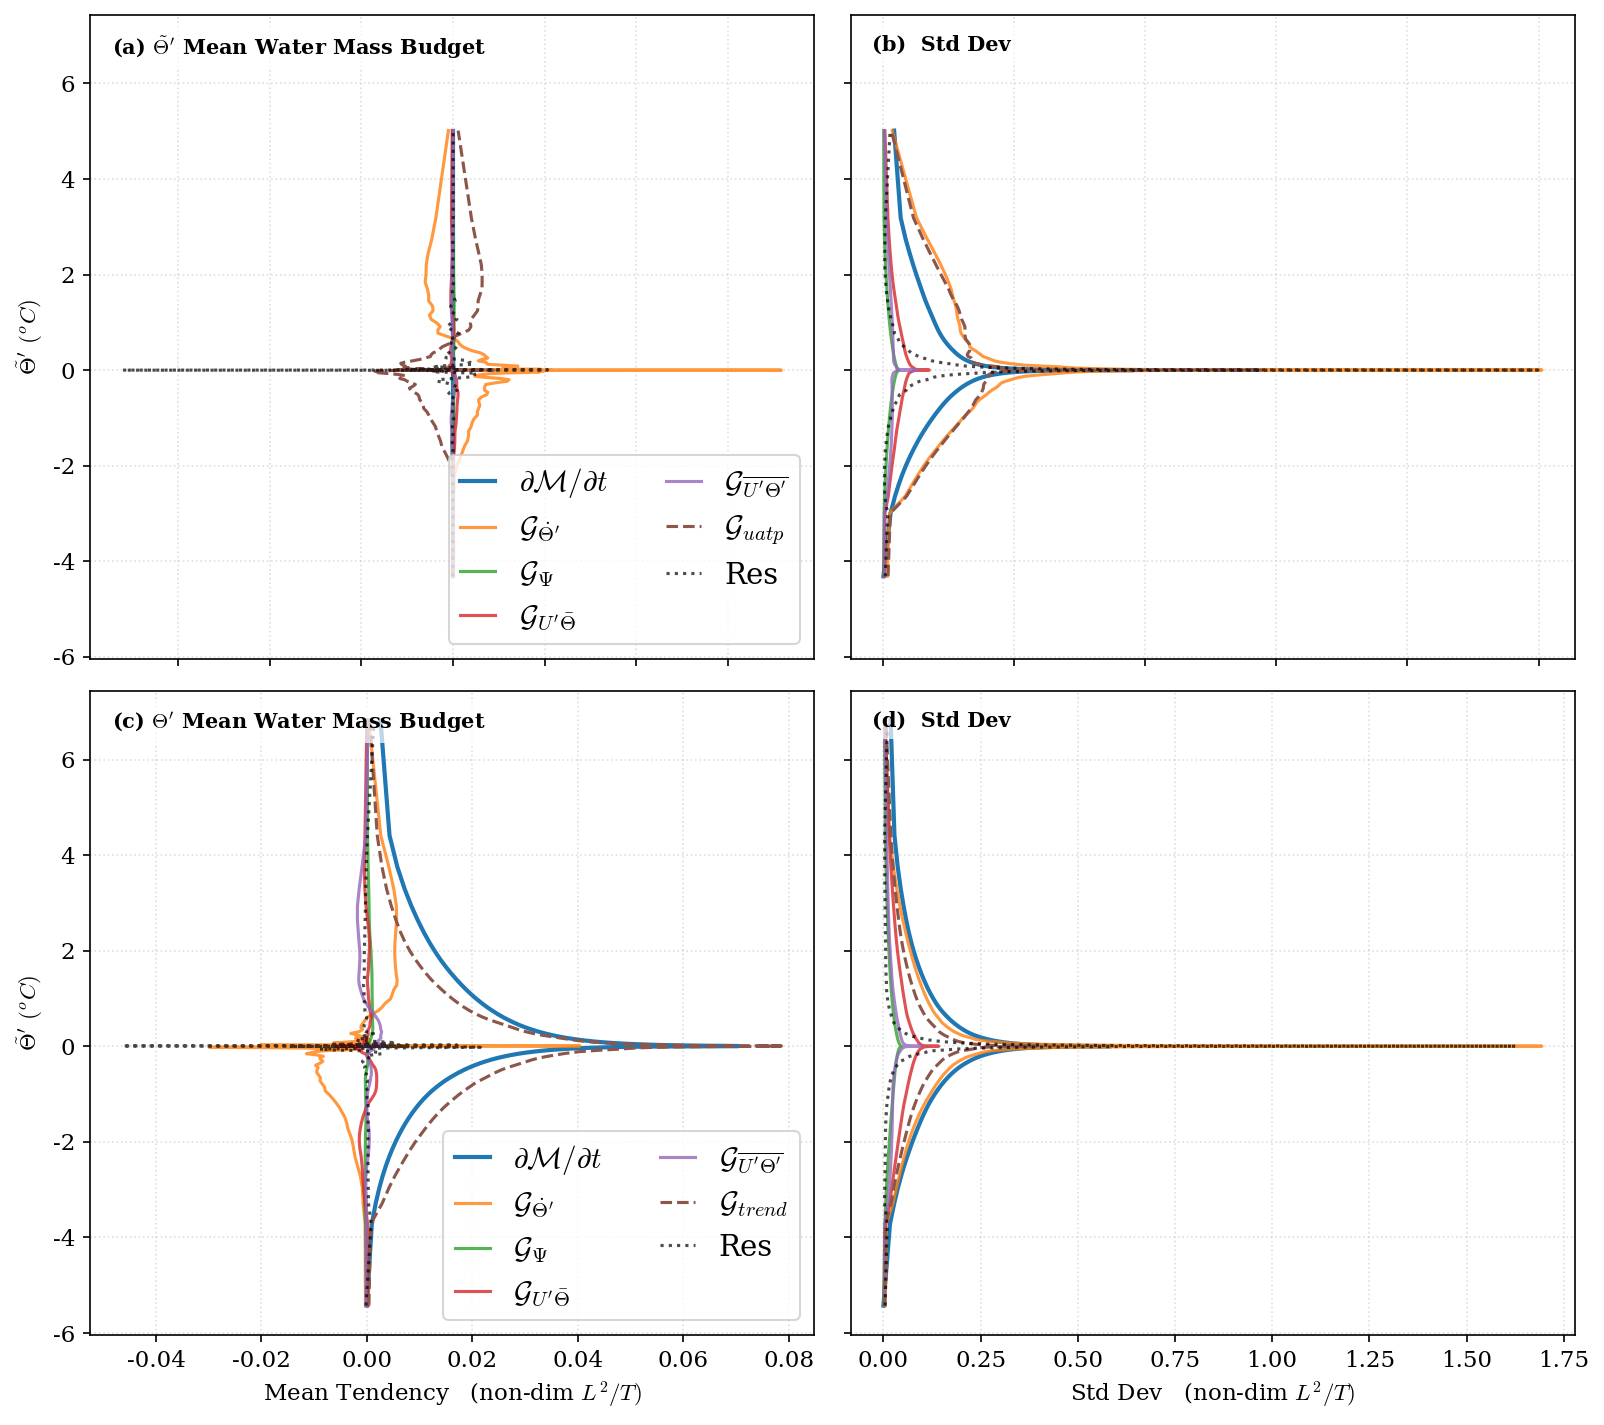

In [49]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

# --- 全局风格设置 ---
mpl.rcParams.update({
    "figure.dpi": 150,
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 11,
    "axes.linewidth": 0.8,
    "axes.unicode_minus": False,
})

# ==========================================
# 1. 绘图配置
# ==========================================
modes_plot = [
    {'ds': ds_wave, 'title': r'$\tilde{\Theta}^{\prime}$', 'extra_key': 'G_uatp', 'extra_label': r'$\mathcal{G}_{uatp}$'},
    {'ds': ds_prime, 'title':r'$\Theta^{\prime}$', 'extra_key': 'G_trend', 'extra_label': r'$\mathcal{G}_{trend}$'}
]

# 强制 sharex 和 sharey 以实现紧凑布局
fig, axs = plt.subplots(2, 2, figsize=(11, 10), sharey=True)
colors = ['C1', 'C2', 'C3', 'C4', 'C5'] 

# ==========================================
# 2. 循环绘图 (Row r: Mode, Column c: Stats)
# ==========================================
for r, m_info in enumerate(modes_plot):
    ds = m_info['ds']
    y = ds.tcenter.values
    
    # 显式计算统计量，确保数据源独立
    stats_data = [ds.mean(dim='t'), ds.std(dim='t')]
    stats_names = ['Mean Water Mass Budget', 'Std Dev']
    stats_labels = [r'Mean Tendency   (non-dim $L^2/T)$', r'Std Dev   (non-dim $L^2/T)$']
    
    for c in range(2):
        ax = axs[r, c]
        curr_ds = stats_data[c]
        
        # 绘图逻辑
        ax.plot(curr_ds.M_trend, y, 'C0', lw=2, label=r'$\partial\mathcal{M}/\partial t$')
        ax.plot(curr_ds.G_theta_dot, y, color=colors[0], alpha=0.8, label=r'$\mathcal{G}_{\dot{\Theta}^{\prime}}$')
        ax.plot(curr_ds.G_adv, y, color=colors[1], alpha=0.8, label=r'$\mathcal{G}_{\Psi}$')
        ax.plot(curr_ds.G_upTb, y, color=colors[2], alpha=0.8, label=r'$\mathcal{G}_{U^{\prime}\bar{\Theta}}$')
        ax.plot(curr_ds.G_upTp, y, color=colors[3], alpha=0.8, label=r'$\mathcal{G}_{\overline{U^{\prime}\Theta^{\prime}}}$')
        
        # 模式特有项
        ax.plot(curr_ds[m_info['extra_key']], y, color=colors[4], ls='--', lw=1.5, label=m_info['extra_label'])
        
        # 残差
        ax.plot(curr_ds.Residual, y, 'k:', lw=1.5, alpha=0.7, label='Res')
        
        # 装饰 (a, b, c, d)
        panel_id = ['(a)', '(b)'] if r == 0 else ['(c)', '(d)']
        ax.text(0.03, 0.97, f'{panel_id[c]} {m_info["title"] if c==0 else ""} {stats_names[c]}', 
                transform=ax.transAxes, fontweight='bold', va='top', fontsize=10,
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
        
        ax.grid(True, linestyle=':', alpha=0.4)

        # 仅在底部显示 x 轴标签
        if r == 1:
            ax.set_xlabel(stats_labels[c])
            
        # 仅在最左侧显示 y 轴标签
        if c == 0:
            if a == 0:
                ax.set_ylabel(r'$\Theta^{\prime}$' + ' ' + r'$(^{o}C)$')
            elif a == 1:
                ax.set_ylabel(r'$\tilde{\Theta}^{\prime}$' + ' ' + r'$(^{o}C)$')
                

    # 每一行左图显示图例，避免重复
    axs[r, 0].legend(loc='lower right', fontsize=14, ncol=2, frameon=True, handlelength=1.2)

# ==========================================
# 3. 极致紧凑化
# ==========================================
# 隐藏内部刻度标签
for ax in axs.flat:
    ax.label_outer()

# 调整子图间距，0.05 几乎消除了白边
plt.subplots_adjust(hspace=0.05, wspace=0.05, left=0.08, right=0.98, top=0.96, bottom=0.08)

plt.show()



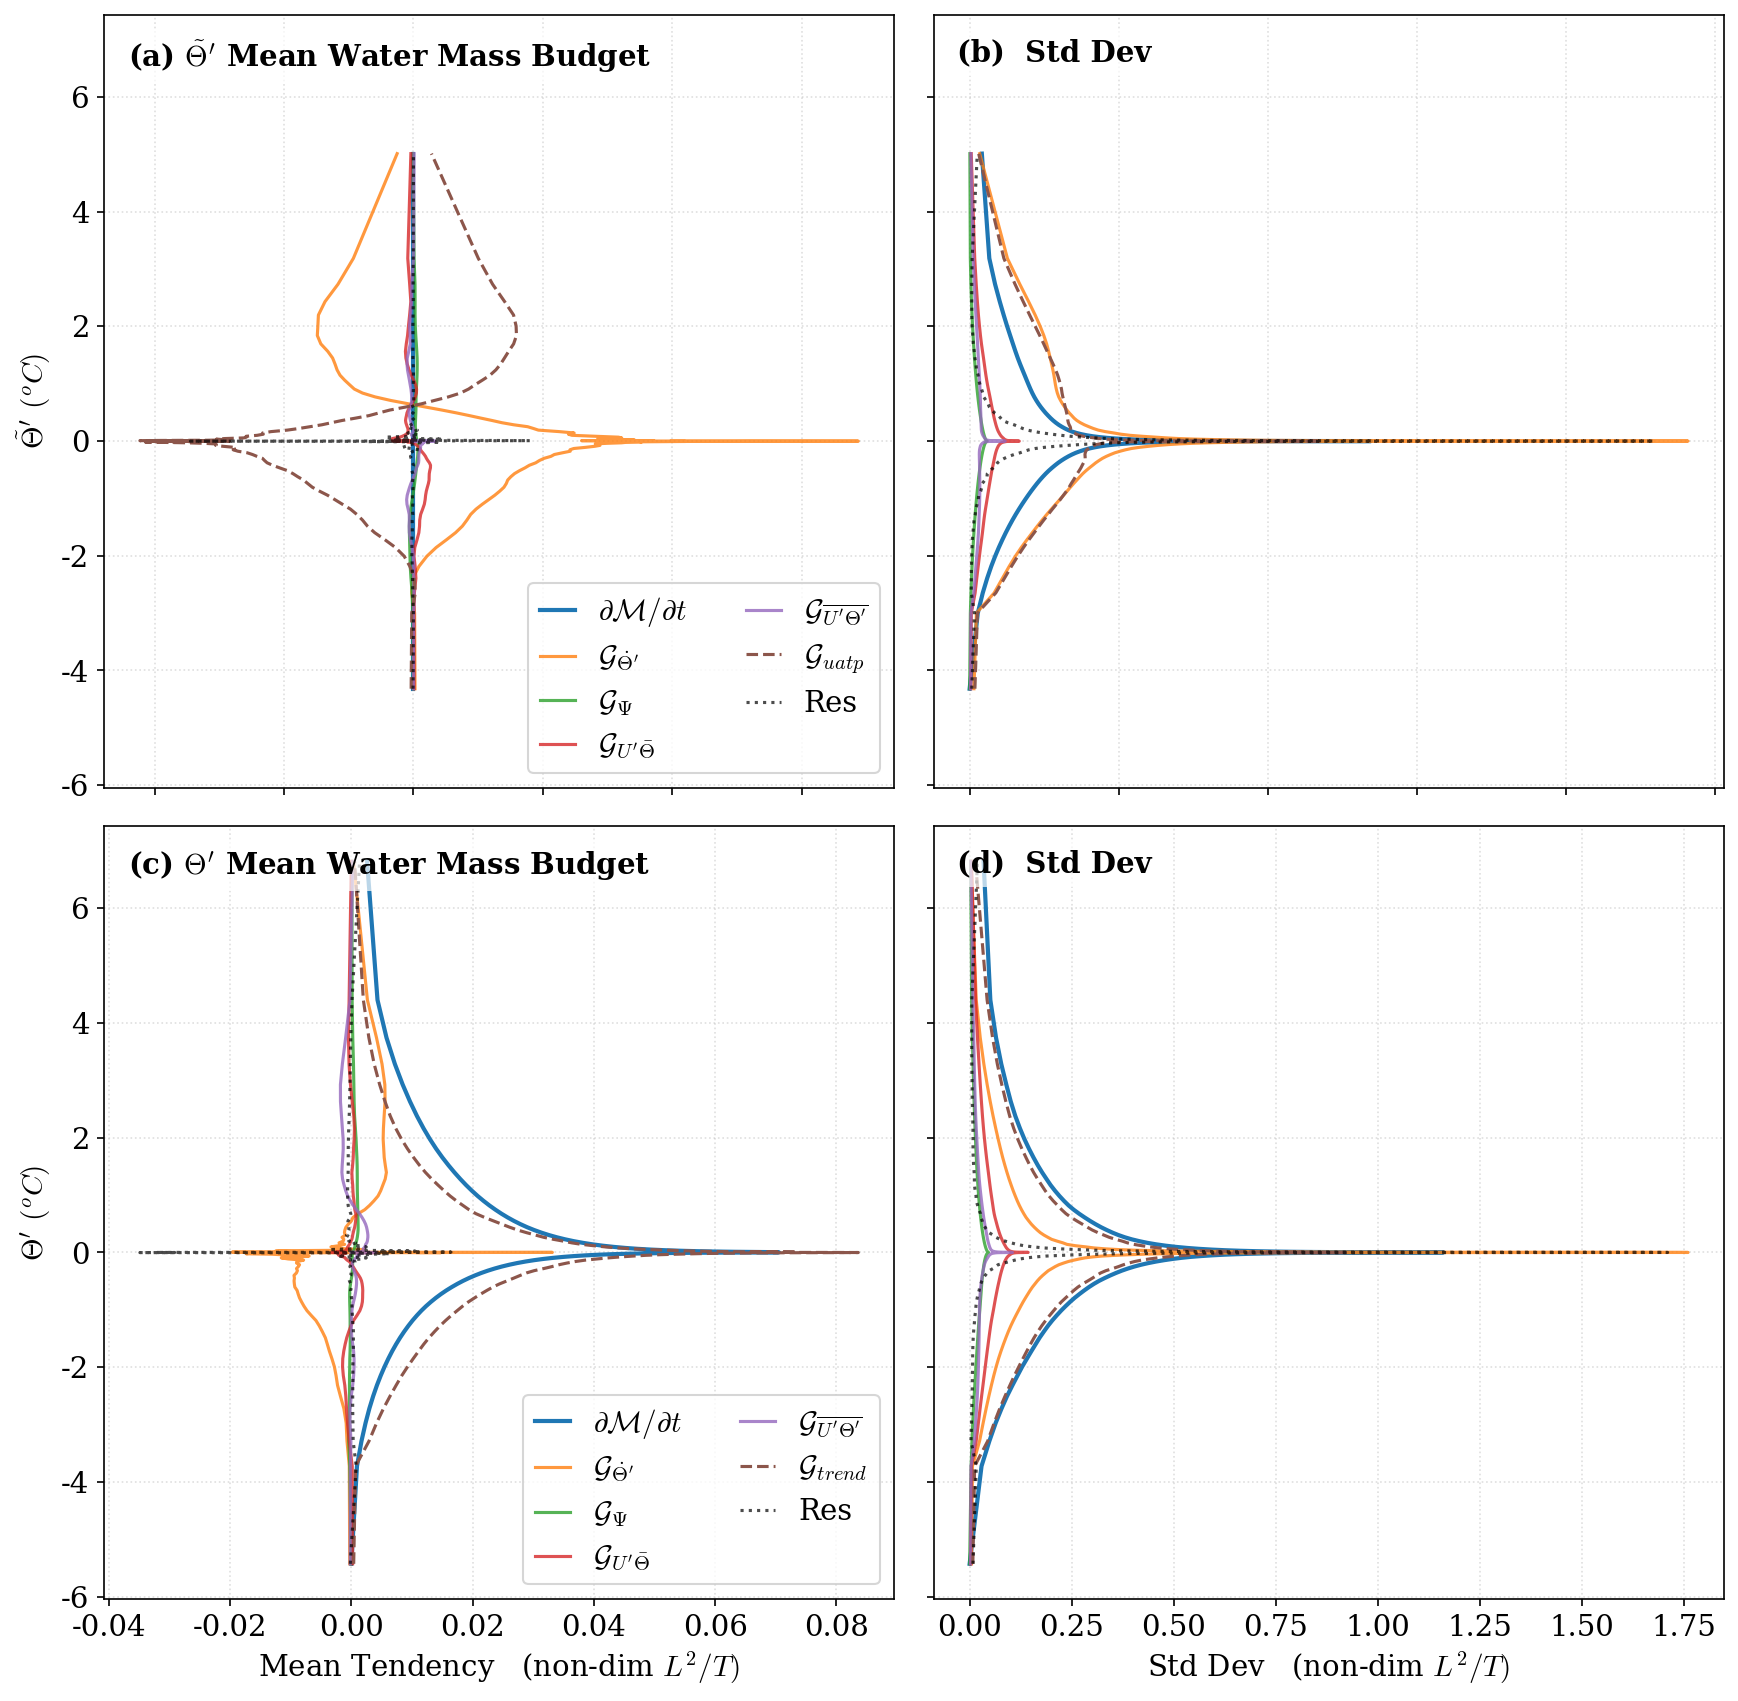

In [32]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

# --- 全局风格设置 ---
mpl.rcParams.update({
    "figure.dpi": 150,
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 14,
    "axes.linewidth": 0.8,
    "axes.unicode_minus": False,
})

# ==========================================
# 1. 绘图配置
# ==========================================
modes_plot = [
    {'ds': ds_wave, 'title': r'$\tilde{\Theta}^{\prime}$', 'extra_key': 'G_uatp', 'extra_label': r'$\mathcal{G}_{uatp}$'},
    {'ds': ds_prime, 'title':r'$\Theta^{\prime}$', 'extra_key': 'G_trend', 'extra_label': r'$\mathcal{G}_{trend}$'}
]

# 强制 sharex 和 sharey 以实现紧凑布局
fig, axs = plt.subplots(2, 2, figsize=(12, 12), sharey=True)
colors = ['C1', 'C2', 'C3', 'C4', 'C5'] 

# ==========================================
# 2. 循环绘图 (Row r: Mode, Column c: Stats)
# ==========================================
for r, m_info in enumerate(modes_plot):
    ds = m_info['ds']
    y = ds.tcenter.values
    
    # 显式计算统计量，确保数据源独立
    stats_data = [ds.mean(dim='t'), ds.std(dim='t')]
    stats_names = ['Mean Water Mass Budget', 'Std Dev']
    stats_labels = [r'Mean Tendency   (non-dim $L^2/T)$', r'Std Dev   (non-dim $L^2/T)$']
    
    for c in range(2):
        ax = axs[r, c]
        curr_ds = stats_data[c]
        
        # 绘图逻辑
        ax.plot(curr_ds.M_trend, y, 'C0', lw=2, label=r'$\partial\mathcal{M}/\partial t$')
        ax.plot(curr_ds.G_theta_dot, y, color=colors[0], alpha=0.8, label=r'$\mathcal{G}_{\dot{\Theta}^{\prime}}$')
        ax.plot(curr_ds.G_adv, y, color=colors[1], alpha=0.8, label=r'$\mathcal{G}_{\Psi}$')
        ax.plot(curr_ds.G_upTb, y, color=colors[2], alpha=0.8, label=r'$\mathcal{G}_{U^{\prime}\bar{\Theta}}$')
        ax.plot(curr_ds.G_upTp, y, color=colors[3], alpha=0.8, label=r'$\mathcal{G}_{\overline{U^{\prime}\Theta^{\prime}}}$')
        
        # 模式特有项
        ax.plot(curr_ds[m_info['extra_key']], y, color=colors[4], ls='--', lw=1.5, label=m_info['extra_label'])
        
        # 残差
        ax.plot(curr_ds.Residual, y, 'k:', lw=1.5, alpha=0.7, label='Res')
        
        # 装饰 (a, b, c, d)
        panel_id = ['(a)', '(b)'] if r == 0 else ['(c)', '(d)']
        ax.text(0.03, 0.97, f'{panel_id[c]} {m_info["title"] if c==0 else ""} {stats_names[c]}', 
                transform=ax.transAxes, fontweight='bold', va='top', fontsize=14,
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
        
        ax.grid(True, linestyle=':', alpha=0.4)

        # 仅在底部显示 x 轴标签
        if r == 1:
            ax.set_xlabel(stats_labels[c])
            
        # 仅在最左侧显示 y 轴标签
        if c == 0:
            if r == 0:
                ax.set_ylabel(r'$\tilde{\Theta}^{\prime}$' + ' ' + r'$(^{o}C)$')
            elif r == 1:
                ax.set_ylabel(r'$\Theta^{\prime}$' + ' ' + r'$(^{o}C)$')

    # 每一行左图显示图例，避免重复
    axs[r, 0].legend(loc='lower right', fontsize=14, ncol=2, frameon=True, handlelength=1.2)

# ==========================================
# 3. 极致紧凑化
# ==========================================
# 隐藏内部刻度标签
for ax in axs.flat:
    ax.label_outer()

# 调整子图间距，0.05 几乎消除了白边
plt.subplots_adjust(hspace=0.05, wspace=0.05, left=0.08, right=0.98, top=0.96, bottom=0.08)

plt.savefig('fig_meanstd_AWMB_dx0035dt01.png',dpi=1000)
plt.savefig('fig_meanstd_AWMB_dx0035dt01.pdf',dpi=1000)

plt.show()

In [13]:
z = ds.z.values
t = ds.t.values
x = ds.x.values
time_snap = ds.time_snap.values

dx = 0.0035
dt = 0.05

u_daily = ds.u_avg.transpose('t','x','z')
T_snap_prime_da = ds.T_snap_anom.transpose('time_snap','x','z')
T_prime_da      = ds.T_avg_anom.transpose('t','x','z')
Twave_snap_prime_da = ds.Twave_anom.transpose('time_snap','x','z')
Twave_prime_da      = ds.Twave_avg_anom.transpose('t','x','z')
Tdot_prime_da   = ds.Tdot_anom.transpose('t','x','z')
ebar_adv_da     = ds.upTxbar.transpose('t','x','z')
eddy_adv_da     = ds.upTxp_bar.transpose('t','x','z')
ue_adv_da       = ds.uTanb1_anom_x.transpose('t','x','z')
dTabadt         = ds.dTabadt.transpose('t','x','z')

# Left boundary: keep original values at the first x, zero elsewhere
adv_lda = xr.zeros_like(u_daily)
adv_lda.loc[dict(x=u_daily.x[0])] = u_daily.isel(x=0)

# Right boundary: keep original values at the last x, zero elsewhere
adv_rda = xr.zeros_like(u_daily)
adv_rda.loc[dict(x=u_daily.x[-1])] = u_daily.isel(x=-1)


# -----------------------------
# 构建 outer 坐标和 dx_array
# -----------------------------
# -----------------------------
# Construct outer z coordinates and dz array
# -----------------------------
z_outer = np.empty(len(z)+1)

# Interior faces: midpoints between layer centers
z_outer[1:-1] = 0.5 * (z[:-1] + z[1:])

# Surface face: assume first layer thickness extends from slightly above surface to first center
z_outer[0] = z[0] - 0.5 * (z[1]-z[0])   # slightly above first layer center

# Bottom face: extend from last layer center
z_outer[-1] = z[-1] + 0.5 * (z[-1]-z[-2])

# Convert to xarray DataArray
z_outer_da = xr.DataArray(z_outer, dims=['z_outer'])

# Compute layer thicknesses
dz_array = np.diff(z_outer)
# dz_array only depends on z, shape (Nz,)
dz_da = xr.DataArray(dz_array, dims=['z'], coords={'z': T_snap_prime_da.z.values})

# Expand to time and x dimensions (broadcasting)
dz_da = dz_da.expand_dims({ 'x': x})  # dims will be ('z','t','x')

# Reorder dimensions to ('t','x','z')
dz_da = dz_da.transpose('x','z')

dzt_da = dz_da.expand_dims({ 'time_snap': time_snap})
                           
# Horizontal spacing
dx_array = np.ones(x.shape)*dx  # make same length as x

dx_da = xr.DataArray(dx_array, dims=['x'], coords={'x': x})

# Compute 2D cell area (x,z) for each time
# dz_da already has shape (t,x,z)
area_da = dx_da * dz_da           # broadcasting: (t,x) * (t,x,z) -> (t,x,z)
area_da = area_da.transpose('x','z')


In [14]:
# 1️⃣ 取出所有非 NaN 温度样本
T_flat = Twave_snap_prime_da.values.flatten()
T_flat = T_flat[~np.isnan(T_flat)]

# 2️⃣ 按分位数确定边界（比如分成 100 个 bin）
n_bins = 100
quantiles = np.linspace(0, 1, n_bins + 1)
t_edges = np.quantile(T_flat, quantiles)

# 3️⃣ 根据边界计算中心值
tcenters = 0.5 * (t_edges[:-1] + t_edges[1:])
dtcenters = np.diff(t_edges)  # 每个 bin 的温度宽度（非均匀）

# 4️⃣ 转成 DataArray
tcen_outer = xr.DataArray(t_edges, dims=['tcenter'])

del T_flat, t_edges

# -----------------------------
# 构建 Dataset 和 xgcm Grid
# -----------------------------

ds_anom_snap = xr.Dataset({ 'dz': dzt_da.rename({"time_snap":"t"}) ,
                            'T' : Twave_snap_prime_da.rename({"time_snap":"t"}), }).assign_coords({'z_outer': z_outer})

ds_anom_daily = xr.Dataset({
    'T'   :      Twave_prime_da,
    'uatp':     (ue_adv_da    *area_da    ).transpose('t','x','z'),
    'Tdot':     (Tdot_prime_da*area_da    ).transpose('t','x','z'),
    'upTb':     (ebar_adv_da  *area_da    ).transpose('t','x','z'),
    'upTp':     (eddy_adv_da  *area_da    ).transpose('t','x','z'),
    'adv_left': (adv_lda      *dz_da      ).transpose('t','x','z'),
    'adv_right':(adv_rda      *dz_da      ).transpose('t','x','z')  })

ds_anom_daily = ds_anom_daily.assign_coords({'z_outer': z_outer})

grid_snap  = xgcm.Grid(ds_anom_snap , coords={'Z':{'center':'z', 'outer':'z_outer'}}, periodic=False, autoparse_metadata=False)
grid_daily = xgcm.Grid(ds_anom_daily, coords={'Z':{'center':'z', 'outer':'z_outer'}}, periodic=False, autoparse_metadata=False)
#grid = xgcm.Grid(ds, coords={'X':{'center':'x'}}, periodic=False, autoparse_metadata=False)


ds_anom_daily['T_outer'] = grid_daily.interp(ds_anom_daily['T'], 'Z', boundary='extend')
ds_anom_snap['T_outer']  = grid_snap.interp( ds_anom_snap['T'] , 'Z', boundary='extend')


In [15]:
# -----------------------------
# conservative transform
# -----------------------------
thickness = grid_snap.transform(ds_anom_snap['dz'], 'Z', 
    target=tcen_outer,
    method='conservative',
    target_data=ds_anom_snap.T_outer)

Tdot_theta = grid_daily.transform(ds_anom_daily['Tdot'], 'Z', 
    target=tcen_outer, 
    method='conservative',
    target_data=ds_anom_daily.T_outer)

uatp_theta = grid_daily.transform(ds_anom_daily['uatp'], 'Z', 
    target=tcen_outer, 
    method='conservative',
    target_data=ds_anom_daily.T_outer)

upTb_theta = grid_daily.transform(ds_anom_daily['upTb'], 'Z', 
    target=tcen_outer, 
    method='conservative',
    target_data=ds_anom_daily.T_outer)

upTp_theta = grid_daily.transform(ds_anom_daily['upTp'], 'Z', 
    target=tcen_outer, 
    method='conservative',
    target_data=ds_anom_daily.T_outer)

ladv_theta = grid_daily.transform(ds_anom_daily['adv_left'], 'Z', 
    target=tcen_outer, 
    method='conservative',
    target_data=ds_anom_daily.T_outer)

radv_theta = grid_daily.transform(ds_anom_daily['adv_right'], 'Z', 
    target=tcen_outer, 
    method='conservative',
    target_data=ds_anom_daily.T_outer)

thickness = thickness.fillna(0)
Tdot_theta = Tdot_theta.fillna(0)
uatp_theta = uatp_theta.fillna(0)
upTb_theta = upTb_theta.fillna(0)
upTp_theta = upTp_theta.fillna(0)
ladv_theta = ladv_theta.fillna(0)
radv_theta = radv_theta.fillna(0)


# -----------------------------
# cumulative > tcenter
# -----------------------------
M = (thickness*dx_da).sum('x').isel(tcenter=slice(None, None, -1)).cumsum(dim='tcenter').isel(tcenter=slice(None, None, -1))
M_trend = M.diff('t') / dt 
M_trend = M_trend.assign_coords({'t': t})

# budgets
# trend

guatp = np.zeros([len(t), len(tcenters)])
for i in range(0,len(tcenters)-1):
    guatp[:,i] = ( np.sum(uatp_theta[:,:,i].values,axis=1) + np.sum(uatp_theta[:,:,i-1].values, axis=1) )/(dtcenters[i]+dtcenters[i-1])

guatp = xr.DataArray(guatp,
    dims=['t', 'tcenter'],
    coords={'t': t, 'tcenter': tcenters})


gmat = np.zeros([len(t), len(tcenters)])
for i in range(0,len(tcenters)-1):
    gmat[:,i] = ( np.sum(Tdot_theta[:,:,i].values,axis=1) + np.sum(Tdot_theta[:,:,i-1].values, axis=1) )/(dtcenters[i]+dtcenters[i-1])

gmat = xr.DataArray(gmat,
    dims=['t', 'tcenter'],
    coords={'t': t, 'tcenter': tcenters})


# upTp
gupTp = np.zeros([len(t), len(tcenters)])
for i in range(0,len(tcenters)-1):
    gupTp[:,i] = ( np.sum(upTp_theta[:,:,i].values,axis=1) + np.sum(upTp_theta[:,:,i-1].values, axis=1) )/(dtcenters[i]+dtcenters[i-1])

gupTp = xr.DataArray(gupTp,
    dims=['t', 'tcenter'],
    coords={'t': t, 'tcenter': tcenters})


# upTb
gupTb = np.zeros([len(t), len(tcenters)])
for i in range(0,len(tcenters)-1):
    gupTb[:,i] = ( np.sum(upTb_theta[:,:,i].values,axis=1) + np.sum(upTb_theta[:,:,i-1].values, axis=1) )/(dtcenters[i]+dtcenters[i-1])

gupTb = xr.DataArray(gupTb,
    dims=['t', 'tcenter'],
    coords={'t': t, 'tcenter': tcenters})

#
#gadv = ladv_theta[0:-1,:]  - radv_theta[0:-1,:]
#gadv_cum = gadv.isel(tcenter=slice(None, None, -1)).cumsum(dim='tcenter').isel(tcenter=slice(None, None, -1))

ladv_theta_cum = ladv_theta.sum('x').isel(tcenter=slice(None, None, -1)).cumsum(dim='tcenter').isel(tcenter=slice(None, None, -1))
radv_theta_cum = radv_theta.sum('x').isel(tcenter=slice(None, None, -1)).cumsum(dim='tcenter').isel(tcenter=slice(None, None, -1))
gadv_cum       = ladv_theta_cum - radv_theta_cum


In [16]:
import xarray as xr

# 1.1 Mean

RHS = gmat + gadv_cum + gupTb + gupTp + guatp
residual = M_trend - RHS


# 构建 Dataset，把每个分量和总和、残差都保存进去
ds_budget = xr.Dataset(
    {
        "G_theta_dot": gmat,        # 热力学项
        "G_uatp" :    guatp,       # warming term
        "G_adv"  : gadv_cum,          # 平流项
        "G_upTb" : gupTb,            # 平均流-扰动项
        "G_upTp" : gupTp,            # 涡旋项
        "M_trend": M_trend,         # 水团趋势
        "Residual": residual,               # 残差
        "M": M.rename({"t":"time_snap"}),
        "RHS":RHS,
        "residual":residual,
    },
    coords={
        "t": M_trend.t.values,                        # 时间坐标
        "time_snap":time_snap,
        "tcenter": M_trend.tcenter.values,     # 当前阈值坐标
    }, )


1.4487561714836326
0.4010900696048327


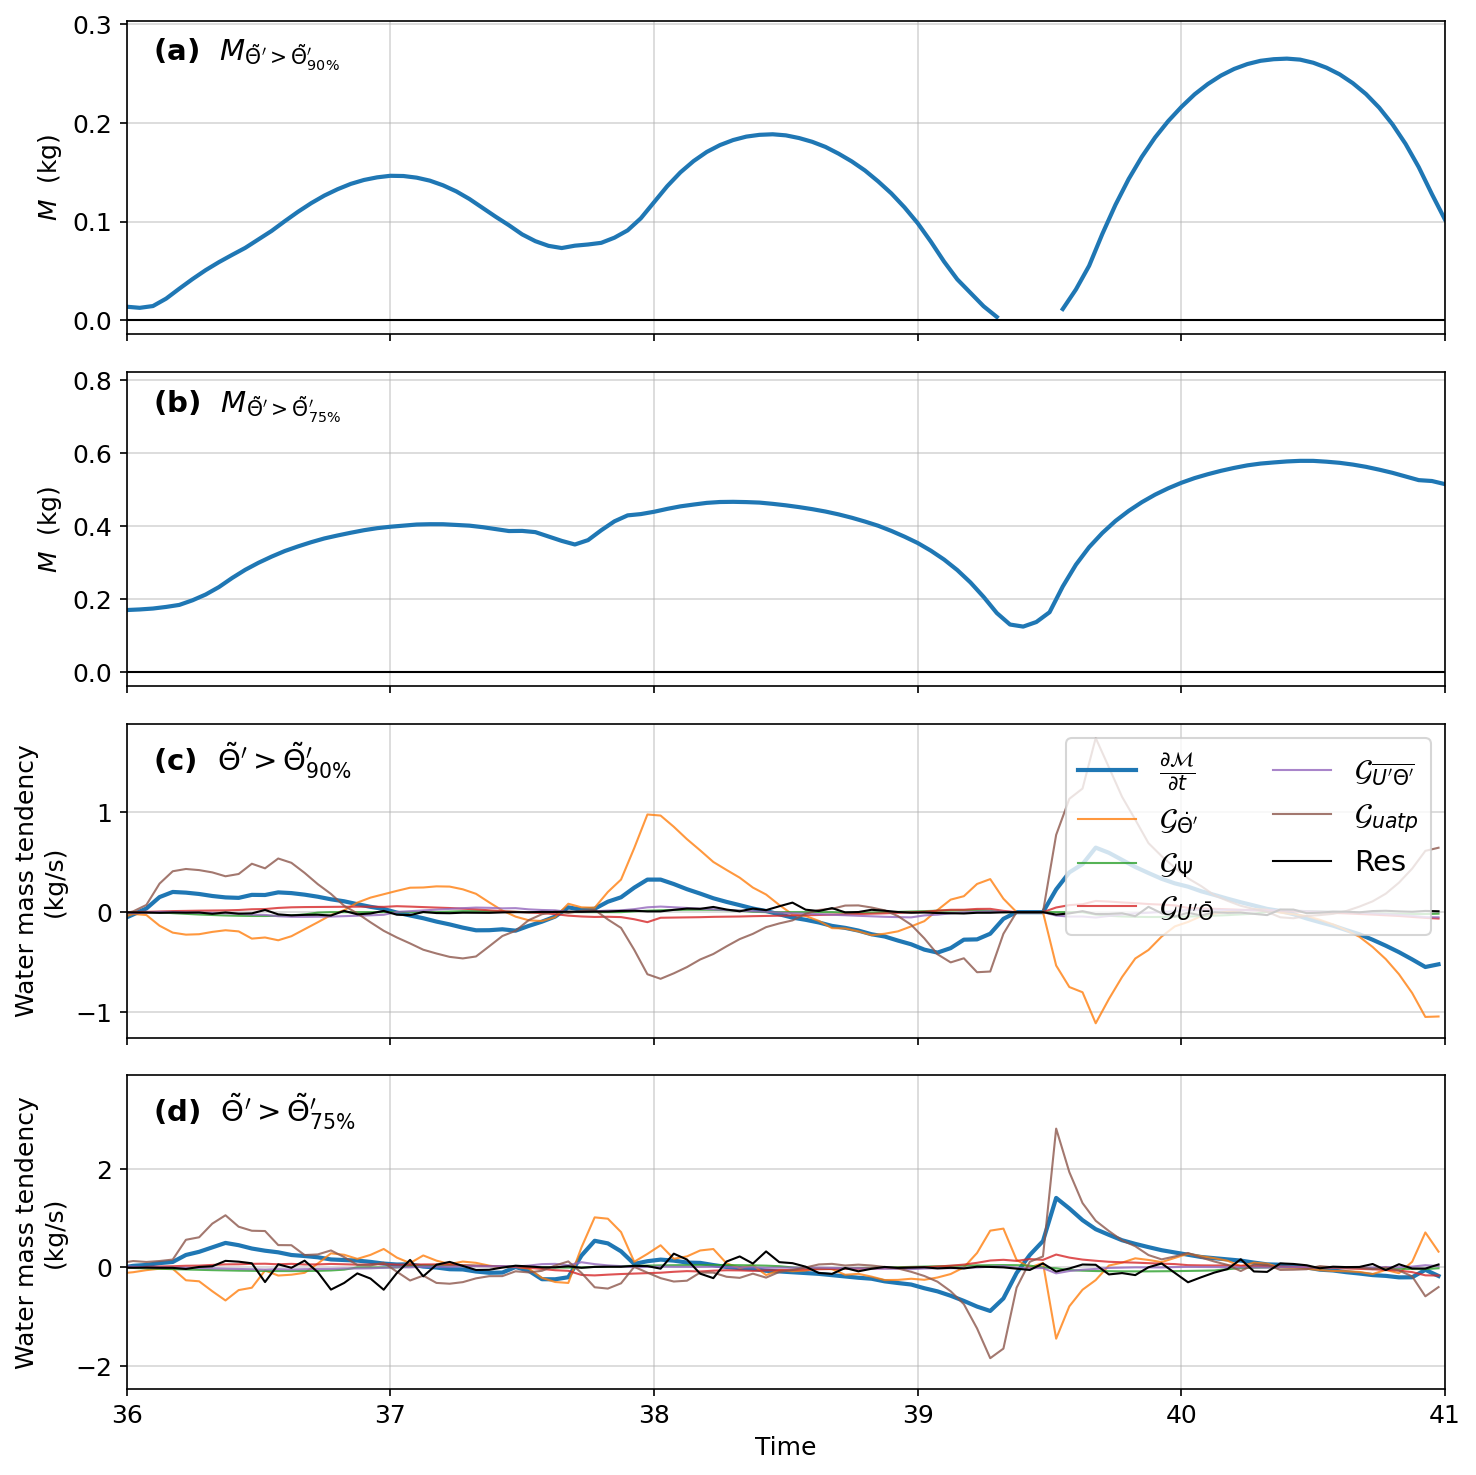

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# ... (假设数据 gmat, gadv_cum, M, M_trend 等已经加载) ...

panel_labels = ['(a)  '+ r"$M_{\tilde{\Theta}^{\prime}>\tilde{\Theta}^{\prime}_{90\%}}$ ", 
                '(b)  '+ r"$M_{\tilde{\Theta}^{\prime}>\tilde{\Theta}^{\prime}_{75\%}}$ ", 
                '(c)  '+ r"$\tilde{\Theta}^{\prime}>\tilde{\Theta}^{\prime}_{90\%} $ ", 
                '(d)  '+ r"$\tilde{\Theta}^{\prime}>\tilde{\Theta}^{\prime}_{75\%} $ ", 
                '(e)', 
                '(f)']

# Create figure
# 修改 1: 布局改为 4行1列 (4, 1)，增加高度以防挤压 (figsize=(10, 16))
fig, axs = plt.subplots(4, 1, figsize=(10, 10), sharex=True)

# ---------------------------------------------------------
# Plot Panel (a) -> axs[0]
# ---------------------------------------------------------
# 原 axs[0,0] 改为 axs[0]
idx = 90
axs[0].plot( ds_budget.M.time_snap, ds_budget.M.where(ds_budget.M>0).isel(tcenter=idx) , linewidth=2 )
axs[0].plot( [ds_budget.M.time_snap[0] , ds_budget.M.time_snap[-1] ], [0, 0] , linewidth=1, color='k' )
axs[0].text(0.02, 0.95, panel_labels[0], transform=axs[0].transAxes,
               ha='left', va='top', fontsize=14, fontweight='bold')
#axs[0].set_xlim( M.t.min(),M.t.max() )
#axs[0].set_ylim( -5, 145 )
axs[0].set_ylabel( r'$M$' + '  ' + '(kg)' )
axs[0].grid(True, alpha=0.5)

# ---------------------------------------------------------
# Plot Panel (b) -> axs[1]
# ---------------------------------------------------------
# 原 axs[0,1] 改为 axs[1]
idx = 75
axs[1].plot( ds_budget.M.time_snap, ds_budget.M.where(ds_budget.M>0).isel(tcenter=idx) , linewidth=2 )
axs[1].plot( [ds_budget.M.time_snap[0] , ds_budget.M.time_snap[-1] ], [0, 0] , linewidth=1, color='k' )
axs[1].text(0.02, 0.95, panel_labels[1], transform=axs[1].transAxes,
               ha='left', va='top', fontsize=14, fontweight='bold')
#axs[1].set_xlim( M.t.min(),M.t.max() )
#axs[1].set_ylim( -50, 1300 )
axs[1].set_ylabel( r'$M$' + '  ' + '(kg)' ) # 为了美观，给第二行也加上ylabel，或者保持为空
axs[1].grid(True, alpha=0.5)


# ---------------------------------------------------------
# Plot Panel (c) -> axs[2]
# ---------------------------------------------------------
idx = 90
print(M_trend.tcenter[idx].values)
# 原 axs[1,0] 改为 axs[2]
axs[2].plot(ds_budget.M_trend.t.values, ds_budget.M_trend.isel(tcenter=idx).values, label=r'$\frac{\partial{\mathcal{M}}}{\partial{t}}$', linewidth=2)
axs[2].plot(ds_budget.G_theta_dot.t.values, ds_budget.G_theta_dot.isel(tcenter=idx).values, label=r'$\mathcal{G}_{\dot{\Theta}^{\prime}}$', alpha=0.8, linewidth=1)
axs[2].plot(ds_budget.G_adv.t.values, ds_budget.G_adv.isel(tcenter=idx).values, label=r'$ \mathcal{G}_{\Psi}$', alpha=0.8, linewidth=1)
axs[2].plot(ds_budget.G_upTb.t.values, ds_budget.G_upTb.isel(tcenter=idx).values, label=r'$ \mathcal{G}_{U^{\prime}\bar{\Theta}}$', alpha=0.8, linewidth=1)
axs[2].plot(ds_budget.G_upTp.t.values, ds_budget.G_upTp.isel(tcenter=idx).values, label=r'$\mathcal{G}_{\overline{U^{\prime}\Theta^{\prime}}}$', alpha=0.8, linewidth=1)
axs[2].plot(ds_budget.G_uatp.t.values, ds_budget.G_uatp.isel(tcenter=idx).values, label=r'$\mathcal{G}_{uatp}$', alpha=0.8, linewidth=1)

# Plot residual
axs[2].plot(ds_budget.M_trend.t.values, ds_budget.Residual.isel(tcenter=idx).values, 'k-', label='Res', linewidth=1)
axs[2].text(0.02, 0.95, panel_labels[2], transform=axs[2].transAxes,
               ha='left', va='top', fontsize=14, fontweight='bold') # 加上 Panel C 的标签
axs[2].set_xlim( 36,41 )
axs[2].grid(True, alpha=0.5)
axs[2].legend(loc='upper right', ncol=2, fontsize='14') # 图变窄了，Legend可能需要调整列数或字体
#axs[2].set_ylim( -1000, 1000 )
axs[2].set_ylabel( 'Water mass tendency' + '\n' + '(kg/s)' )


# ---------------------------------------------------------
# Plot Panel (d) -> axs[3]
# ---------------------------------------------------------
idx = 75
print(M_trend.tcenter[idx].values)

# 原 axs[1,1] 改为 axs[3]
axs[3].plot(ds_budget.M_trend.t.values, ds_budget.M_trend.isel(tcenter=idx).values, label=r'$\frac{\partial{\mathcal{M}}}{\partial{t}}$', linewidth=2)
axs[3].plot(ds_budget.G_theta_dot.t.values, ds_budget.G_theta_dot.isel(tcenter=idx).values, label=r'$\mathcal{G}_{\dot{\Theta}^{\prime}}$', alpha=0.8, linewidth=1)
axs[3].plot(ds_budget.G_adv.t.values, ds_budget.G_adv.isel(tcenter=idx).values, label=r'$ \mathcal{G}_{\Psi}$', alpha=0.8, linewidth=1)
axs[3].plot(ds_budget.G_upTb.t.values, ds_budget.G_upTb.isel(tcenter=idx).values, label=r'$ \mathcal{G}_{U^{\prime}\bar{\Theta}}$', alpha=0.8, linewidth=1)
axs[3].plot(ds_budget.G_upTp.t.values, ds_budget.G_upTp.isel(tcenter=idx).values, label=r'$\mathcal{G}_{\overline{U^{\prime}\Theta^{\prime}}}$', alpha=0.8, linewidth=1)
axs[3].plot(ds_budget.G_uatp.t.values, ds_budget.G_uatp.isel(tcenter=idx).values, label=r'$\mathcal{G}_{uatp}$', alpha=0.8, linewidth=1)

# Plot residual
axs[3].plot(ds_budget.M_trend.t.values, ds_budget.Residual.isel(tcenter=idx).values, 'k-', label='Res', linewidth=1)
axs[3].text(0.02, 0.95, panel_labels[3], transform=axs[3].transAxes,
               ha='left', va='top', fontsize=14, fontweight='bold') # 加上 Panel D 的标签
axs[3].set_xlim(36,41)
axs[3].grid(True, alpha=0.5)
# axs[3].legend(loc='upper right') # 如果图(c)已经有图例且内容一样，最下面这个通常可以省略
#axs[3].set_ylim( -4000, 4000 )
axs[3].set_ylabel( 'Water mass tendency' + '\n' + '(kg/s)' )
axs[3].set_xlabel('Time') # 最后一张图加上X轴标签

# 调整布局防止重叠
plt.tight_layout()

#plt.savefig("figure_awmb_timeseries_4x1.png", dpi=1000)
#plt.savefig("figure_awmb_timeseries_4x1.pdf", dpi=1000)
plt.show()


1.4487561714836326
0.4010900696048327


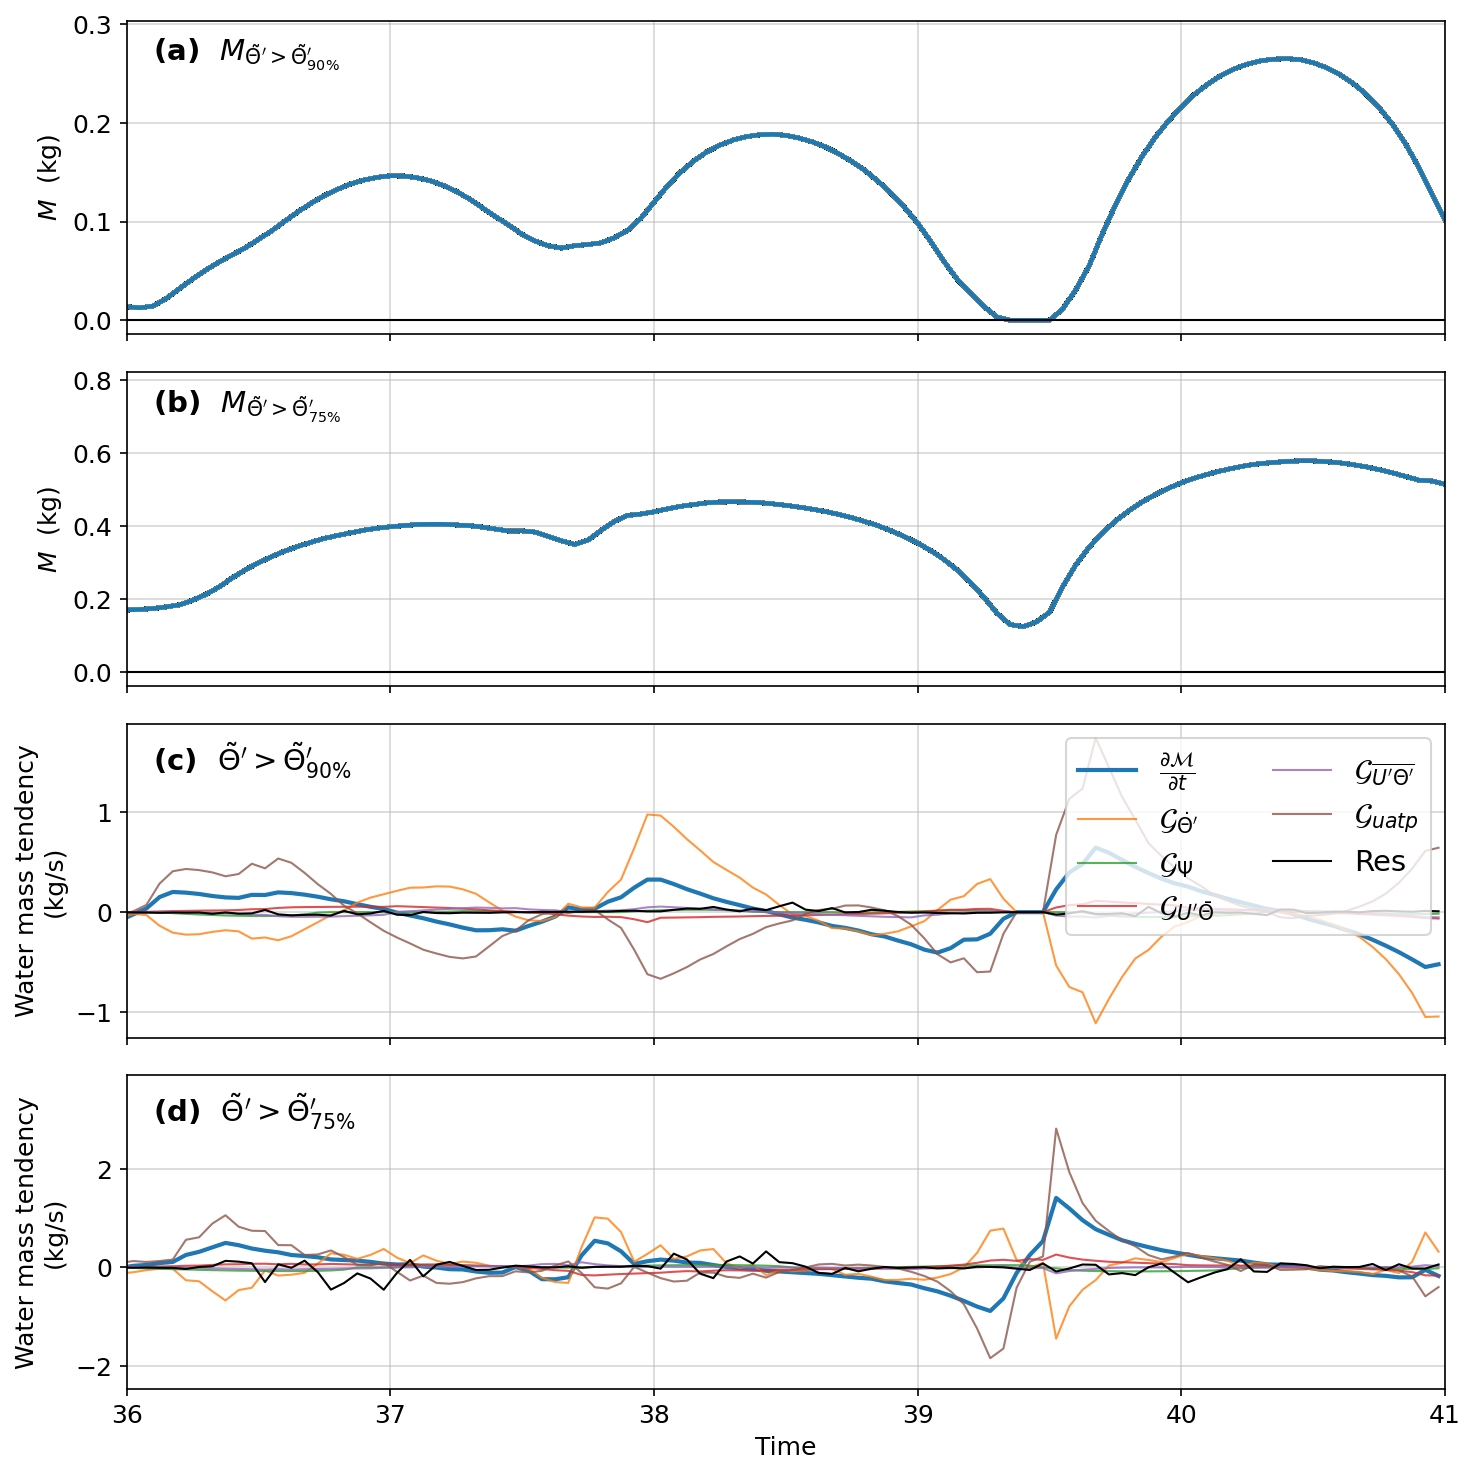

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# ... (假设数据 gmat, gadv_cum, M, M_trend 等已经加载) ...

panel_labels = ['(a)  '+ r"$M_{\tilde{\Theta}^{\prime}>\tilde{\Theta}^{\prime}_{90\%}}$ ", 
                '(b)  '+ r"$M_{\tilde{\Theta}^{\prime}>\tilde{\Theta}^{\prime}_{75\%}}$ ", 
                '(c)  '+ r"$\tilde{\Theta}^{\prime}>\tilde{\Theta}^{\prime}_{90\%} $ ", 
                '(d)  '+ r"$\tilde{\Theta}^{\prime}>\tilde{\Theta}^{\prime}_{75\%} $ ", 
                '(e)', 
                '(f)']

# Create figure
# 修改 1: 布局改为 4行1列 (4, 1)，增加高度以防挤压 (figsize=(10, 16))
fig, axs = plt.subplots(4, 1, figsize=(10, 10), sharex=True)

# ---------------------------------------------------------
# Plot Panel (a) -> axs[0]
# ---------------------------------------------------------
# 原 axs[0,0] 改为 axs[0]
idx = 90
axs[0].plot( ds_budget.M.time_snap, ds_budget.M.where(M>0).isel(tcenter=idx) , linewidth=2 )
axs[0].plot( [ds_budget.M.time_snap[0] , ds_budget.M.time_snap[-1] ], [0, 0] , linewidth=1, color='k' )
axs[0].text(0.02, 0.95, panel_labels[0], transform=axs[0].transAxes,
               ha='left', va='top', fontsize=14, fontweight='bold')
#axs[0].set_xlim( M.t.min(),M.t.max() )
#axs[0].set_ylim( -5, 145 )
axs[0].set_ylabel( r'$M$' + '  ' + '(kg)' )
axs[0].grid(True, alpha=0.5)

# ---------------------------------------------------------
# Plot Panel (b) -> axs[1]
# ---------------------------------------------------------
# 原 axs[0,1] 改为 axs[1]
idx = 75
axs[1].plot( ds_budget.M.time_snap, ds_budget.M.where(M>0).isel(tcenter=idx) , linewidth=2 )
axs[1].plot( [ds_budget.M.time_snap[0] , ds_budget.M.time_snap[-1] ], [0, 0] , linewidth=1, color='k' )
axs[1].text(0.02, 0.95, panel_labels[1], transform=axs[1].transAxes,
               ha='left', va='top', fontsize=14, fontweight='bold')
#axs[1].set_xlim( M.t.min(),M.t.max() )
#axs[1].set_ylim( -50, 1300 )
axs[1].set_ylabel( r'$M$' + '  ' + '(kg)' ) # 为了美观，给第二行也加上ylabel，或者保持为空
axs[1].grid(True, alpha=0.5)


# ---------------------------------------------------------
# Plot Panel (c) -> axs[2]
# ---------------------------------------------------------
idx = 90
print(M_trend.tcenter[idx].values)
# 原 axs[1,0] 改为 axs[2]
axs[2].plot(ds_budget.M_trend.t.values, ds_budget.M_trend.isel(tcenter=idx).values, label=r'$\frac{\partial{\mathcal{M}}}{\partial{t}}$', linewidth=2)
axs[2].plot(ds_budget.G_theta_dot.t.values, ds_budget.G_theta_dot.isel(tcenter=idx).values, label=r'$\mathcal{G}_{\dot{\Theta}^{\prime}}$', alpha=0.8, linewidth=1)
axs[2].plot(ds_budget.G_adv.t.values, ds_budget.G_adv.isel(tcenter=idx).values, label=r'$ \mathcal{G}_{\Psi}$', alpha=0.8, linewidth=1)
axs[2].plot(ds_budget.G_upTb.t.values, ds_budget.G_upTb.isel(tcenter=idx).values, label=r'$ \mathcal{G}_{U^{\prime}\bar{\Theta}}$', alpha=0.8, linewidth=1)
axs[2].plot(ds_budget.G_upTp.t.values, ds_budget.G_upTp.isel(tcenter=idx).values, label=r'$\mathcal{G}_{\overline{U^{\prime}\Theta^{\prime}}}$', alpha=0.8, linewidth=1)
axs[2].plot(ds_budget.G_uatp.t.values, ds_budget.G_uatp.isel(tcenter=idx).values, label=r'$\mathcal{G}_{uatp}$', alpha=0.8, linewidth=1)

# Plot residual
axs[2].plot(ds_budget.M_trend.t.values, ds_budget.residual.isel(tcenter=idx).values, 'k-', label='Res', linewidth=1)
axs[2].text(0.02, 0.95, panel_labels[2], transform=axs[2].transAxes,
               ha='left', va='top', fontsize=14, fontweight='bold') # 加上 Panel C 的标签
axs[2].set_xlim( 36,41 )
axs[2].grid(True, alpha=0.5)
axs[2].legend(loc='upper right', ncol=2, fontsize='14') # 图变窄了，Legend可能需要调整列数或字体
#axs[2].set_ylim( -1000, 1000 )
axs[2].set_ylabel( 'Water mass tendency' + '\n' + '(kg/s)' )


# ---------------------------------------------------------
# Plot Panel (d) -> axs[3]
# ---------------------------------------------------------
idx = 75
print(M_trend.tcenter[idx].values)

# 原 axs[1,1] 改为 axs[3]
axs[3].plot(ds_budget.M_trend.t.values, ds_budget.M_trend.isel(tcenter=idx).values, label=r'$\frac{\partial{\mathcal{M}}}{\partial{t}}$', linewidth=2)
axs[3].plot(ds_budget.G_theta_dot.t.values, ds_budget.G_theta_dot.isel(tcenter=idx).values, label=r'$\mathcal{G}_{\dot{\Theta}^{\prime}}$', alpha=0.8, linewidth=1)
axs[3].plot(ds_budget.G_adv.t.values, ds_budget.G_adv.isel(tcenter=idx).values, label=r'$ \mathcal{G}_{\Psi}$', alpha=0.8, linewidth=1)
axs[3].plot(ds_budget.G_upTb.t.values, ds_budget.G_upTb.isel(tcenter=idx).values, label=r'$ \mathcal{G}_{U^{\prime}\bar{\Theta}}$', alpha=0.8, linewidth=1)
axs[3].plot(ds_budget.G_upTp.t.values, ds_budget.G_upTp.isel(tcenter=idx).values, label=r'$\mathcal{G}_{\overline{U^{\prime}\Theta^{\prime}}}$', alpha=0.8, linewidth=1)
axs[3].plot(ds_budget.G_uatp.t.values, ds_budget.G_uatp.isel(tcenter=idx).values, label=r'$\mathcal{G}_{uatp}$', alpha=0.8, linewidth=1)

# Plot residual
axs[3].plot(ds_budget.M_trend.t.values, ds_budget.residual.isel(tcenter=idx).values, 'k-', label='Res', linewidth=1)
axs[3].text(0.02, 0.95, panel_labels[3], transform=axs[3].transAxes,
               ha='left', va='top', fontsize=14, fontweight='bold') # 加上 Panel D 的标签
axs[3].set_xlim(36,41)
axs[3].grid(True, alpha=0.5)
# axs[3].legend(loc='upper right') # 如果图(c)已经有图例且内容一样，最下面这个通常可以省略
#axs[3].set_ylim( -4000, 4000 )
axs[3].set_ylabel( 'Water mass tendency' + '\n' + '(kg/s)' )
axs[3].set_xlabel('Time') # 最后一张图加上X轴标签

# 调整布局防止重叠
plt.tight_layout()

#plt.savefig("figure_awmb_timeseries_4x1.png", dpi=1000)
#plt.savefig("figure_awmb_timeseries_4x1.pdf", dpi=1000)
plt.show()



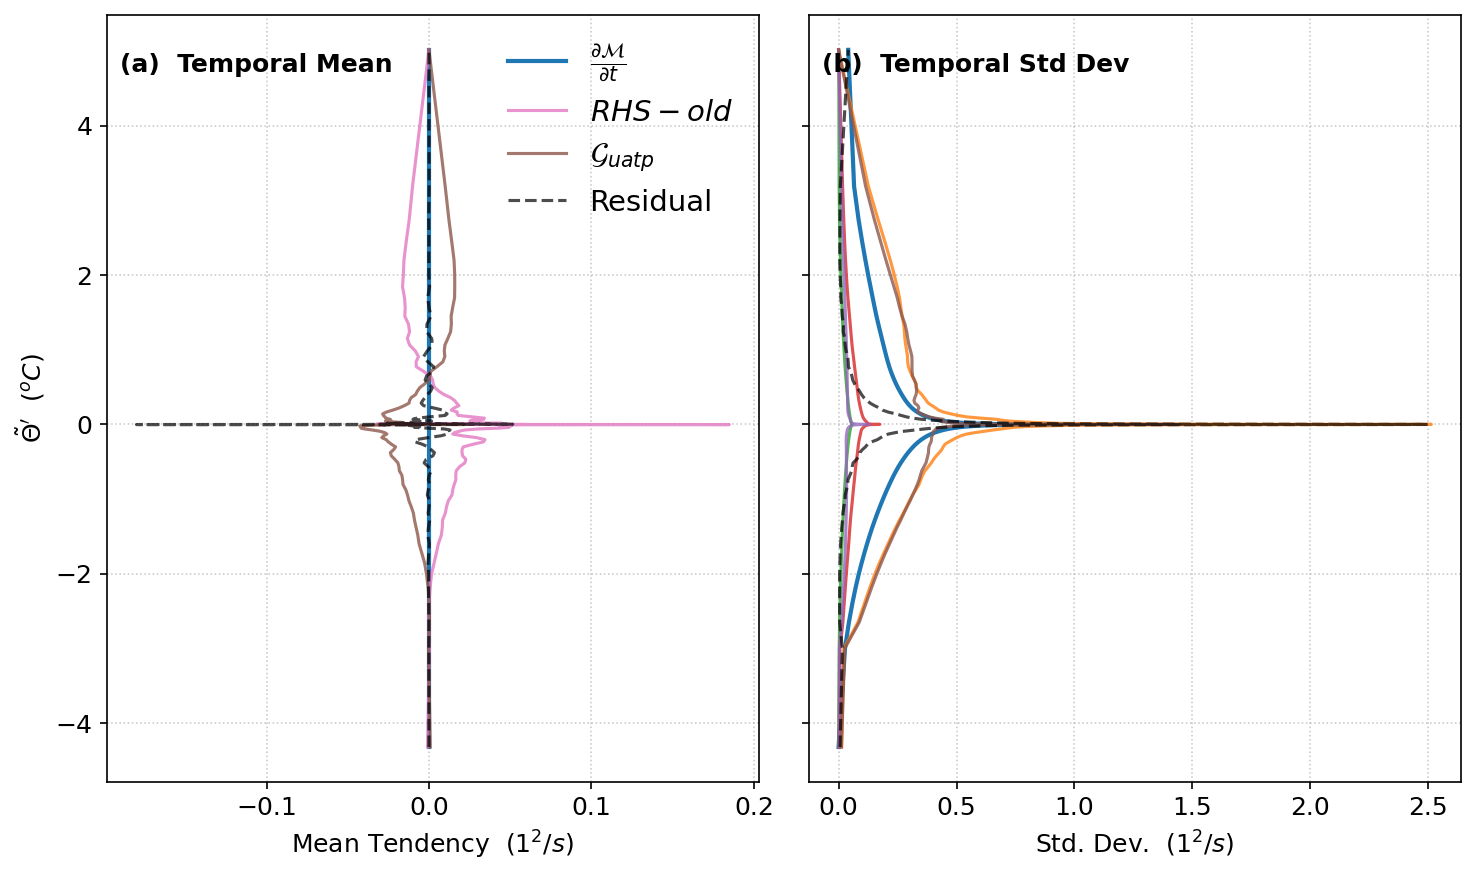

In [25]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

# --- 假设数据已经加载 ---
# M_trend, gmat, gadv_cum, gupTb, gupTp

# 全局风格设置
mpl.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "pdf.fonttype": 42,
    "axes.linewidth": 0.8,
})

# ==========================================
# 1. 数据计算
# ==========================================

# 1.1 Mean
M_trend_mean = ds_budget.M_trend.mean(dim='t')
gmat_mean = ds_budget.G_theta_dot.mean(dim='t')
gadv_cum_mean = ds_budget.G_adv.mean(dim='t')
gupTb_mean = ds_budget.G_upTb.mean(dim='t')
gupTp_mean = ds_budget.G_upTp.mean(dim='t')
guatp_mean = ds_budget.G_uatp.mean(dim='t')

RHS_mean_old = gmat_mean + gadv_cum_mean + gupTb_mean + gupTp_mean 

RHS_mean = gmat_mean + gadv_cum_mean + gupTb_mean + gupTp_mean + guatp_mean
residual_mean = M_trend_mean - RHS_mean

# 1.2 Std
M_trend_std =  ds_budget.M_trend.std(dim='t')
gmat_std = ds_budget.G_theta_dot.std(dim='t')
gadv_cum_std = ds_budget.G_adv.std(dim='t')
gupTb_std = ds_budget.G_upTb.std(dim='t')
gupTp_std = ds_budget.G_upTp.std(dim='t')
guatp_std = ds_budget.G_uatp.std(dim='t')

# Residual Std (先算残差时间序列，再算std)
RHS_old = ds_budget.G_theta_dot + ds_budget.G_adv + ds_budget.G_upTb + ds_budget.G_upTp

RHS = ds_budget.G_theta_dot + ds_budget.G_adv + ds_budget.G_upTb + ds_budget.G_upTp + ds_budget.G_uatp
residual = ds_budget.M_trend - RHS
residual_std = residual.std(dim='t')

# ==========================================
# 2. 绘图
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharey=True)
ax_mean = axes[0]
ax_std = axes[1]

y_coords = M_trend.tcenter.values

# --- 左图：Mean ---
ax_mean.plot(M_trend_mean.values, y_coords, label=r'$\frac{\partial{\mathcal{M}}}{\partial{t}}$', linewidth=2, color='C0')
#ax_mean.plot(gmat_mean.values, y_coords, label=r'$\mathcal{G}_{\dot{\Theta}^{\prime}}$', alpha=0.8, color='C1', linewidth=1.5)
#ax_mean.plot(gadv_cum_mean.values, y_coords, label=r'$\mathcal{G}_{\Psi}$', alpha=0.8, color='C2', linewidth=1.5)
#ax_mean.plot(gupTb_mean.values, y_coords, label=r'$\mathcal{G}_{U^{\prime}\bar{\Theta}}$', alpha=0.8, color='C3', linewidth=1.5)
#ax_mean.plot(gupTp_mean.values, y_coords, label=r'$\mathcal{G}_{\overline{U^{\prime}\Theta^{\prime}}}$', alpha=0.8, color='C4', linewidth=1.5)
ax_mean.plot(RHS_mean_old.values, y_coords, label=r'$RHS-old$', alpha=0.8, color='C6', linewidth=1.5)
ax_mean.plot(guatp_mean.values, y_coords, label=r'$\mathcal{G}_{uatp}$', alpha=0.8, color='C5', linewidth=1.5)
ax_mean.plot(residual_mean.values, y_coords, 'k--', label='Residual', linewidth=1.5, alpha=0.7)

#ax_mean.set_xlim(-0.01, 0.01)
ax_mean.set_xlabel('Mean Tendency  '+r'$(1^{2}/s)$')
ax_mean.set_ylabel(r'$\tilde{\Theta}^{\prime}$' + '  '+ r'$(^{o}C)$')
ax_mean.grid(True, linestyle=':', linewidth=0.75, alpha=0.7)

# 【修改点 1】将标题移入图内左上角
ax_mean.text(0.02, 0.95, '(a)  Temporal Mean', transform=ax_mean.transAxes,
             fontsize=12, fontweight='bold', va='top', ha='left')

# 【修改点 2】由于左上角放了标题，Legend 建议移到右上角或右下角
ax_mean.legend(loc='upper right', frameon=False,fontsize=14)


# --- 右图：Std ---
ax_std.plot(M_trend_std.values, y_coords, linewidth=2, color='C0')
ax_std.plot(gmat_std.values, y_coords, alpha=0.8, color='C1', linewidth=1.5)
ax_std.plot(gadv_cum_std.values, y_coords, alpha=0.8, color='C2', linewidth=1.5)
ax_std.plot(gupTb_std.values, y_coords, alpha=0.8, color='C3', linewidth=1.5)
ax_std.plot(gupTp_std.values, y_coords, alpha=0.8, color='C4', linewidth=1.5)
ax_std.plot(guatp_std.values, y_coords, alpha=0.8, color='C5', linewidth=1.5)

ax_std.plot(residual_std.values, y_coords, 'k--', linewidth=1.5, alpha=0.7)

# ax_std.set_xlim(0, 50) # 可选：根据数据范围手动固定
ax_std.set_xlabel('Std. Dev.  '+r'$(1^{2}/s)$')
#ax_std.set_ylim(-3.5, 3.5)
ax_std.grid(True, linestyle=':', linewidth=0.75, alpha=0.7)

# 【修改点 3】将标题移入图内左上角
ax_std.text(0.02, 0.95, '(b)  Temporal Std Dev', transform=ax_std.transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')

# ==========================================
# 3. 保存
# ==========================================
plt.tight_layout()
#plt.savefig("figure_awmb_mean_std.png", bbox_inches="tight")
#plt.savefig("figure_awmb_mean_std.pdf", bbox_inches="tight")
plt.show()


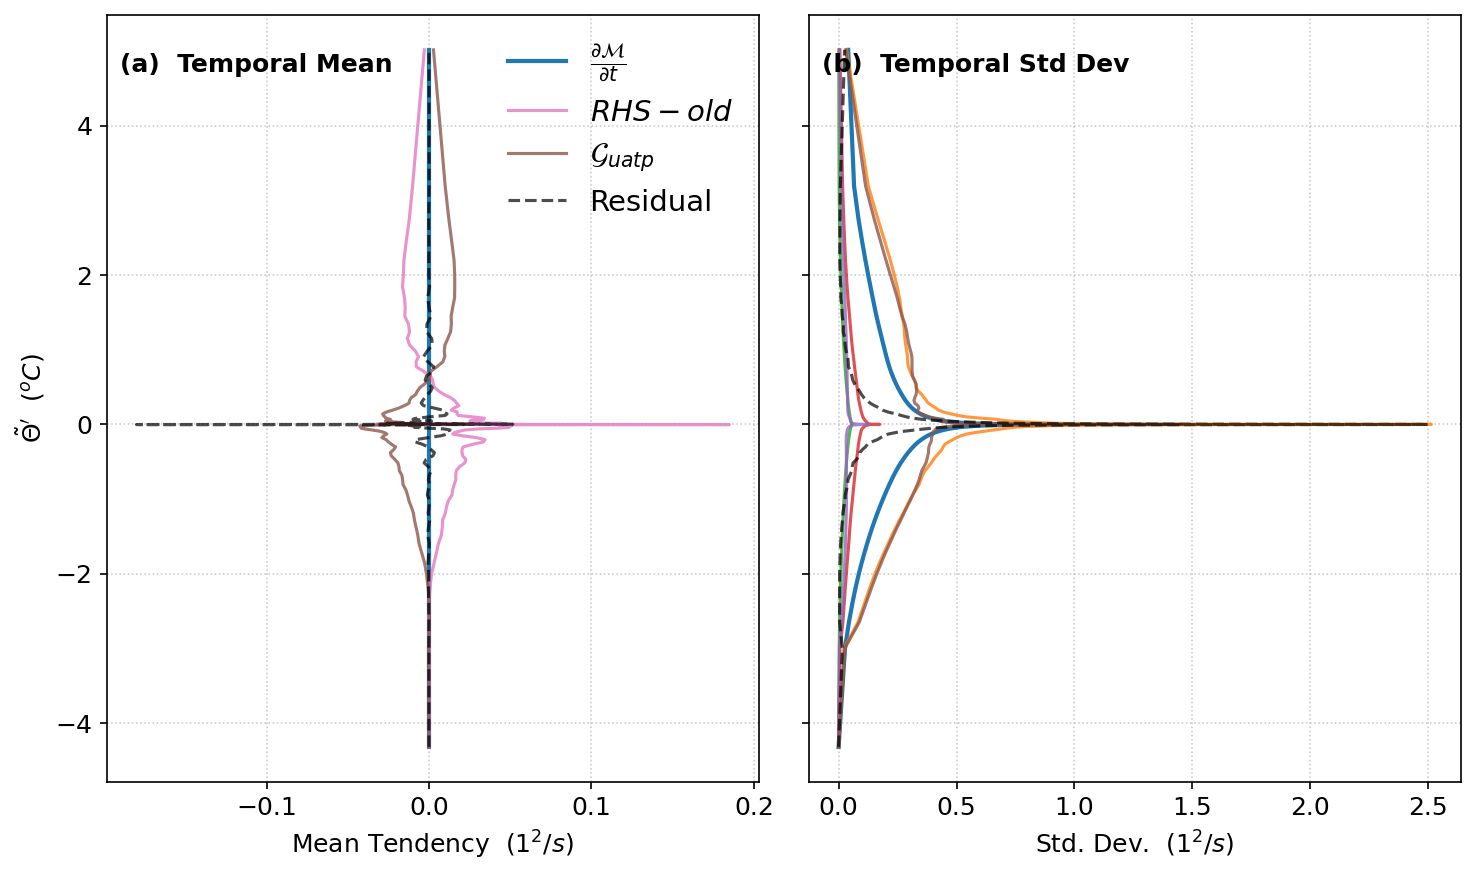

In [40]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

# --- 假设数据已经加载 ---
# M_trend, gmat, gadv_cum, gupTb, gupTp

# 全局风格设置
mpl.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "pdf.fonttype": 42,
    "axes.linewidth": 0.8,
})

# ==========================================
# 1. 数据计算
# ==========================================

# 1.1 Mean
M_trend_mean = ds_budget.M_trend.mean(dim='t')
gmat_mean = ds_budget.G_theta_dot.mean(dim='t')
gadv_cum_mean = ds_budget.G_adv.mean(dim='t')
gupTb_mean = ds_budget.G_upTb.mean(dim='t')
gupTp_mean = ds_budget.G_upTp.mean(dim='t')
guatp_mean = ds_budget.G_uatp.mean(dim='t')

RHS_mean_old = gmat_mean + gadv_cum_mean + gupTb_mean + gupTp_mean 

RHS_mean = gmat_mean + gadv_cum_mean + gupTb_mean + gupTp_mean + guatp_mean
residual_mean = M_trend_mean - RHS_mean

# 1.2 Std
M_trend_std =  ds_budget.M_trend.std(dim='t')
gmat_std = ds_budget.G_theta_dot.std(dim='t')
gadv_cum_std = ds_budget.G_adv.std(dim='t')
gupTb_std = ds_budget.G_upTb.std(dim='t')
gupTp_std = ds_budget.G_upTp.std(dim='t')
guatp_std = ds_budget.G_uatp.std(dim='t')

# Residual Std (先算残差时间序列，再算std)
RHS_old = ds_budget.G_theta_dot + ds_budget.G_adv + ds_budget.G_upTb + ds_budget.G_upTp

RHS = ds_budget.G_theta_dot + ds_budget.G_adv + ds_budget.G_upTb + ds_budget.G_upTp + ds_budget.G_uatp
residual = ds_budget.M_trend - RHS
residual_std = residual.std(dim='t')

# ==========================================
# 2. 绘图
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharey=True)
ax_mean = axes[0]
ax_std = axes[1]

y_coords = M_trend.tcenter.values

# --- 左图：Mean ---
ax_mean.plot(M_trend_mean.values, y_coords, label=r'$\frac{\partial{\mathcal{M}}}{\partial{t}}$', linewidth=2, color='C0')
#ax_mean.plot(gmat_mean.values, y_coords, label=r'$\mathcal{G}_{\dot{\Theta}^{\prime}}$', alpha=0.8, color='C1', linewidth=1.5)
#ax_mean.plot(gadv_cum_mean.values, y_coords, label=r'$\mathcal{G}_{\Psi}$', alpha=0.8, color='C2', linewidth=1.5)
#ax_mean.plot(gupTb_mean.values, y_coords, label=r'$\mathcal{G}_{U^{\prime}\bar{\Theta}}$', alpha=0.8, color='C3', linewidth=1.5)
#ax_mean.plot(gupTp_mean.values, y_coords, label=r'$\mathcal{G}_{\overline{U^{\prime}\Theta^{\prime}}}$', alpha=0.8, color='C4', linewidth=1.5)
ax_mean.plot(RHS_mean_old.values, y_coords, label=r'$RHS-old$', alpha=0.8, color='C6', linewidth=1.5)
ax_mean.plot(guatp_mean.values, y_coords, label=r'$\mathcal{G}_{uatp}$', alpha=0.8, color='C5', linewidth=1.5)
ax_mean.plot(residual_mean.values, y_coords, 'k--', label='Residual', linewidth=1.5, alpha=0.7)

#ax_mean.set_xlim(-0.01, 0.01)
ax_mean.set_xlabel('Mean Tendency  '+r'$(1^{2}/s)$')
ax_mean.set_ylabel(r'$\tilde{\Theta}^{\prime}$' + '  '+ r'$(^{o}C)$')
ax_mean.grid(True, linestyle=':', linewidth=0.75, alpha=0.7)

# 【修改点 1】将标题移入图内左上角
ax_mean.text(0.02, 0.95, '(a)  Temporal Mean', transform=ax_mean.transAxes,
             fontsize=12, fontweight='bold', va='top', ha='left')

# 【修改点 2】由于左上角放了标题，Legend 建议移到右上角或右下角
ax_mean.legend(loc='upper right', frameon=False,fontsize=14)


# --- 右图：Std ---
ax_std.plot(M_trend_std.values, y_coords, linewidth=2, color='C0')
ax_std.plot(gmat_std.values, y_coords, alpha=0.8, color='C1', linewidth=1.5)
ax_std.plot(gadv_cum_std.values, y_coords, alpha=0.8, color='C2', linewidth=1.5)
ax_std.plot(gupTb_std.values, y_coords, alpha=0.8, color='C3', linewidth=1.5)
ax_std.plot(gupTp_std.values, y_coords, alpha=0.8, color='C4', linewidth=1.5)
ax_std.plot(guatp_std.values, y_coords, alpha=0.8, color='C5', linewidth=1.5)

ax_std.plot(residual_std.values, y_coords, 'k--', linewidth=1.5, alpha=0.7)

# ax_std.set_xlim(0, 50) # 可选：根据数据范围手动固定
ax_std.set_xlabel('Std. Dev.  '+r'$(1^{2}/s)$')
#ax_std.set_ylim(-3.5, 3.5)
ax_std.grid(True, linestyle=':', linewidth=0.75, alpha=0.7)

# 【修改点 3】将标题移入图内左上角
ax_std.text(0.02, 0.95, '(b)  Temporal Std Dev', transform=ax_std.transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')

# ==========================================
# 3. 保存
# ==========================================
plt.tight_layout()
#plt.savefig("figure_awmb_mean_std.png", bbox_inches="tight")
#plt.savefig("figure_awmb_mean_std.pdf", bbox_inches="tight")
plt.show()
